# Phase 2A: basic within-frame geometry

Descriptive implementation validation in native StatsBomb 120 × 80 units. The eight locked metric families emit nine numeric outputs. Each original frame has six literal subset/goalkeeper variants. These are partial visible records, not full-team or tactical measurements.

Run `python scripts/geometry_diagnostics.py` from the repository root to generate the derived tables. This notebook reads compact summaries and rejects an unknown or different source revision. All geometry and summaries are computed in the reusable package; no raw records are saved.

In [1]:
%matplotlib inline
from pathlib import Path
from IPython.display import display
from leverkusen.spatial.diagnostics import read_geometry_diagnostics
from leverkusen.visualization.geometry import (
    plot_distributions, plot_by_valid_points, plot_goalkeeper_sensitivity,
)

root = Path.cwd() if (Path.cwd() / 'config/project.yaml').is_file() else Path.cwd().parent
summaries = read_geometry_diagnostics(root / 'outputs/diagnostics')
display(summaries['inventory'])
display(summaries['match_summary'])

,original_frames,variant_rows,matches_with_frames,statsbomb_revision
0,118581,711486,34,533862946a73608c134d18b78226b6371ce7173c


,match_id,events,original_frames,variant_rows,frames_load_status,frames_load_error,statsbomb_revision,source_base_url,retrieved_at_utc
0,3895302,4223,3525,21150,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:57:47.318608+00:00
1,3895292,3843,3195,19170,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:57:58.468962+00:00
2,3895333,3549,2950,17700,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:09.782972+00:00
3,3895340,3315,2847,17082,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:20.610007+00:00
4,3895348,4133,3562,21372,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:33.772695+00:00
5,3895286,3894,3434,20604,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:48.857965+00:00
6,3895220,4258,3757,22542,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:02.026975+00:00
7,3895250,3826,3410,20460,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:14.963602+00:00
8,3895266,4104,3623,21738,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:28.007176+00:00
9,3895275,3909,3341,20046,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:40.710549+00:00


## Availability and status

Count is zero for known-empty selections; an unavailable frame has NA measurements. Every other NA is accompanied by a metric-specific reason. Centroid components share one status rule. The tables retain all rows, including actor ambiguity and low visible-area coverage. This is an inventory of diagnostic measurements; the registry's later primary-comparison ambiguity policy is not applied here.

In [2]:
display(summaries['metric_summary'])
display(summaries['metric_status'])
display(summaries['anomalies'])

,selected_subset,goalkeeper_policy,metric,rows,available,na,na_percent,mean,std,min,p05,p25,median,p75,p95,max,statsbomb_revision
0,all_visible,included,visible_player_count,118581,118581,0,0.000000,16.471290,3.120971,1.000000,11.000000,14.000000,17.000000,19.000000,20.000000,22.000000,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,centroid_x,118581,118581,0,0.000000,63.806991,26.356173,3.099943,18.089736,43.568488,66.138246,85.053678,103.246848,118.677691,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,centroid_y,118581,118581,0,0.000000,40.174659,11.653331,3.205394,21.231619,31.241141,40.167044,49.157679,58.922186,75.576509,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,visible_width,118581,118581,0,0.000000,47.464932,11.092361,0.000000,28.990084,39.955072,47.524532,55.377362,65.637942,81.286486,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,visible_depth,118581,118581,0,0.000000,33.689701,7.986431,0.000000,21.924168,28.563324,32.954542,38.021937,47.994070,110.967021,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,included,convex_hull_area,118581,118574,7,0.005903,1031.928057,393.677325,2.573681,430.826141,757.614800,1009.966918,1276.996848,1700.748408,4304.400473,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,included,mean_pairwise_distance,118581,118580,1,0.000843,21.272467,3.969144,5.299529,14.244654,18.825975,21.497648,23.974184,27.356049,39.737569,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,included,median_pairwise_distance,118581,118580,1,0.000843,20.140406,3.936288,5.012747,13.177037,17.778163,20.344390,22.745449,26.220053,39.547351,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,included,mean_nearest_neighbor_distance,118581,118580,1,0.000843,6.374906,1.568486,1.203826,4.014342,5.323020,6.286875,7.259955,9.107558,25.855086,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,excluded,visible_player_count,118581,118581,0,0.000000,16.071580,3.202193,0.000000,10.000000,14.000000,17.000000,19.000000,20.000000,21.000000,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,metric,status,rows,statsbomb_revision
0,all_visible,included,visible_player_count,ok,118581,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,centroid_x,ok,118581,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,centroid_y,ok,118581,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,visible_width,ok,118581,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,visible_depth,ok,118581,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...
89,teammate_false,excluded,mean_pairwise_distance,insufficient_points,174,533862946a73608c134d18b78226b6371ce7173c
90,teammate_false,excluded,median_pairwise_distance,ok,118407,533862946a73608c134d18b78226b6371ce7173c
91,teammate_false,excluded,median_pairwise_distance,insufficient_points,174,533862946a73608c134d18b78226b6371ce7173c
92,teammate_false,excluded,mean_nearest_neighbor_distance,ok,118407,533862946a73608c134d18b78226b6371ce7173c


,flag,variant_rows,original_frames,statsbomb_revision
0,coincident_records,198,50,533862946a73608c134d18b78226b6371ce7173c
1,multiple_actor,24,4,533862946a73608c134d18b78226b6371ce7173c
2,out_of_bounds_points,45565,11508,533862946a73608c134d18b78226b6371ce7173c


## Observed distributions

All six variants use shared display bins for each metric. Count is in records; hull area is in squared native units; other values are in native units. Histogram binning sets no visibility threshold.

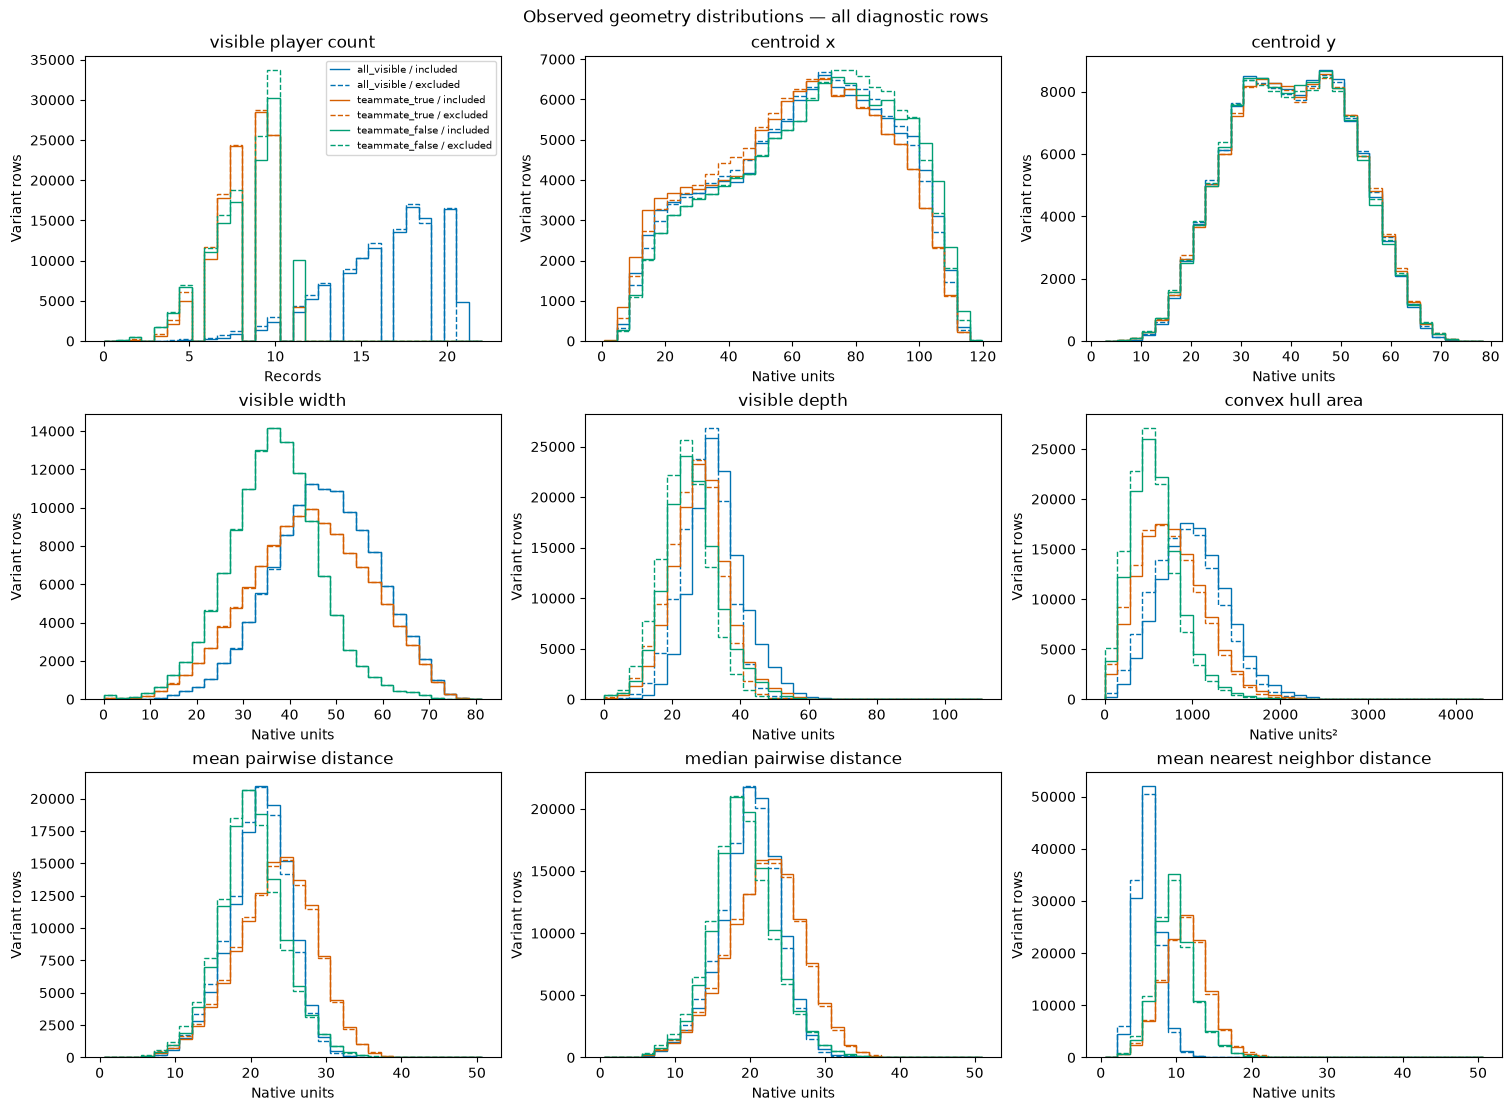

In [3]:
figure = plot_distributions(summaries['histograms'])

## Goalkeeper sensitivity

Differences are **excluded minus included**, paired by match, original frame ordinal and literal subset. `excluded` retains only `keeper=False`. Unknown keeper omissions are reported separately. Tables show all pairs and pairs with at least one record removed. Plot means use the latter group and only jointly defined metric values; consult availability denominators. Different metric minima can make the paired samples differ.

,selected_subset,scope,metric,delta_direction,rows,available,na,na_percent,mean,std,...,p25,median,p75,p95,max,pairs_with_keeper_removal,pairs_with_unknown_keeper_removal,changed_pairs,mean_absolute_delta,statsbomb_revision
0,all_visible,all_pairs,visible_player_count,excluded_minus_included,118581,118581,0,0.000000,-0.399710,0.489910,...,-1.000000,0.000000,0.000000,0.000000,0.000000,47394,0,47394,0.399710,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,all_pairs,centroid_x,excluded_minus_included,118581,118580,1,0.000843,0.045734,0.966287,...,0.000000,0.000000,0.000000,1.921518,12.526461,47394,0,47393,0.556485,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,all_pairs,centroid_y,excluded_minus_included,118581,118580,1,0.000843,0.002562,0.361687,...,0.000000,0.000000,0.000000,0.610513,7.466498,47394,0,47393,0.176888,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,all_pairs,visible_width,excluded_minus_included,118581,118580,1,0.000843,-0.016687,0.355091,...,0.000000,0.000000,0.000000,0.000000,0.000000,47394,0,556,0.016687,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,all_pairs,visible_depth,excluded_minus_included,118581,118580,1,0.000843,-4.167210,6.489208,...,-8.139859,0.000000,0.000000,0.000000,0.000000,47394,0,45089,4.167210,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,all_pairs,convex_hull_area,excluded_minus_included,118581,118562,19,0.016023,-87.756434,145.908657,...,-146.016491,0.000000,0.000000,0.000000,0.000000,47394,0,46831,87.756434,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,all_pairs,mean_pairwise_distance,excluded_minus_included,118581,118574,7,0.005903,-0.335259,0.668195,...,-0.540009,0.000000,0.000000,0.000000,7.396091,47394,0,47387,0.361660,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,all_pairs,median_pairwise_distance,excluded_minus_included,118581,118574,7,0.005903,-0.343683,0.776539,...,-0.477361,0.000000,0.000000,0.000000,6.764277,47394,0,45716,0.385460,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,all_pairs,mean_nearest_neighbor_distance,excluded_minus_included,118581,118574,7,0.005903,-0.162221,0.381839,...,-0.306796,0.000000,0.000000,0.014408,14.118107,47394,0,47387,0.204189,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,records_removed,visible_player_count,excluded_minus_included,47394,47394,0,0.000000,-1.000084,0.009187,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,47394,0,47394,1.000084,533862946a73608c134d18b78226b6371ce7173c


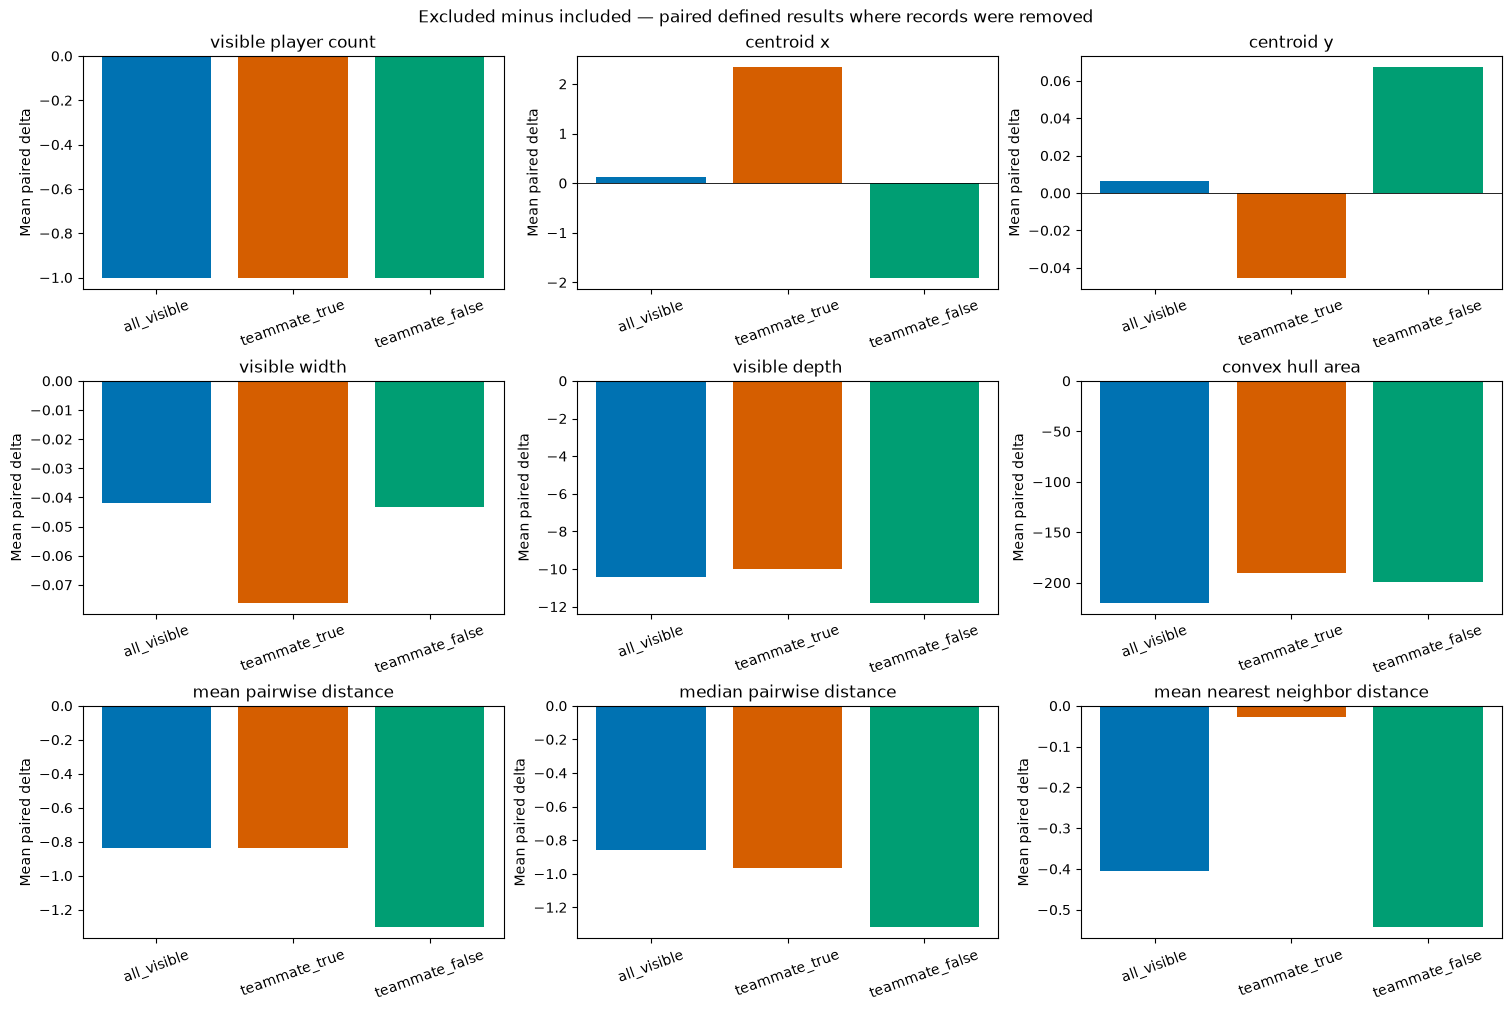

In [4]:
display(summaries['goalkeeper_sensitivity'])
figure = plot_goalkeeper_sensitivity(summaries['goalkeeper_sensitivity'])

## Dependence on selected valid-point count

Strata use the exact number of selected valid records, separately for each subset/keeper variant. Means describe composition and observation differences across strata; they do not establish a full-team shape or tactical effect. The table supplies sample counts and NA rates, including sparse strata.

,selected_subset,goalkeeper_policy,n_valid_points_used,metric,rows,available,na,na_percent,mean,std,min,p05,p25,median,p75,p95,max,statsbomb_revision
0,all_visible,included,1,visible_player_count,1,1,0,0.0,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,1,centroid_x,1,1,0,0.0,9.100000,NaN,9.100000,9.100000,9.100000,9.100000,9.100000,9.100000,9.100000,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,1,centroid_y,1,1,0,0.0,36.500000,NaN,36.500000,36.500000,36.500000,36.500000,36.500000,36.500000,36.500000,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,1,visible_width,1,1,0,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,1,visible_depth,1,1,0,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,teammate_false,excluded,11,visible_depth,30,30,0,0.0,26.368894,13.229105,8.206526,9.291440,15.501970,22.848811,35.267539,52.107770,52.382760,533862946a73608c134d18b78226b6371ce7173c
815,teammate_false,excluded,11,convex_hull_area,30,30,0,0.0,581.724219,443.471777,54.404752,70.872105,138.696868,449.675352,1016.168642,1261.357766,1328.405390,533862946a73608c134d18b78226b6371ce7173c
816,teammate_false,excluded,11,mean_pairwise_distance,30,30,0,0.0,16.530486,7.217471,5.775810,6.300357,8.321684,16.509510,23.108703,25.844235,28.364683,533862946a73608c134d18b78226b6371ce7173c
817,teammate_false,excluded,11,median_pairwise_distance,30,30,0,0.0,15.444811,6.770700,5.105827,5.940909,8.717889,14.378556,21.755108,24.926346,25.215685,533862946a73608c134d18b78226b6371ce7173c


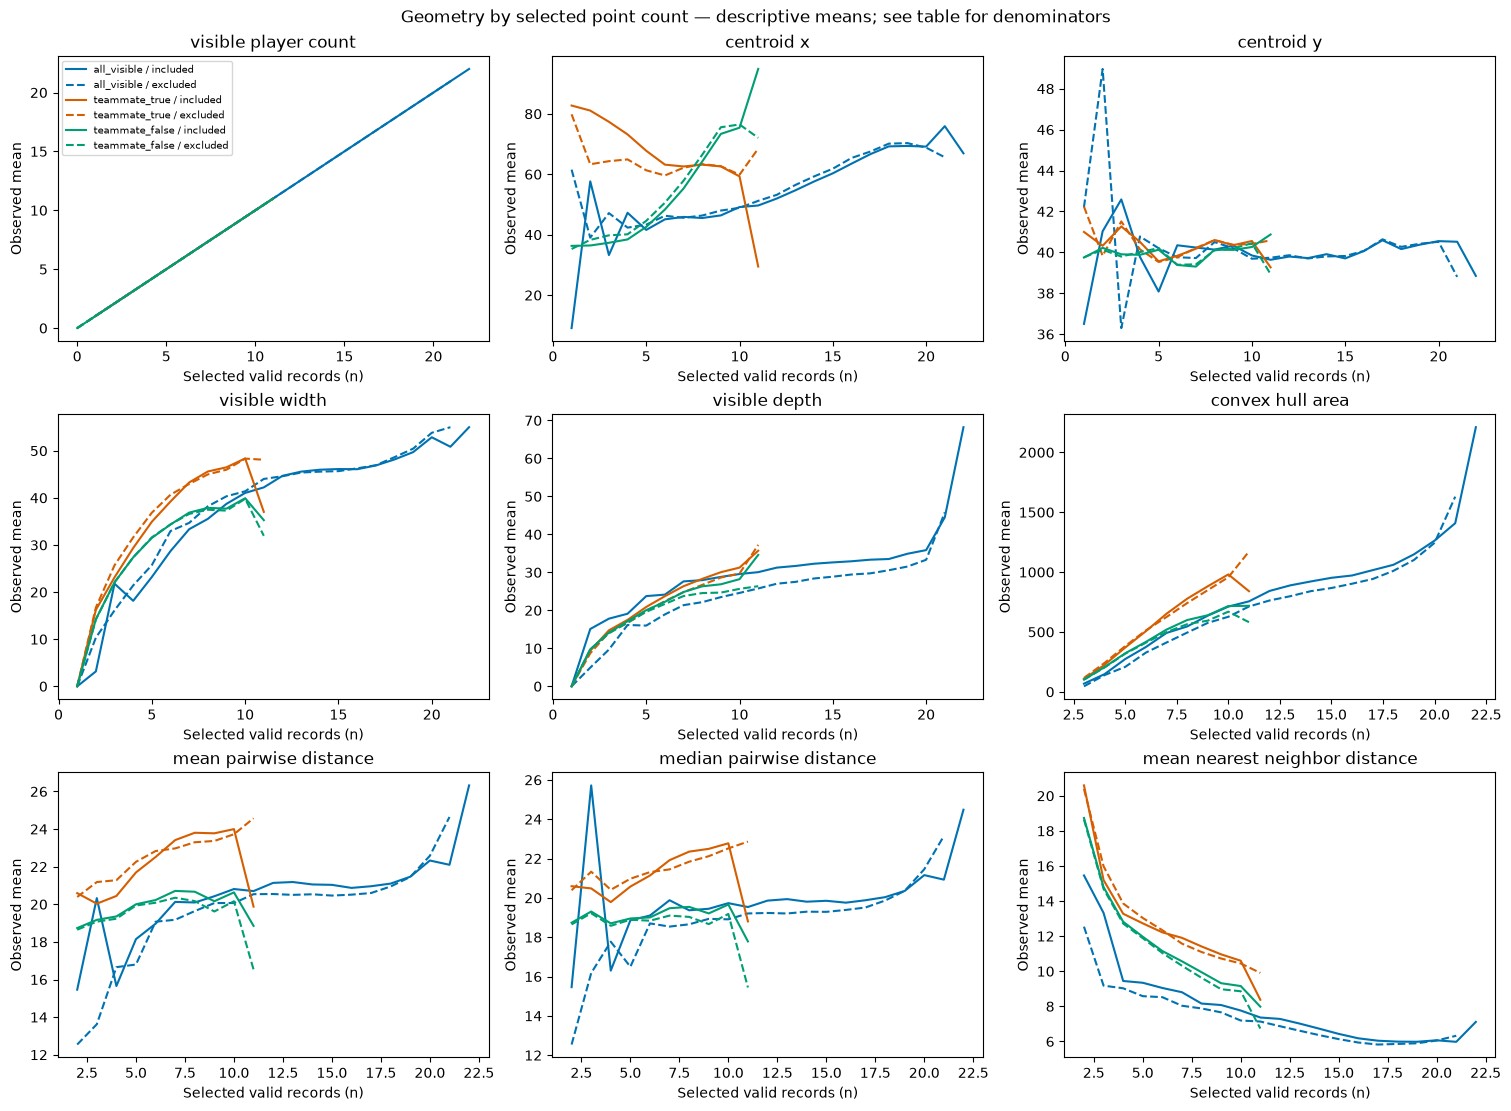

In [5]:
display(summaries['by_valid_points'])
figure = plot_by_valid_points(summaries['by_valid_points'])

## Validation boundary

Coincident records retain their original weights. Multiple/unknown actor statuses are flags, without actor selection or deduplication. Finite out-of-bounds points remain measured and flagged. There is no coordinate flipping, metre conversion, zone assignment, eligibility threshold, sequence construction or later metric here.

Implementation checks and empirical results are recorded in `report/technical_appendix.md`. Representative-frame review, visibility calibration, identity ambiguity and direction-dependent interpretation remain separate work.

# Phase 2B-1 — Observation Sensitivity

Bounded descriptive analysis of the existing Phase 2A frame-variant table. All six literal subset/keeper variants and all recorded quality flags remain in the diagnostic population. No geometry is recomputed and no eligibility or calibration decision is made.

Generate the compact summaries from the repository root with `python scripts/observation_sensitivity.py`. The run summary records the input CSV hash and source revision. Shared visible-area quintiles are display/grouping boundaries, with each original frame contributing once; they are not proposed thresholds.

In [2]:
from leverkusen.spatial.observation_sensitivity import read_observation_sensitivity
from leverkusen.visualization.observation_sensitivity import (
    plot_count_dependence, plot_visible_area_dependence, plot_keeper_deltas,
)

sensitivity = read_observation_sensitivity(root / 'outputs/diagnostics')
display(sensitivity['run_summary'])

,source_file,source_sha256,original_frames,variant_rows,matches,requested_area_bins,effective_area_bins,generated_at_utc,statsbomb_revision
0,phase2a_frame_geometry.csv,a6af9ceb6182c02159de78c8e57ad5ecda635d47e282ee...,118581,711486,34,5,5,2026-09-08T00:44:34.799638+00:00,533862946a73608c134d18b78226b6371ce7173c


## 1. Selected valid-point-count dependence

Each row describes one exact n, subset, keeper policy and existing metric. `frame_count` is the group inventory; `denominator` is the count of defined values used for its statistics; `na_count` is their difference. Standard deviation uses ddof=1 and quantiles use pandas linear interpolation. Undefined hull groups retain their counts with NA statistics.

The figure shows medians for five major metrics across every observed n. The compact CSV includes median pairwise distance as well. Sparse endpoint strata remain in the tables and figure; no minimum reliable n is selected.

,selected_subset,goalkeeper_policy,frame_count,denominator,na_count,mean,median,std,p05,p25,p75,p95,min,max,statsbomb_revision
0,all_visible,excluded,118581,118581,0,16.071580,17.0,3.202193,10.0,14.0,19.0,20.0,0,21,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,118581,118581,0,16.471290,17.0,3.120971,11.0,14.0,19.0,20.0,1,22,533862946a73608c134d18b78226b6371ce7173c
2,teammate_false,excluded,118581,118581,0,8.041701,9.0,1.878042,4.0,7.0,10.0,10.0,0,11,533862946a73608c134d18b78226b6371ce7173c
3,teammate_false,included,118581,118581,0,8.247257,9.0,1.999297,4.0,7.0,10.0,11.0,0,11,533862946a73608c134d18b78226b6371ce7173c
4,teammate_true,excluded,118581,118581,0,8.029878,8.0,1.660417,5.0,7.0,9.0,10.0,0,11,533862946a73608c134d18b78226b6371ce7173c
5,teammate_true,included,118581,118581,0,8.224033,8.0,1.652575,5.0,7.0,10.0,10.0,1,11,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,n_valid_points_used,metric,frame_count,denominator,na_count,mean,median,std,p05,p25,p75,p95,min,max,statsbomb_revision
0,all_visible,excluded,0,visible_width,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,0,visible_depth,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,0,convex_hull_area,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,0,mean_pairwise_distance,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,0,median_pairwise_distance,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,teammate_true,included,11,visible_depth,4278,4278,0,35.695538,35.828642,12.968642,15.367521,25.383645,45.911408,55.973472,6.684371,79.262158,533862946a73608c134d18b78226b6371ce7173c
542,teammate_true,included,11,convex_hull_area,4278,4278,0,840.475777,694.611744,594.914514,152.546916,383.360735,1123.086801,2096.786542,41.073676,3122.356016,533862946a73608c134d18b78226b6371ce7173c
543,teammate_true,included,11,mean_pairwise_distance,4278,4278,0,19.875855,19.301875,7.483896,8.846396,14.177797,24.267359,34.106906,5.448809,42.891658,533862946a73608c134d18b78226b6371ce7173c
544,teammate_true,included,11,median_pairwise_distance,4278,4278,0,18.803640,18.210926,7.399778,8.107611,13.398992,23.008832,32.941768,4.136146,44.912695,533862946a73608c134d18b78226b6371ce7173c


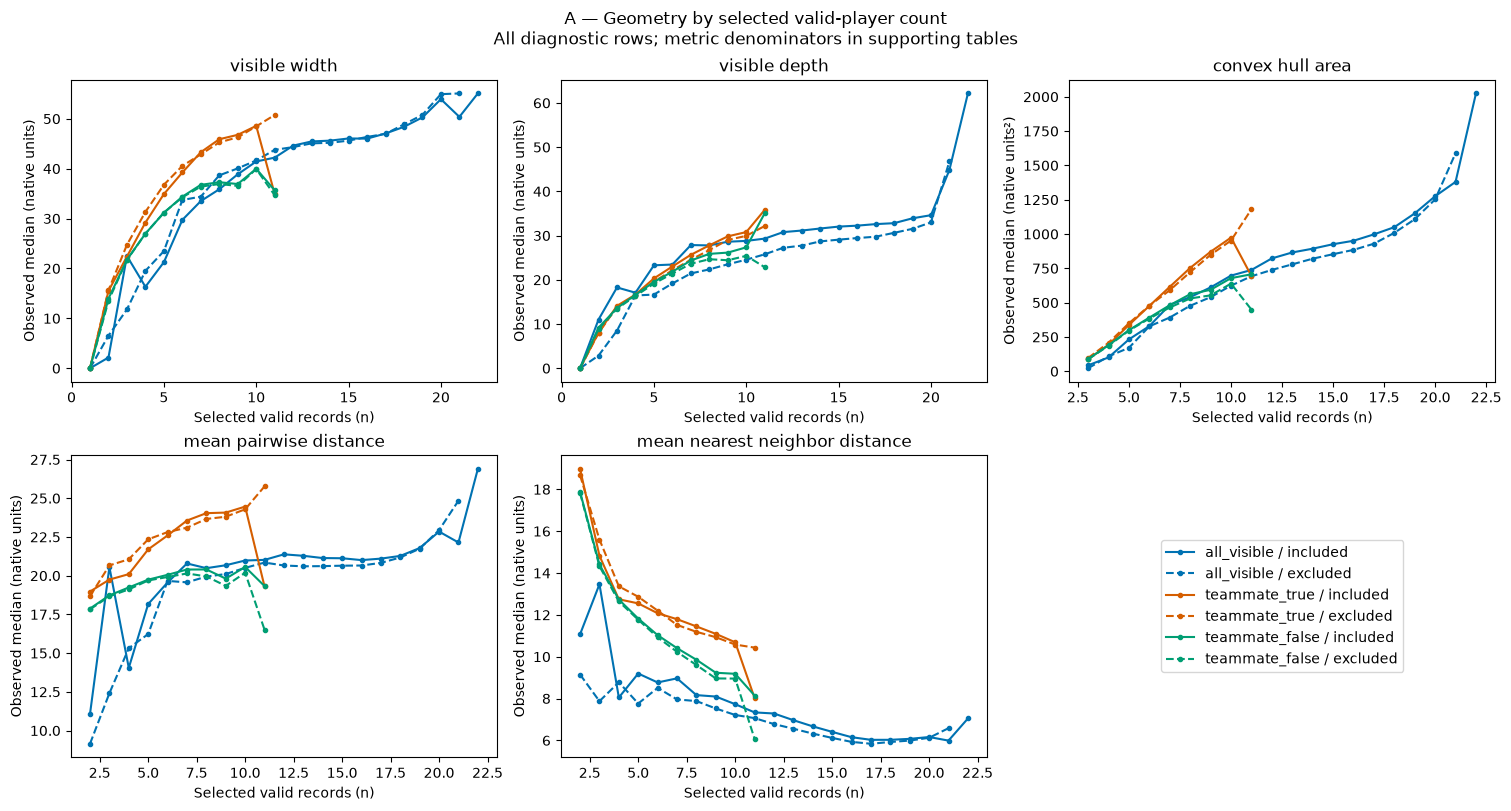

In [3]:
display(sensitivity['player_count_context'])
display(sensitivity['metric_by_valid_point_count'])
figure = plot_count_dependence(sensitivity['metric_by_valid_point_count'])

## 2. Visible-area dependence

The same five coverage bins apply to every variant. Intervals are right closed, with the minimum included in the first bin; ties stay together. Duplicate quantile edges collapse deterministically. Missing coverage has a separate unavailable category if present. Exact bounds and original-frame denominators are shown below.

The joint table describes **n** within each coverage bin: its mean, median, standard deviation and quantiles are selected record counts. These summaries show marginal observed dependence; coverage and player-count relationships are not independently adjusted.

,visible_area_bin,bin_order,lower,upper,lower_inclusive,upper_inclusive,requested_bins,effective_bins,original_frame_count,statsbomb_revision
0,B1,1,0.045220,0.216823,True,True,5,5,23718,533862946a73608c134d18b78226b6371ce7173c
1,B2,2,0.216823,0.265017,False,True,5,5,23715,533862946a73608c134d18b78226b6371ce7173c
2,B3,3,0.265017,0.318402,False,True,5,5,23717,533862946a73608c134d18b78226b6371ce7173c
3,B4,4,0.318402,0.383159,False,True,5,5,23716,533862946a73608c134d18b78226b6371ce7173c
4,B5,5,0.383159,0.861461,False,True,5,5,23715,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,visible_area_bin,metric,frame_count,denominator,na_count,mean,median,std,p05,p25,p75,p95,min,max,statsbomb_revision
0,all_visible,excluded,B1,visible_width,23718,23717,1,38.571426,39.219328,9.280781,22.362169,32.393397,45.085652,52.667951,0.000000,76.679790,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,B1,visible_depth,23718,23717,1,24.872763,25.008745,6.617939,13.742660,20.310096,29.621830,35.341060,0.000000,63.277223,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,B1,convex_hull_area,23718,23713,5,618.297003,593.658056,277.439357,213.250993,405.684823,814.620906,1100.906971,1.156072,2720.715833,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,B1,mean_pairwise_distance,23718,23713,5,17.550792,17.722209,3.900115,11.014586,14.715683,20.426390,23.623926,4.424395,34.992962,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,B1,median_pairwise_distance,23718,23713,5,16.513609,16.759154,3.964004,9.751719,13.655944,19.433974,22.634027,3.267774,35.735121,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,teammate_true,included,B5,visible_depth,23715,23715,0,34.009886,32.894815,8.473227,21.747399,28.528069,38.371173,50.454901,0.000000,85.028597,533862946a73608c134d18b78226b6371ce7173c
176,teammate_true,included,B5,convex_hull_area,23715,23702,13,1098.085017,1088.548157,387.087826,501.661673,826.680524,1333.287077,1756.639648,0.198937,3122.356016,533862946a73608c134d18b78226b6371ce7173c
177,teammate_true,included,B5,mean_pairwise_distance,23715,23711,4,26.727360,27.124532,4.360905,19.026106,23.873847,29.725918,33.469007,8.728171,42.891658,533862946a73608c134d18b78226b6371ce7173c
178,teammate_true,included,B5,median_pairwise_distance,23715,23711,4,25.261960,25.442885,4.360397,17.758265,22.435065,28.172601,32.161779,7.013796,44.912695,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,visible_area_bin,frame_count,denominator,na_count,mean,median,std,p05,p25,p75,p95,min,max,statsbomb_revision
0,all_visible,excluded,B1,23718,23718,0,14.649127,15.0,2.998911,9.0,13.0,17.0,19.0,0,21,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,B2,23715,23715,0,15.543454,16.0,3.095088,10.0,14.0,18.0,20.0,2,21,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,B3,23717,23717,0,15.938103,17.0,3.206182,10.0,14.0,18.0,20.0,1,21,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,B4,23716,23716,0,16.524034,17.0,3.150851,10.0,15.0,19.0,20.0,2,21,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,B5,23715,23715,0,17.703352,19.0,2.702521,12.0,16.0,20.0,20.0,4,21,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,included,B1,23718,23718,0,15.146555,15.0,2.987956,10.0,13.0,17.0,20.0,1,22,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,included,B2,23715,23715,0,15.911406,16.0,3.034624,10.0,14.0,18.0,20.0,3,22,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,included,B3,23717,23717,0,16.329047,17.0,3.091837,10.0,14.0,19.0,20.0,2,22,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,included,B4,23716,23716,0,16.924439,18.0,3.048837,11.0,15.0,19.0,21.0,3,22,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,included,B5,23715,23715,0,18.045161,19.0,2.634560,13.0,17.0,20.0,21.0,4,22,533862946a73608c134d18b78226b6371ce7173c


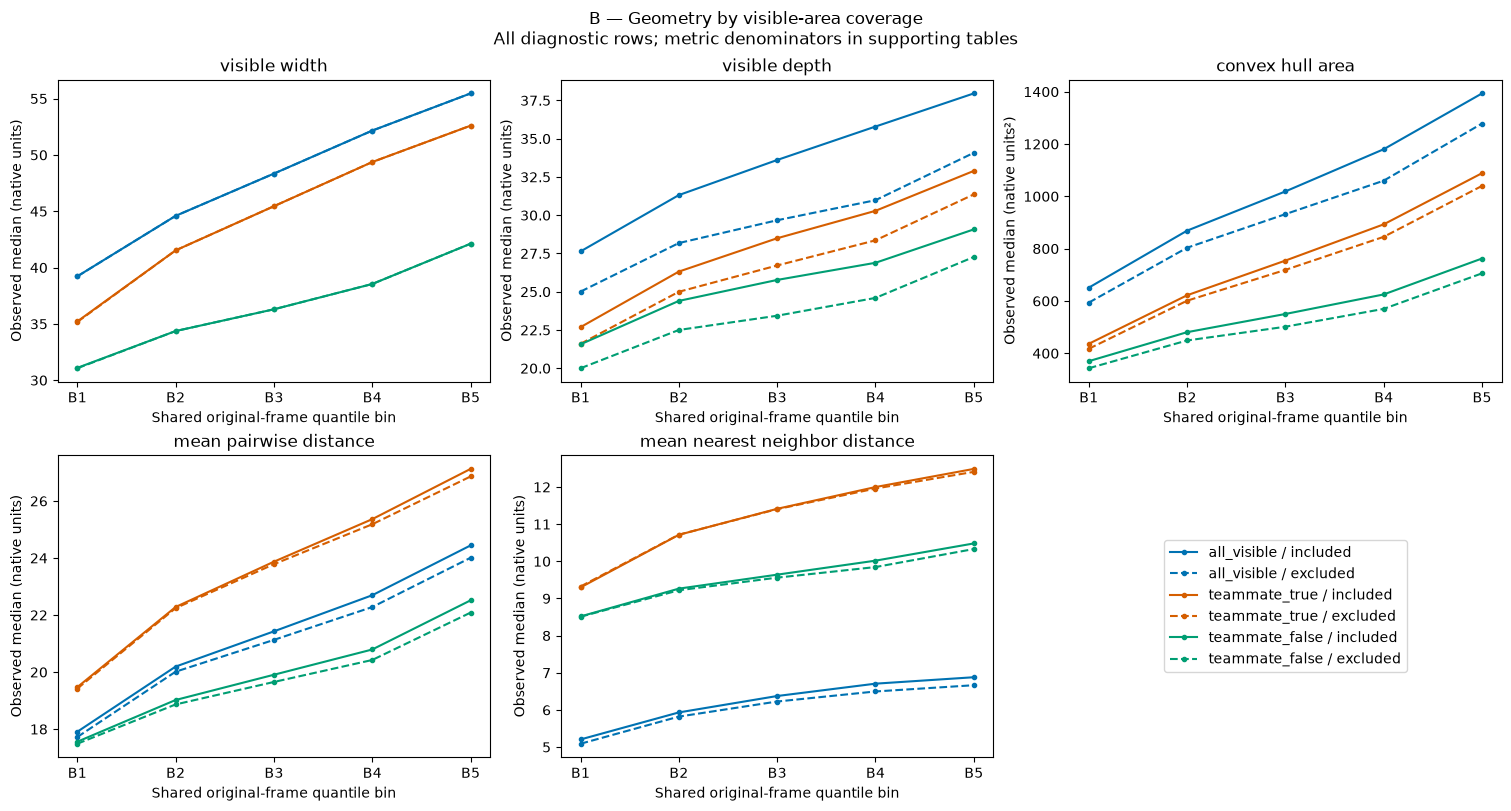

In [4]:
display(sensitivity['visible_area_bins'])
display(sensitivity['metric_by_visible_area'])
display(sensitivity['visibility_vs_player_count'])
figure = plot_visible_area_dependence(
    sensitivity['metric_by_visible_area'], sensitivity['visible_area_bins'],
)

## 3. Goalkeeper sensitivity

Deltas are excluded minus included, paired on match, original frame ordinal and literal subset. Only jointly defined metric values enter comparisons. Tables distinguish `all_frames` and `keeper_removed` scopes, retain total frame counts and NA-pair counts, and disclose unknown keeper omissions separately. The latter scope requires an actual `keeper=True` record removal. No keeper convention is chosen.

`proportion_numerically_changed` uses jointly defined pairs as its denominator and exact nonzero deltas, without a tolerance. Figure C shows the median, interquartile interval and p05–p95 interval for both scopes. These are descriptive distribution intervals, not confidence intervals.

,selected_subset,scope,metric,delta_direction,total_frames,keeper_removed_frames,unknown_keeper_removed_frames,keeper_removal_status_unavailable_frames,scope_frames,jointly_defined_count,...,p05,p25,p75,p95,min,max,mean_absolute_delta,numerically_changed_count,proportion_numerically_changed,statsbomb_revision
0,all_visible,all_frames,visible_width,excluded_minus_included,118581,47394,0,0,118581,118580,...,0.000000,0.000000,0.000000,0.000000,-22.311836,0.000000,0.016687,556,0.004689,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,all_frames,visible_depth,excluded_minus_included,118581,47394,0,0,118581,118580,...,-17.678806,-8.139859,0.000000,0.000000,-54.652932,0.000000,4.167210,45089,0.380241,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,all_frames,convex_hull_area,excluded_minus_included,118581,47394,0,0,118581,118562,...,-400.143918,-146.016491,0.000000,0.000000,-1679.012415,0.000000,87.756434,46831,0.394992,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,all_frames,mean_pairwise_distance,excluded_minus_included,118581,47394,0,0,118581,118574,...,-1.672510,-0.540009,0.000000,0.000000,-20.411957,7.396091,0.361660,47387,0.399641,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,all_frames,median_pairwise_distance,excluded_minus_included,118581,47394,0,0,118581,118574,...,-1.832342,-0.477361,0.000000,0.000000,-30.388413,6.764277,0.385460,45716,0.385548,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,all_frames,mean_nearest_neighbor_distance,excluded_minus_included,118581,47394,0,0,118581,118574,...,-0.835646,-0.306796,0.000000,0.014408,-10.129471,14.118107,0.204189,47387,0.399641,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,keeper_removed,visible_width,excluded_minus_included,118581,47394,0,0,47394,47393,...,0.000000,0.000000,0.000000,0.000000,-22.311836,0.000000,0.041751,556,0.011732,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,keeper_removed,visible_depth,excluded_minus_included,118581,47394,0,0,47394,47393,...,-20.677780,-14.627011,-5.633739,-0.066048,-54.652932,0.000000,10.426598,45089,0.951385,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,keeper_removed,convex_hull_area,excluded_minus_included,118581,47394,0,0,47394,47375,...,-511.783046,-307.104391,-102.049241,-22.256829,-1679.012415,0.000000,219.621707,46831,0.988517,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,keeper_removed,mean_pairwise_distance,excluded_minus_included,118581,47394,0,0,47394,47387,...,-2.207617,-1.251513,-0.303415,0.240787,-20.411957,7.396091,0.904963,47387,1.000000,533862946a73608c134d18b78226b6371ce7173c


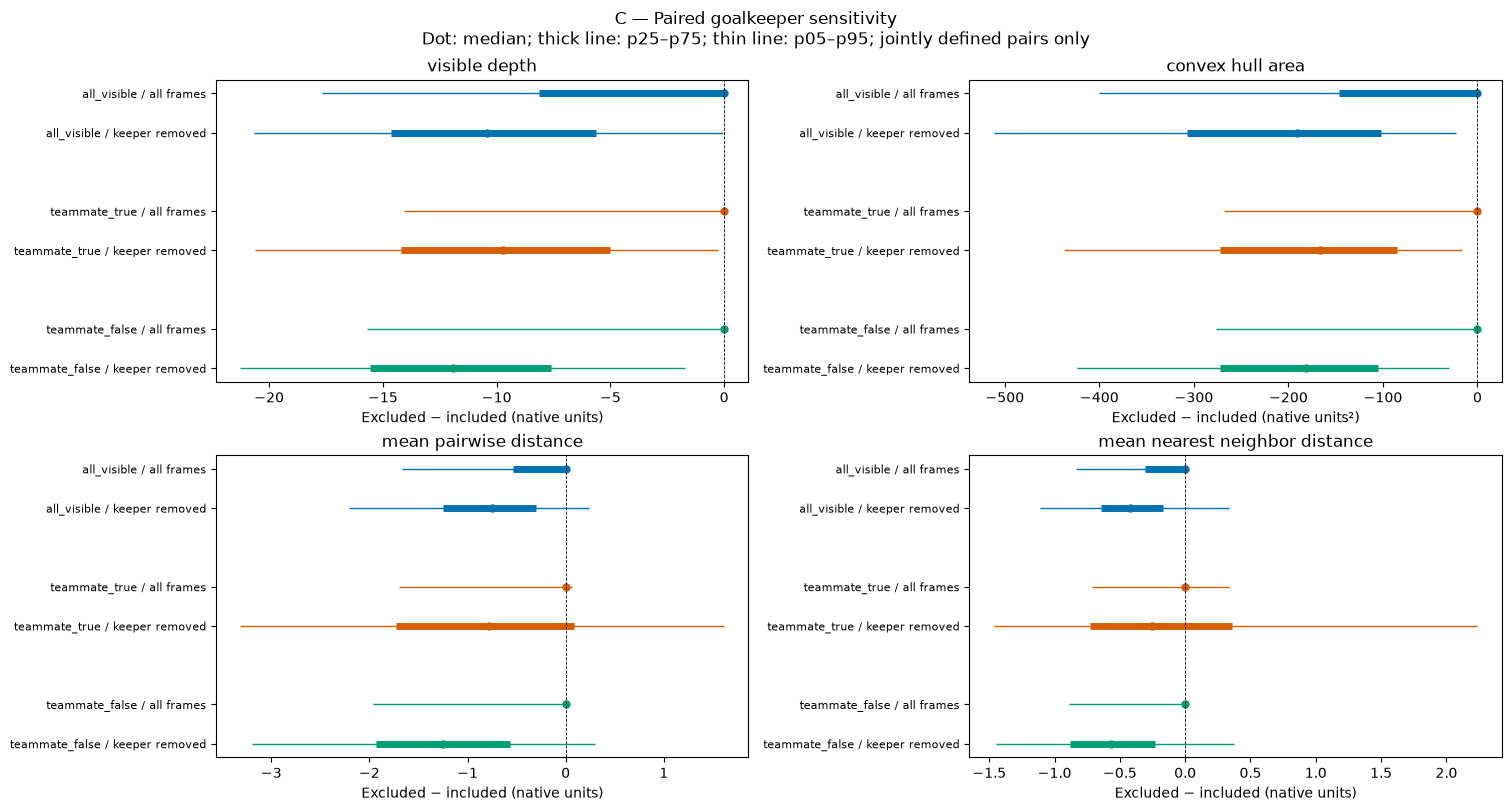

In [5]:
display(sensitivity['goalkeeper_sensitivity'])
figure = plot_keeper_deltas(sensitivity['goalkeeper_sensitivity'])

## 4. Short diagnostic summary

With keepers included, all-visible strata at n=14 and n=19 have median width 45.62 and 50.28, hull area 893.32 and 1,150.46, and mean nearest-neighbor distance 6.67 and 6.07. Their exact-n frame counts are 8,493 and 15,263. The full tables retain both policies and literal teammate subsets.

Across the lowest and highest visible-area quintiles, all-visible included median hull area is 650.77 and 1,393.44; median mean pairwise distance is 17.91 and 24.44. Mean selected n is 15.15 and 18.05. The two bins contain 23,718 and 23,715 original frames. Higher coverage is associated with higher values of all six summarized metrics in these endpoint comparisons across all variants.

Among all-visible frames where a keeper was removed, mean paired depth delta is −10.43 (47,393 defined pairs) and hull delta is −219.62 (47,375 pairs). Width changes in 1.17% of affected defined pairs. The teammate_true mean nearest-neighbor delta is −0.028, while its mean absolute delta is 0.856 (23,006 pairs), indicating variation in both directions.

Player count and coverage co-vary. Nearest-neighbor medians decrease across the selected n comparisons but increase across the coverage endpoints. These marginal associations and paired sensitivities require human review before calibration. They do not establish a tactical effect or justify a threshold. Detailed out-of-bounds, boundary/edge, coincidence, representative-frame and orientation work remains deferred.

# Phase 2B-2 — Observation Quality and Edge Validation

Empirical review of the pinned 118,581 original frames and their six unchanged Phase 2A variants. Run `python scripts/observation_quality.py` from the repository root to regenerate the derived tables and contact sheets. Raw 360 frames are retrieved once per match and retained only in memory. The input geometry hash and pinned revision are recorded below.

**METHODOLOGICAL DECISION:** None selected. These diagnostics neither establish censoring nor choose visibility, player-count, edge or goalkeeper rules. The locked formulas, source revision and calibration YAML remain unchanged.

In [10]:
from IPython.display import Image
from leverkusen.spatial.observation_quality import read_observation_quality

quality = read_observation_quality(root / 'outputs/diagnostics')
display(quality['run_summary'])

,source_file,source_sha256,original_frames,variant_rows,matches,out_of_bounds_frames,coincident_frames,multiple_actor_frames,unknown_keeper_variant_rows,geometry_numeric_error_rows,representative_unique_frames,generated_at_utc,statsbomb_revision,csv_float_precision
0,phase2a_frame_geometry.csv,a6af9ceb6182c02159de78c8e57ad5ecda635d47e282ee...,118581,711486,34,11508,50,4,0,0,28,2026-09-08T20:06:14.783829+00:00,533862946a73608c134d18b78226b6371ce7173c,round_trip


## 1. Out-of-bounds population

Strict nominal-pitch violations retain their supplied coordinates. Axis excursions are `max(0, -x, x-120)` and `max(0, -y, y-80)`; their Euclidean norm is distance to the pitch rectangle. Record-weighted empirical quantiles describe magnitude, with distinct original-frame and match denominators. Equal excursions stay in the same bin.

Point statuses distinguish strict polygon interior, polygon boundary, outside and unavailable. `covered_count` includes both interior and boundary. Distances are unsigned even for outside points; proximity alone does not establish consistency.

,scope,value,measure,affected_frames,affected_matches,covered_count,outside_count,rows,denominator,na_count,mean,min,max,median,p01,p05,p10,p25,p75,p90,p95,p99,statsbomb_revision
0,population,all,pitch_distance,11508,34,0,13812,13812,13812,0,1.816889,0.000099,10.662860,1.380061,0.019911,0.102619,0.212291,0.557954,2.644052,4.093298,5.048831,6.782837,533862946a73608c134d18b78226b6371ce7173c
1,population,all,x_excess,11508,34,0,13812,13812,13812,0,0.130180,0.000000,6.775173,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.247337,0.936363,2.784433,533862946a73608c134d18b78226b6371ce7173c
2,population,all,y_excess,11508,34,0,13812,13812,13812,0,1.687490,0.000000,10.662860,1.230775,0.000000,0.000000,0.000000,0.348862,2.565341,4.065240,5.030351,6.782837,533862946a73608c134d18b78226b6371ce7173c
3,population,all,visible_boundary_distance,11508,34,0,13812,13812,13812,0,1.888550,0.000099,74.146048,1.385617,0.020013,0.102955,0.213436,0.561018,2.667910,4.129201,5.101008,7.022613,533862946a73608c134d18b78226b6371ce7173c
4,sides_violated,1,pitch_distance,11508,34,0,13806,13806,13806,0,1.815670,0.000099,10.662860,1.378967,0.019906,0.102566,0.212245,0.557920,2.642932,4.089282,5.047950,6.782837,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,excursion_quantile,Q1,visible_boundary_distance,2686,34,0,2763,2763,2763,0,0.248959,0.000099,74.146048,0.213433,0.004939,0.020011,0.039343,0.102955,0.323540,0.393703,0.417122,0.439435,533862946a73608c134d18b78226b6371ce7173c
88,excursion_quantile,Q2,pitch_distance,2657,34,0,2762,2762,2762,0,0.703283,0.442108,0.993275,0.696297,0.445772,0.461905,0.488551,0.558050,0.839892,0.931454,0.964241,0.988295,533862946a73608c134d18b78226b6371ce7173c
89,excursion_quantile,Q2,x_excess,2657,34,0,2762,2762,2762,0,0.116594,0.000000,0.991179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.606251,0.793088,0.946342,533862946a73608c134d18b78226b6371ce7173c
90,excursion_quantile,Q2,y_excess,2657,34,0,2762,2762,2762,0,0.586689,0.000000,0.993275,0.650476,0.000000,0.000000,0.000000,0.487911,0.817374,0.918489,0.961031,0.987599,533862946a73608c134d18b78226b6371ce7173c


,bin,lower,upper,lower_inclusive,upper_inclusive,statsbomb_revision
0,Q1,0.000099,0.441603,True,True,533862946a73608c134d18b78226b6371ce7173c
1,Q2,0.441603,0.993416,False,True,533862946a73608c134d18b78226b6371ce7173c
2,Q3,0.993416,1.812470,False,True,533862946a73608c134d18b78226b6371ce7173c
3,Q4,1.812470,3.037753,False,True,533862946a73608c134d18b78226b6371ce7173c
4,Q5,3.037753,10.662860,False,True,533862946a73608c134d18b78226b6371ce7173c


,match_id,population_frames,affected_frames,out_of_bounds_records,rows,denominator,na_count,mean,min,max,median,p01,p05,p10,p25,p75,p90,p95,p99,statsbomb_revision
0,3895052,3181,405,434,434,434,0,2.022185,0.010483,7.443473,1.585243,0.040422,0.125554,0.192883,0.532056,3.127603,4.529139,5.237423,6.792000,533862946a73608c134d18b78226b6371ce7173c
1,3895060,3756,309,380,380,380,0,1.766935,0.000161,7.053545,1.344061,0.021151,0.142292,0.222845,0.581533,2.627501,3.677969,4.975546,6.777991,533862946a73608c134d18b78226b6371ce7173c
2,3895067,3389,257,284,284,284,0,1.822793,0.006542,7.165605,1.269158,0.014942,0.119435,0.267883,0.678976,2.538118,4.025280,5.276045,6.143707,533862946a73608c134d18b78226b6371ce7173c
3,3895074,3793,299,360,360,360,0,1.881286,0.008389,9.439827,1.379850,0.036112,0.161605,0.246102,0.587705,2.513622,4.259943,5.360789,8.220345,533862946a73608c134d18b78226b6371ce7173c
4,3895086,3567,292,362,362,362,0,1.633056,0.006344,6.347685,1.176962,0.036976,0.091086,0.182588,0.420209,2.534532,3.900008,4.612737,5.595335,533862946a73608c134d18b78226b6371ce7173c
5,3895095,3570,257,303,303,303,0,1.643970,0.000653,6.758936,1.248689,0.004995,0.059254,0.134360,0.423429,2.414134,3.904246,4.575256,6.036212,533862946a73608c134d18b78226b6371ce7173c
6,3895107,3792,397,476,476,476,0,1.788570,0.000734,7.770960,1.374089,0.027754,0.112575,0.233959,0.613710,2.619731,3.699397,4.810518,6.674023,533862946a73608c134d18b78226b6371ce7173c
7,3895113,3506,469,561,561,561,0,2.041769,0.004072,9.900286,1.612261,0.020117,0.151876,0.265618,0.651145,3.178816,4.178106,5.078252,7.562876,533862946a73608c134d18b78226b6371ce7173c
8,3895121,3373,426,529,529,529,0,1.920240,0.000320,7.751853,1.440649,0.024062,0.090441,0.180887,0.584620,2.876859,4.307765,5.306409,7.018226,533862946a73608c134d18b78226b6371ce7173c
9,3895134,3427,193,205,205,205,0,1.124298,0.004920,4.581076,0.902863,0.013254,0.041494,0.166031,0.551281,1.545521,2.318416,3.113237,4.165909,533862946a73608c134d18b78226b6371ce7173c


,event_type,population_frames,affected_frames,out_of_bounds_records,rows,denominator,na_count,mean,min,max,median,p01,p05,p10,p25,p75,p90,p95,p99,statsbomb_revision
0,50/50,180,14,18,18,18,0,1.200510,0.024432,2.837871,0.995332,0.024432,0.024432,0.299358,0.642654,1.789327,2.324491,2.837871,2.837871,533862946a73608c134d18b78226b6371ce7173c
1,Ball Receipt*,33398,3138,3785,3785,3785,0,1.870309,0.000099,10.662860,1.453914,0.020871,0.106518,0.217997,0.569802,2.761908,4.171975,5.048060,6.838767,533862946a73608c134d18b78226b6371ce7173c
2,Ball Recovery,2862,193,262,262,262,0,1.546029,0.008389,9.439827,1.080517,0.014513,0.058664,0.094536,0.338793,2.176399,4.048016,4.992021,6.479073,533862946a73608c134d18b78226b6371ce7173c
3,Block,1273,107,139,139,139,0,1.481940,0.006903,7.770960,0.979229,0.015190,0.096824,0.191314,0.431285,2.236576,3.532953,4.186252,5.695497,533862946a73608c134d18b78226b6371ce7173c
4,Carry,28741,2751,3306,3306,3306,0,1.902982,0.000161,9.439827,1.479276,0.025902,0.105871,0.223991,0.590174,2.824668,4.227717,5.106092,6.782594,533862946a73608c134d18b78226b6371ce7173c
5,Clearance,1151,87,106,106,106,0,0.865792,0.004072,3.323392,0.551486,0.007968,0.041972,0.083355,0.249130,1.210860,2.135851,2.795119,3.290935,533862946a73608c134d18b78226b6371ce7173c
6,Dispossessed,642,54,74,74,74,0,1.715822,0.015688,7.829244,1.382999,0.048659,0.110306,0.260054,0.565637,2.145536,4.194390,5.118787,6.373923,533862946a73608c134d18b78226b6371ce7173c
7,Dribble,773,54,62,62,62,0,1.628631,0.018910,8.220345,1.316734,0.032488,0.120598,0.235635,0.579271,2.156773,3.426714,4.081710,6.389685,533862946a73608c134d18b78226b6371ce7173c
8,Dribbled Past,446,28,35,35,35,0,2.093852,0.041169,8.220345,1.704770,0.174416,0.454423,0.509053,0.753567,3.159144,3.577813,4.538880,7.199977,533862946a73608c134d18b78226b6371ce7173c
9,Duel,1739,109,133,133,133,0,1.361981,0.015688,7.829244,0.893054,0.021874,0.063866,0.142381,0.409956,1.758846,3.459300,4.463245,5.476399,533862946a73608c134d18b78226b6371ce7173c


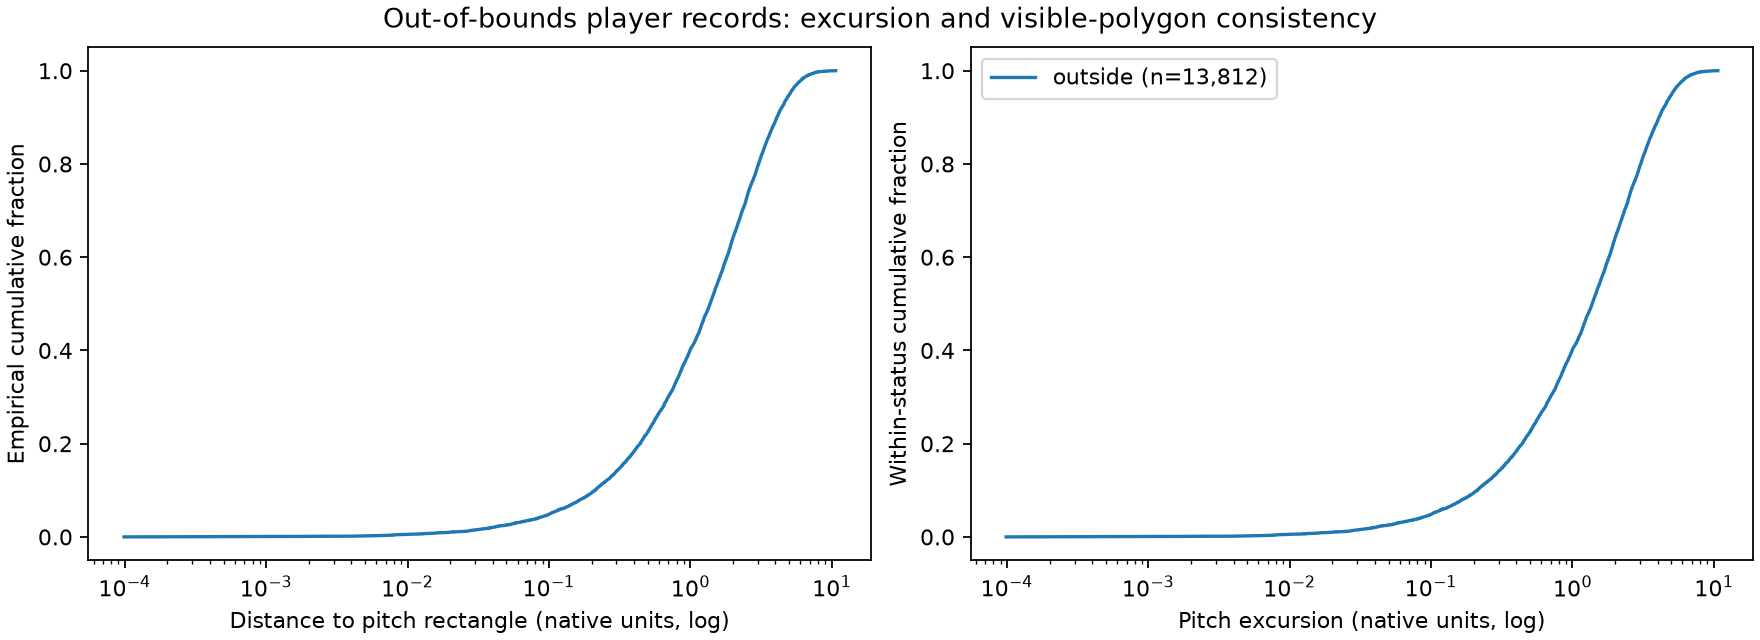

In [11]:
display(quality['out_of_bounds_summary'])
display(quality['excursion_quantile_bins'])
display(quality['out_of_bounds_by_match'])
display(quality['out_of_bounds_by_event_type'])
display(Image(filename=str(root / 'outputs/figures/phase2b2_out_of_bounds_excursions.png')))

## 2. Visible polygon behavior

Containment, boundary intersection and outside extension use exact Shapely predicates without buffering or repair. Area outside is measured from the original polygon. **Existing `visible_area_fraction` remains pitch-intersection area / 9,600**, while `fraction_outside_pitch` uses the original polygon area as denominator. Invalid polygons remain unavailable.

,scope,measure,valid_polygons,contained_count,intersects_boundary_count,extends_outside_count,rows,denominator,na_count,mean,min,max,median,p01,p05,p10,p25,p75,p90,p95,p99,statsbomb_revision
0,all_frames,area_inside_pitch,118581,118581,118185,0,118581,118581,0,2883.184831,434.112653,8270.029316,2791.774519,1232.763244,1609.600879,1812.003667,2202.484775,3502.815870,4080.708540,4409.223886,5082.412499,533862946a73608c134d18b78226b6371ce7173c
1,all_frames,area_outside_pitch,118581,118581,118185,0,118581,118581,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,533862946a73608c134d18b78226b6371ce7173c
2,all_frames,fraction_outside_pitch,118581,118581,118185,0,118581,118581,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,533862946a73608c134d18b78226b6371ce7173c
3,all_frames,visible_area_fraction,118581,118581,118185,0,118581,118581,0,0.300332,0.045220,0.861461,0.290810,0.128413,0.167667,0.188750,0.229425,0.364877,0.425074,0.459294,0.529418,533862946a73608c134d18b78226b6371ce7173c
4,extends_outside,area_inside_pitch,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
5,extends_outside,area_outside_pitch,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
6,extends_outside,fraction_outside_pitch,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c
7,extends_outside,visible_area_fraction,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533862946a73608c134d18b78226b6371ce7173c


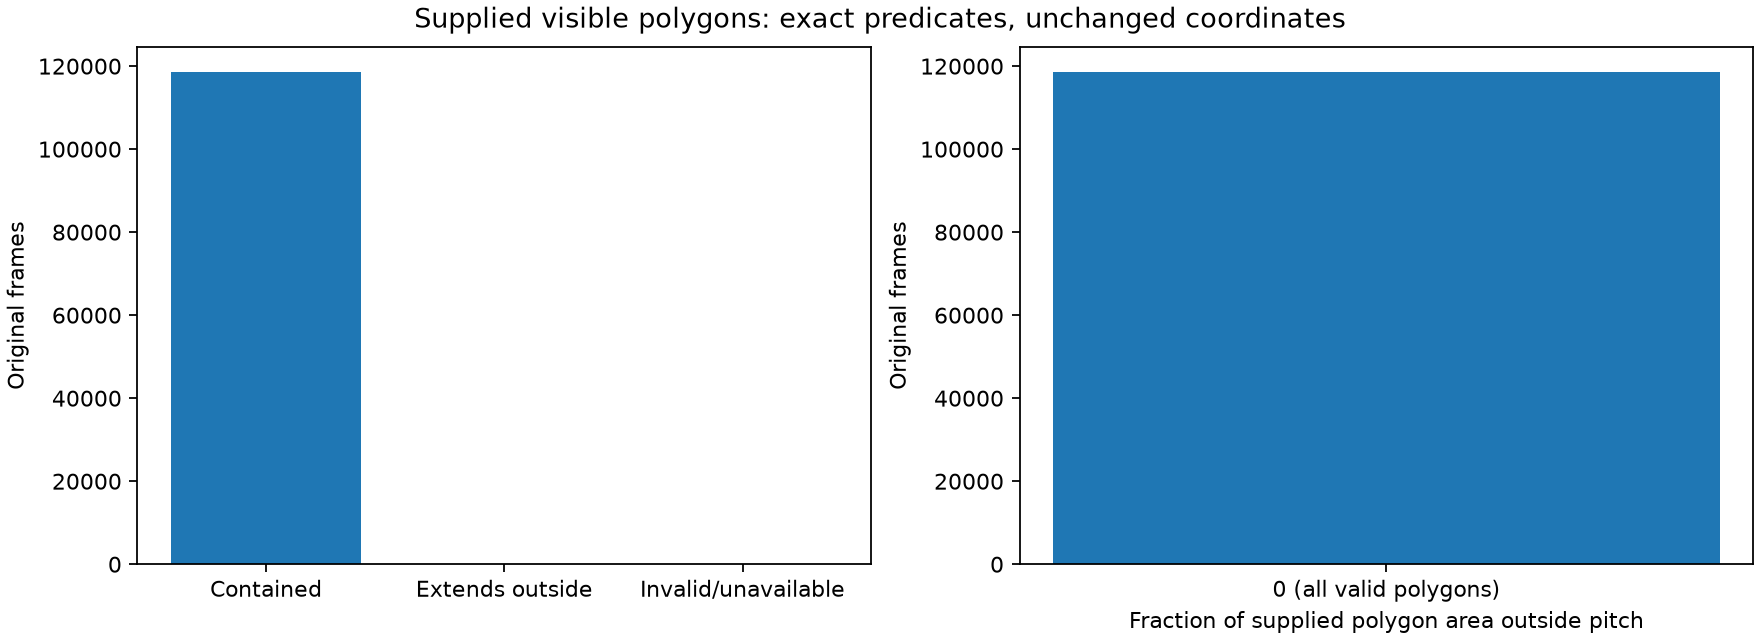

In [12]:
display(quality['visible_polygon_bounds_summary'])
display(Image(filename=str(root / 'outputs/figures/phase2b2_visible_polygon_bounds.png')))

## 3. Edge-distance diagnostics

Every variant with a valid polygon and nonempty selected points has min/max-x and min/max-y defining-point boundary distances plus minimum/median selected distances. All extreme ties are retained; named scalar extreme distances use the minimum among tied defining records. The supplemental `phase2b2_tied_extreme_distances.csv` records each tied distance. These quantities measure the supplied polygon boundary, which may coincide with the nominal pitch boundary; they do not identify unseen players.

The summary reports continuous quantiles and exact boundary coincidences. No "near edge" cutoff or eligibility filter is introduced.

In [13]:
display(quality['edge_distance_summary'])

,selected_subset,goalkeeper_policy,measure,rows,denominator,na_count,mean,min,max,median,p01,p05,p10,p25,p75,p90,p95,p99,exact_boundary_count,outside_selected_frames,statsbomb_revision
0,all_visible,excluded,min_x_edge_distance,118581,118580,1,6.490409,0.000000,83.755816,5.431185,0.109659,0.427430,0.864689,2.533133,9.147895,13.653678,16.576843,21.838955,5,19284,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,max_x_edge_distance,118581,118580,1,6.344978,0.000000,91.389268,4.859845,0.047879,0.287420,0.570250,1.869402,9.532303,14.582491,17.353918,21.908627,276,19284,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,min_y_edge_distance,118581,118580,1,6.960037,0.000000,91.389268,5.589597,0.049939,0.296246,0.807722,2.566844,10.108579,15.067822,18.214519,23.400741,116,19284,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,max_y_edge_distance,118581,118580,1,6.992234,0.000000,74.146048,5.768316,0.036980,0.290016,0.793058,2.599998,10.188444,14.927893,18.017842,23.097453,377,19284,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,minimum_selected_edge_distance,118581,118580,1,1.700695,0.000000,58.236354,1.139215,0.005226,0.065096,0.141597,0.412379,2.470481,4.044711,5.132033,7.417930,509,19284,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,excluded,median_selected_edge_distance,118581,118580,1,10.702404,0.766652,78.087831,10.671858,4.215147,5.878408,6.905547,8.679199,12.646573,14.387455,15.512239,17.794045,0,19284,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,included,min_x_edge_distance,118581,118581,0,5.260709,0.000000,83.755816,4.419601,0.098896,0.391126,0.741801,2.098020,7.417115,10.800003,13.137368,17.872047,3,20582,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,included,max_x_edge_distance,118581,118581,0,4.701568,0.000000,91.389268,3.518131,0.043498,0.266168,0.504976,1.500653,6.550238,10.592353,13.339091,18.669300,266,20582,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,included,min_y_edge_distance,118581,118581,0,6.948398,0.000000,91.389268,5.572777,0.049939,0.295280,0.807083,2.562087,10.082077,15.046228,18.199361,23.400263,116,20582,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,included,max_y_edge_distance,118581,118581,0,6.978658,0.000000,74.146048,5.750905,0.036756,0.289216,0.791269,2.594434,10.159777,14.905841,18.008642,23.095498,377,20582,533862946a73608c134d18b78226b6371ce7173c


## 4. Metric/edge relationships

Within each variant and edge measure, empirical quintiles retain ties and collapse duplicate edges. Exact bin endpoints, row inventories, defined-metric denominators, median selected n and median coverage accompany the metric summaries. Missing edge distances have a separate group. These marginal relationships do not adjust for n, coverage, event type or goalkeeper composition.

,selected_subset,goalkeeper_policy,metric,edge_measure,bin,lower,upper,lower_inclusive,upper_inclusive,edge_median,n_median,coverage_median,rows,denominator,na_count,mean,min,max,median,p01,p05,p10,p25,p75,p90,p95,p99,statsbomb_revision
0,all_visible,excluded,visible_width,min_y_edge_distance,Q1,0.000000,2.000000,True,True,0.807954,17.0,0.269975,23723,23723,0,50.977542,0.000000,81.286486,51.063226,25.485825,32.982657,37.398592,43.992424,58.514903,64.890630,67.875684,72.233698,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,visible_width,min_y_edge_distance,Q2,2.000000,4.300000,False,True,3.131456,17.0,0.277784,23712,23712,0,49.842114,5.576607,77.820317,50.008476,23.832939,31.810029,35.669868,42.726668,57.457100,64.043209,67.399959,72.000224,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,visible_width,min_y_edge_distance,Q3,4.300000,7.151613,False,True,5.590054,17.0,0.281614,23714,23714,0,47.400838,3.649250,78.592737,47.442460,20.122555,28.973165,33.152991,40.122966,55.265992,61.794197,65.499869,70.320787,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,visible_width,min_y_edge_distance,Q4,7.151613,11.404223,False,True,8.975556,16.0,0.282802,23715,23715,0,44.725240,4.652472,77.385244,44.463713,18.761249,26.329329,30.339622,36.997491,52.526270,60.090000,64.040832,68.726616,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,visible_width,min_y_edge_distance,Q5,11.404223,91.389268,False,True,15.067922,17.0,0.339529,23716,23716,0,44.296736,0.000000,76.679790,44.527829,19.704145,26.796719,30.893344,37.199124,51.912003,57.761623,60.538181,65.026850,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,teammate_true,included,convex_hull_area,minimum_selected_edge_distance,Q1,0.000000,0.512047,True,True,0.224319,9.0,0.274823,23717,23715,2,895.761829,3.336253,3027.879080,868.356724,177.495371,340.994139,442.594135,628.205234,1123.013985,1381.820251,1551.502464,1932.392849,533862946a73608c134d18b78226b6371ce7173c
166,teammate_true,included,convex_hull_area,minimum_selected_edge_distance,Q2,0.512047,1.335717,False,True,0.876886,9.0,0.283061,23716,23714,2,842.027115,8.669685,3097.577597,806.381683,145.231898,286.056504,384.188053,571.765168,1081.674143,1334.370148,1503.782380,1882.633837,533862946a73608c134d18b78226b6371ce7173c
167,teammate_true,included,convex_hull_area,minimum_selected_edge_distance,Q3,1.335717,2.414894,False,True,1.858536,9.0,0.284515,23716,23694,22,788.712001,10.592575,3122.356016,755.110011,123.311914,237.131436,330.764495,514.727175,1025.480063,1273.832545,1443.400008,1796.144730,533862946a73608c134d18b78226b6371ce7173c
168,teammate_true,included,convex_hull_area,minimum_selected_edge_distance,Q4,2.414894,3.950426,False,True,3.098192,8.0,0.298244,23717,23696,21,737.309656,6.585488,2956.090708,700.002367,103.151840,213.929519,294.320085,462.808318,970.099453,1221.962474,1381.772071,1742.186008,533862946a73608c134d18b78226b6371ce7173c


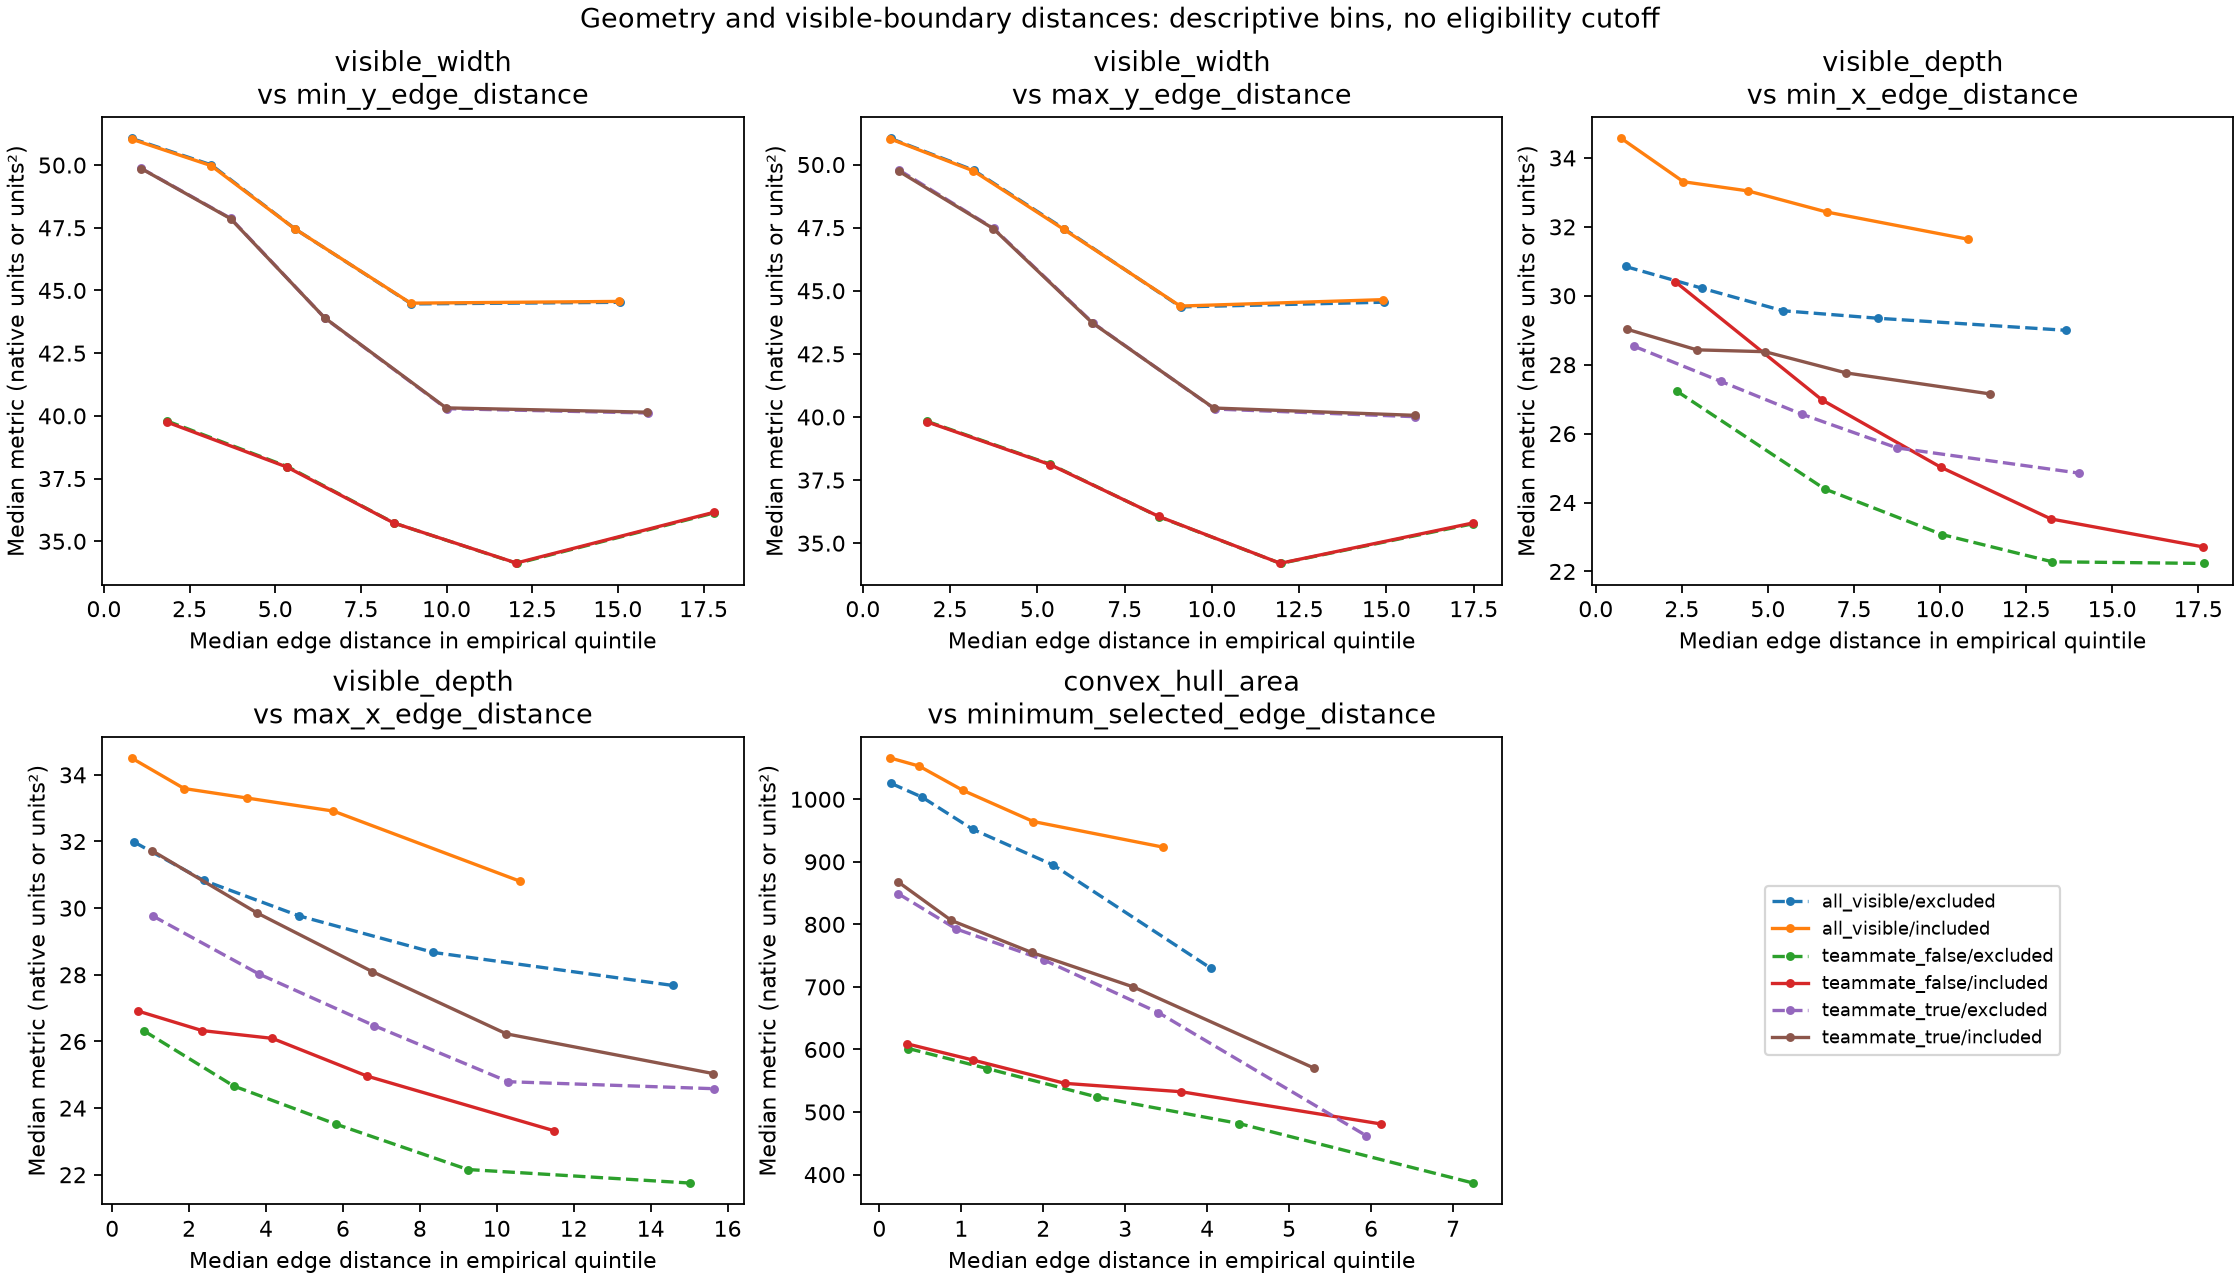

In [14]:
display(quality['metric_edge_relationship'])
display(Image(filename=str(root / 'outputs/figures/phase2b2_metric_edge_relationship.png')))

## 5. Coincident and multiple-actor review

Exact-coordinate groups describe records, not verified duplicate player identities. All original records remain retained. The separate multiplicity diagnostic adds one record at each already-coincident selected location in turn, then compares the unchanged locked formulas with their original values. These perturbations demonstrate sensitivity; they are not corrected measurements or estimates of actual bias. There is no deduplication.

All four known multiple-actor frames receive a diagnostic row and a pitch visualization. Actor pair distances and literal teammate/keeper flags are retained without resolving actor identity. Actor flags alone do not enter the numerical geometry formulas.

In [15]:
display(quality['coincident_records_summary'])
display(quality['coincident_metric_sensitivity'])
display(quality['multiple_actor_review'])

,scope,value,groups,affected_frames,affected_matches,excess_records,records_in_groups,teammate_True_count,teammate_False_count,keeper_True_count,keeper_False_count,actor_True_count,actor_False_count,teammate_unknown_count,keeper_unknown_count,actor_unknown_count,statsbomb_revision
0,population,all,52,50,5,52,104,60,44,2,102,8,96,0,0,0,533862946a73608c134d18b78226b6371ce7173c
1,match_id,3895060,4,4,1,4,8,6,2,0,8,0,8,0,0,0,533862946a73608c134d18b78226b6371ce7173c
2,match_id,3895139,44,42,1,44,88,48,40,2,86,8,80,0,0,0,533862946a73608c134d18b78226b6371ce7173c
3,match_id,3895275,2,2,1,2,4,4,0,0,4,0,4,0,0,0,533862946a73608c134d18b78226b6371ce7173c
4,match_id,3895286,1,1,1,1,2,0,2,0,2,0,2,0,0,0,533862946a73608c134d18b78226b6371ce7173c
5,match_id,3895292,1,1,1,1,2,2,0,0,2,0,2,0,0,0,533862946a73608c134d18b78226b6371ce7173c
6,event_type,Ball Receipt*,10,10,2,10,20,10,10,0,20,2,18,0,0,0,533862946a73608c134d18b78226b6371ce7173c
7,event_type,Ball Recovery,1,1,1,1,2,2,0,0,2,0,2,0,0,0,533862946a73608c134d18b78226b6371ce7173c
8,event_type,Carry,10,10,3,10,20,8,12,0,20,0,20,0,0,0,533862946a73608c134d18b78226b6371ce7173c
9,event_type,Dispossessed,1,1,1,1,2,2,0,0,2,2,0,0,0,0,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,metric,rows,denominator,na_count,mean,min,max,median,p01,p05,p10,p25,p75,p90,p95,p99,changed_exact_count,max_absolute_delta,status_changed_count,statsbomb_revision
0,all_visible,excluded,centroid_x,51,51,0,0.031854,-1.418099,0.988514,0.114278,-1.289339,-0.851474,-0.774976,-0.306905,0.422830,0.727311,0.778096,0.988514,51,1.418099,0,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,centroid_y,51,51,0,-0.050832,-1.951063,1.724895,0.003229,-1.901795,-1.670885,-1.577485,-0.590405,0.692536,0.941943,1.307728,1.682339,51,1.951063,0,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,convex_hull_area,51,51,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,mean_nearest_neighbor_distance,51,51,0,-0.313964,-1.155547,-0.159017,-0.285285,-0.823453,-0.479590,-0.383544,-0.340206,-0.250364,-0.232080,-0.204707,-0.159017,51,1.155547,0,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,mean_pairwise_distance,51,51,0,0.087441,-1.447277,1.380952,0.023366,-1.346194,-0.992160,-0.633071,-0.371203,0.540292,1.016666,1.282155,1.370778,51,1.447277,0,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,excluded,median_pairwise_distance,51,51,0,0.229772,-1.604703,1.810662,0.074264,-1.604703,-1.087073,-0.499484,-0.199793,0.573537,1.418610,1.667405,1.778373,46,1.810662,0,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,excluded,visible_depth,51,51,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,excluded,visible_player_count,51,51,0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,51,1.000000,0,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,excluded,visible_width,51,51,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,included,centroid_x,52,52,0,0.034068,-1.146988,0.988514,0.072017,-1.112762,-0.858811,-0.792955,-0.308410,0.411804,0.684447,0.782576,0.988514,52,1.146988,0,533862946a73608c134d18b78226b6371ce7173c


,match_id,frame_index,event_id,event_type,actor_count,valid_actor_count,unique_actor_locations,actor_pair_distance_min,actor_pair_distance_max,coincident_actor_excess,actor_teammate_True_count,actor_teammate_False_count,actor_keeper_True_count,actor_keeper_False_count,visible_player_count,centroid_x,centroid_y,visible_width,visible_depth,convex_hull_area,mean_pairwise_distance,median_pairwise_distance,mean_nearest_neighbor_distance,geometry_policy,statsbomb_revision
0,3895139,472,fdb22e5a-a841-4f0a-871f-5628deffa2c5,Pass,2,2,1,0.0,0.0,1,2,0,0,2,8,16.718899,40.378221,35.910424,30.625512,540.148579,21.091517,21.340705,8.936225,unchanged records retained; actor flag is not ...,533862946a73608c134d18b78226b6371ce7173c
1,3895139,693,3e29e673-5de2-4f22-b0c9-0d298431320b,Dispossessed,2,2,1,0.0,0.0,1,2,0,0,2,15,48.133799,23.354899,41.461690,26.971562,675.401466,18.449153,17.707161,5.566013,unchanged records retained; actor flag is not ...,533862946a73608c134d18b78226b6371ce7173c
2,3895139,1689,c766113e-d3c8-4c8c-9685-ac26faa2bfd6,Pass,2,2,1,0.0,0.0,1,2,0,0,2,19,76.244861,24.526308,52.445970,33.873243,1298.570578,24.191412,22.862282,7.066623,unchanged records retained; actor flag is not ...,533862946a73608c134d18b78226b6371ce7173c
3,3895139,1733,61d8965a-fcaa-41c1-b98f-4add7693b817,Ball Receipt*,2,2,1,0.0,0.0,1,2,0,0,2,17,103.540521,40.976318,44.710562,29.945462,781.705165,18.333845,16.748450,5.792928,unchanged records retained; actor flag is not ...,533862946a73608c134d18b78226b6371ce7173c


## 6. Deterministic representative frames

Selection uses exact axis/side excursion extremes, the smallest positive excursion, minimum/median/maximum coverage, minimum/maximum all-visible count, both tails of five major metrics among defined-hull observations, largest absolute paired keeper changes in depth/hull/centroid x, all multiple-actor frames and three coincident event-type examples. Stable match/frame/subset/policy order resolves ties. Multiple selection rules can reference one rendered frame. The rule table retains the variant and selection value for every reason.

Each contact sheet plots native provider axes and the unmodified visible polygon, finite points, literal teammate flags, keeper/actor markers, out-of-bounds rings and the displayed selected hull. Faded points are outside the displayed subset/policy. Multiplicity labels show coincident records without moving them. Full identifiers, counts, coverage and metrics appear above each panel. All geometry remains observational; no direction, identity, formation or tactical zone is inferred.

,match_id,frame_index,event_id,event_id_raw_type,invalid_event_id_scalar,event_type,event_join_status,statsbomb_revision,total_visible_players,n_non_dictionary_records,n_invalid_locations,n_unknown_teammate,actor_count,n_unknown_actor_flags,actor_status,freeze_frame_status,visible_area_status,visible_area_exists,visible_area_missing,visible_area_coordinate_count,visible_area_vertex_count,visible_area_malformed,visible_area_valid,visible_area_reason,visible_area_polygon_area,visible_area_on_pitch_area,visible_area_fraction,visible_area_outside_pitch,selected_subset,goalkeeper_policy,n_valid_points_used,n_unique_points,n_coincident_records,n_out_of_bounds_points,n_keeper_true_before_filter,n_keeper_unknown_before_filter,n_keeper_true_excluded,n_keeper_unknown_excluded,measurement_flags,visible_player_count,...,centroid_y_status,visible_width_status,visible_depth_status,convex_hull_area_status,mean_pairwise_distance_status,median_pairwise_distance_status,mean_nearest_neighbor_distance_status,hull_error_category,abs_keeper_delta_visible_depth,abs_keeper_delta_convex_hull_area,abs_keeper_delta_centroid_x,min_x_edge_distance,max_x_edge_distance,min_y_edge_distance,max_y_edge_distance,minimum_selected_edge_distance,median_selected_edge_distance,edge_status,selected_outside_polygon_count,min_x_tied_records,max_x_tied_records,min_y_tied_records,max_y_tied_records,contained_in_pitch,intersects_pitch_boundary,extends_outside_pitch,area_inside_pitch,area_outside_pitch,fraction_outside_pitch,max_x_excess,max_y_excess,max_pitch_distance,min_positive_pitch_distance,count_x_below_0,count_x_above_120,count_y_below_0,count_y_above_80,selection_rule,selection_field,selection_value
0,3895250,1969,59772c3d-a609-4ad3-8ebb-05a40b2ebd75,str,NaN,Ball Recovery,unique,533862946a73608c134d18b78226b6371ce7173c,17,0,0,0,1,0,single,available,valid,True,False,10,5,False,True,valid,964.330210,964.330210,0.100451,False,all_visible,included,17,17,0,4,1,0,0,0,out_of_bounds_points,17,...,ok,ok,ok,ok,ok,ok,ok,NaN,0.000000,101.552272,0.643124,0.874797,6.775173,3.000000,0.773030,0.773030,4.201834,ok,4.0,1.0,1.0,1.0,1.0,True,True,False,964.330210,0.0,0.0,6.775173,0.000000,6.775173,0.986470,0,4,0,0,max_x_excess,max_x_excess,6.775173
1,3895309,2436,5664489f-4108-42b1-abe9-527ff09d4cf0,str,NaN,Ball Receipt*,unique,533862946a73608c134d18b78226b6371ce7173c,13,0,0,0,1,0,single,available,valid,True,False,10,5,False,True,valid,2021.166638,2021.166638,0.210538,False,all_visible,included,13,13,0,2,0,0,0,0,out_of_bounds_points,13,...,ok,ok,ok,ok,ok,ok,ok,NaN,0.000000,0.000000,0.000000,4.400002,0.460179,11.475065,10.662860,0.460179,6.498747,ok,2.0,1.0,1.0,1.0,1.0,True,True,False,2021.166638,0.0,0.0,0.000000,10.662860,10.662860,6.096261,0,0,0,2,max_y_excess,max_y_excess,10.662860
2,3895232,1520,cc45158f-bf83-4410-87e5-bb42a128e62e,str,NaN,Ball Receipt*,unique,533862946a73608c134d18b78226b6371ce7173c,18,0,0,0,1,0,single,available,valid,True,False,10,5,False,True,valid,1894.836118,1894.836118,0.197379,False,all_visible,included,18,18,0,2,0,0,0,0,out_of_bounds_points,18,...,ok,ok,ok,ok,ok,ok,ok,NaN,0.000000,0.000000,0.000000,0.000099,0.193939,1.187862,3.291293,0.000099,6.098612,ok,2.0,1.0,1.0,1.0,1.0,True,True,False,1894.836118,0.0,0.0,0.000000,1.187862,1.187862,0.000099,0,0,2,0,smallest_positive_excursion,min_positive_pitch_distance,0.000099
3,3895067,1165,d2b54c10-0cbf-4274-b3ff-aa39726cc32c,str,NaN,Dispossessed,unique,533862946a73608c134d18b78226b6371ce7173c,13,0,0,0,1,0,single,available,valid,True,False,14,7,False,True,valid,2599.060970,2599.060970,0.270736,False,all_visible,included,13,13,0,1,1,0,0,0,out_of_bounds_points,13,...,ok,ok,ok,ok,ok,ok,ok,NaN,13.917898,258.712697,2.015359,5.835654,3.244604,1.428045,4.480111,1.428045,9.500000,ok,1.0,1.0,1.0,1.0,1.0,True,True,False,2599.060970,0.0,0.0,5.835654,0.000000,5.835654,5.835654,1,0,0,0,largest_on_x_below_0,max_pitch_distance,5.835654
4,3895250,1969,59772c3d-a609-4ad3-8ebb-05a40b2ebd75,str,NaN,Ball Recovery,unique,533862946a7360

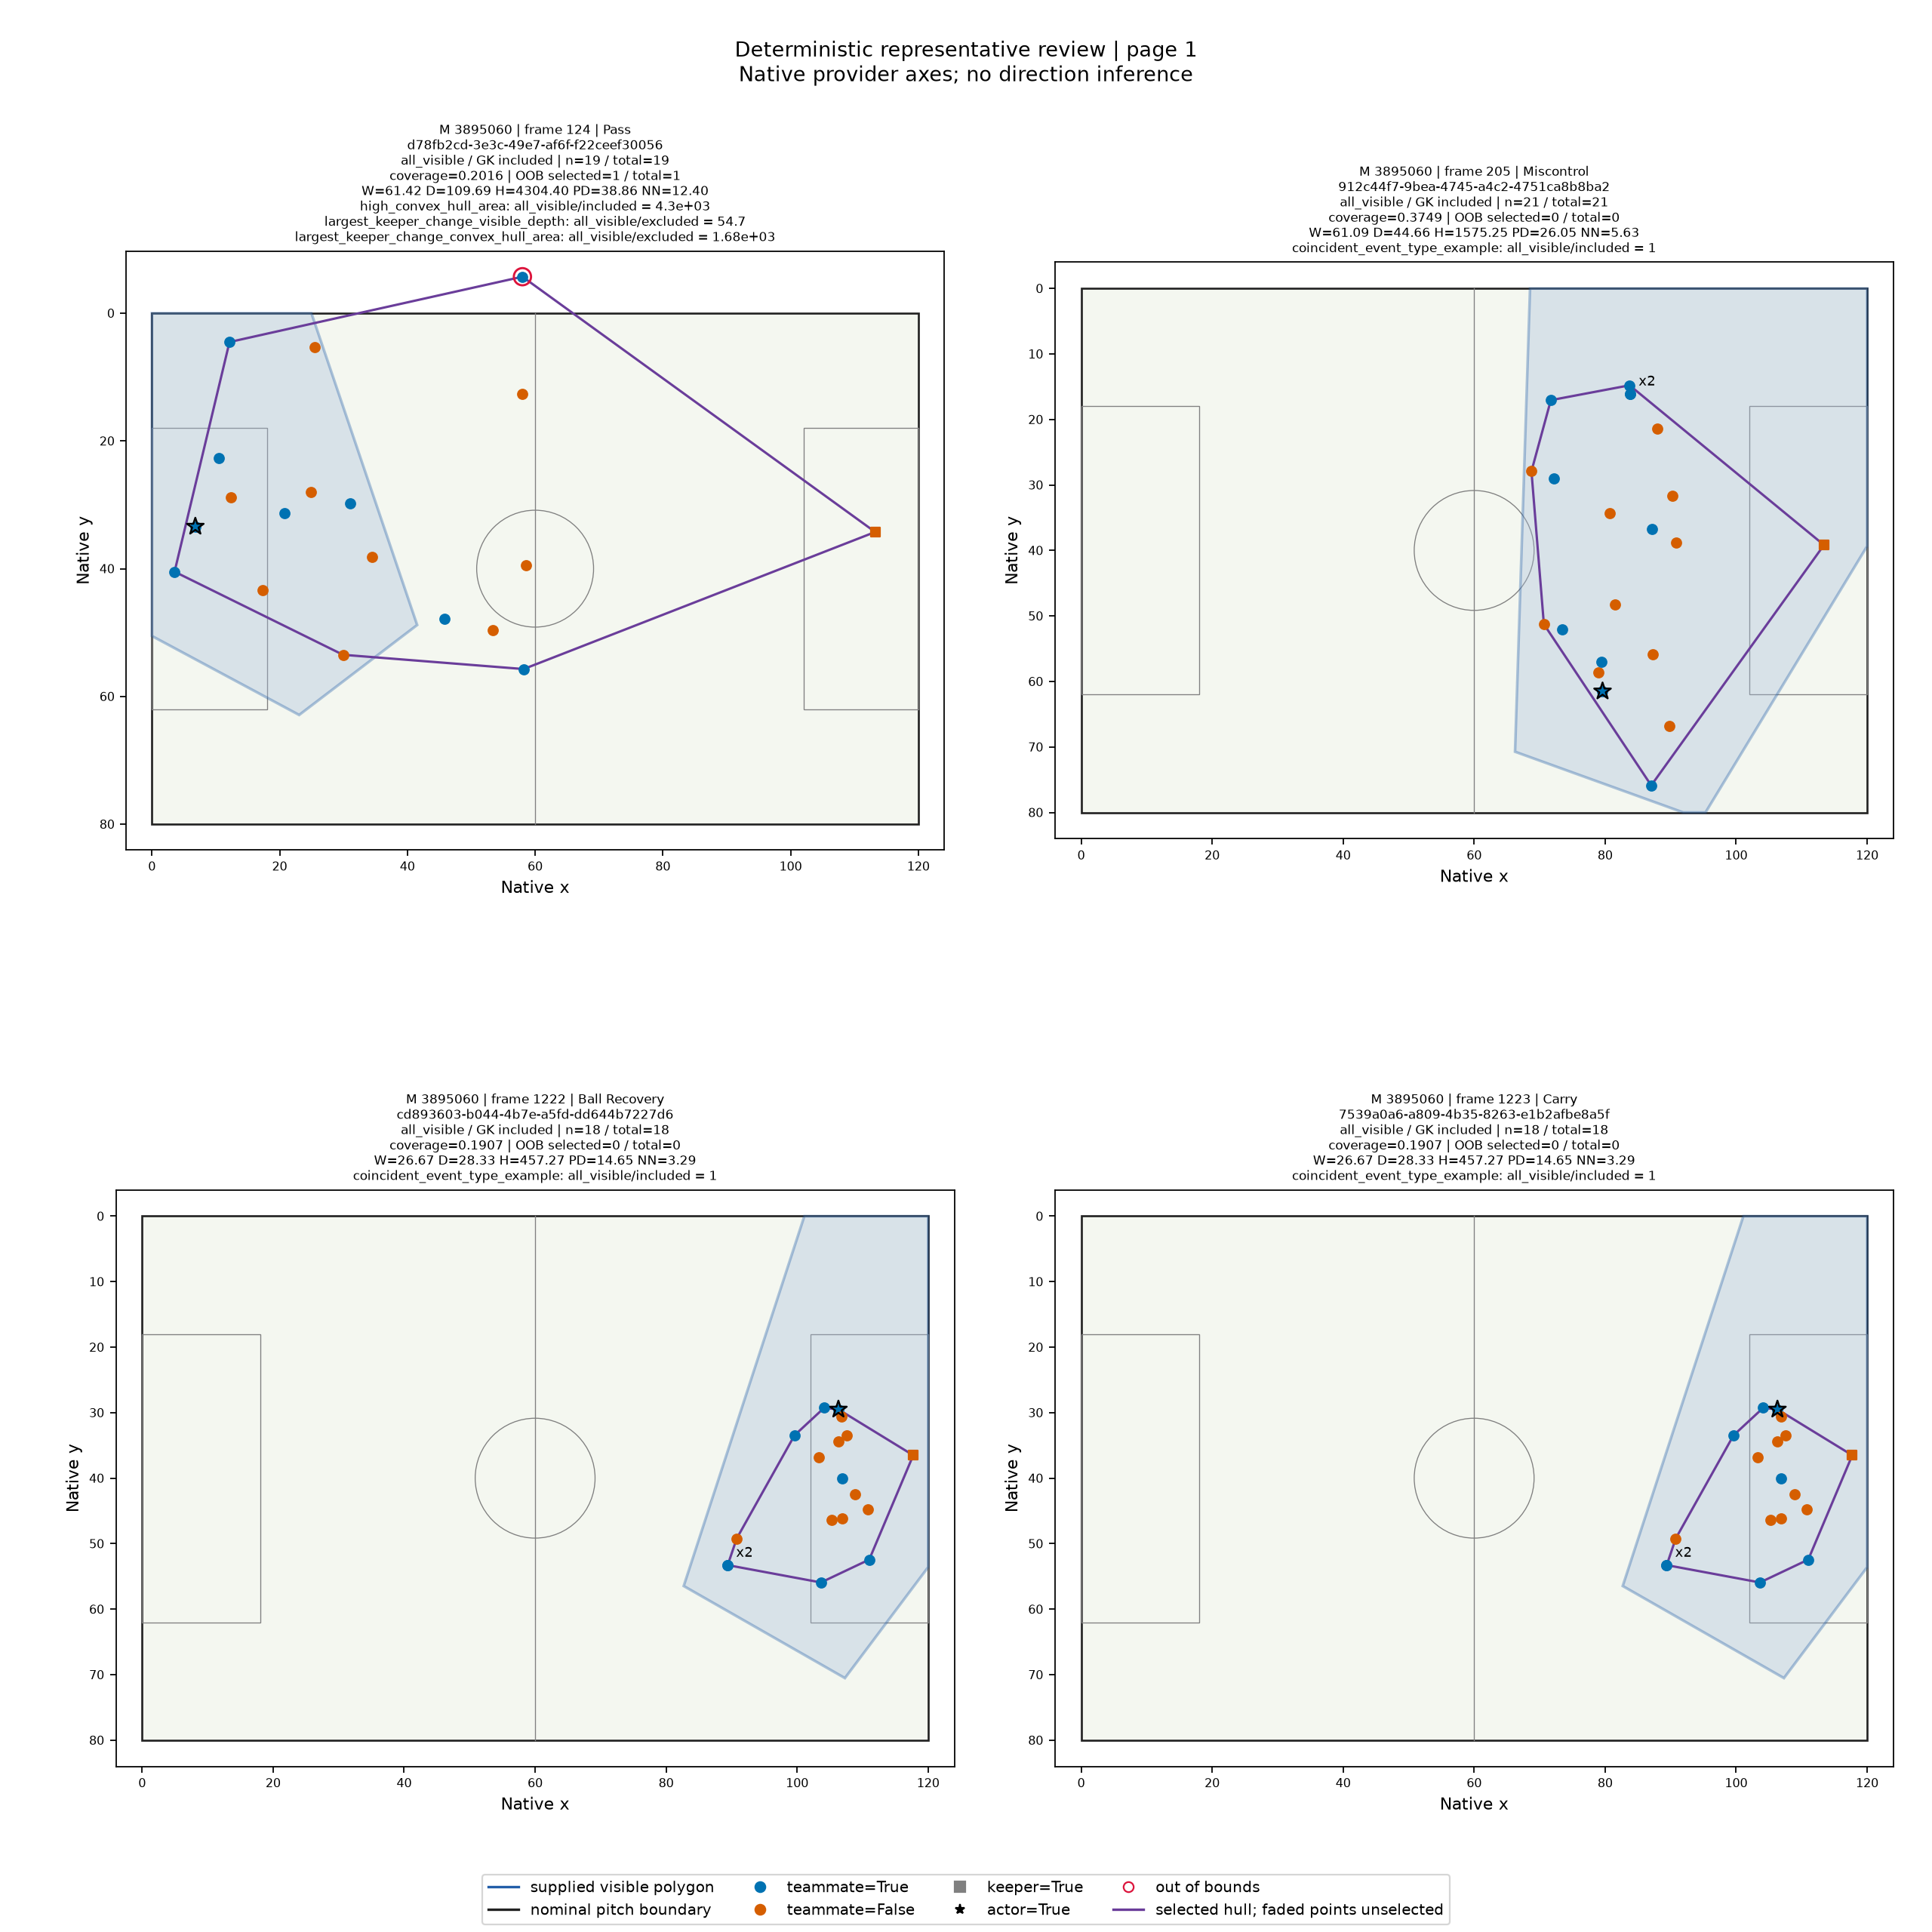

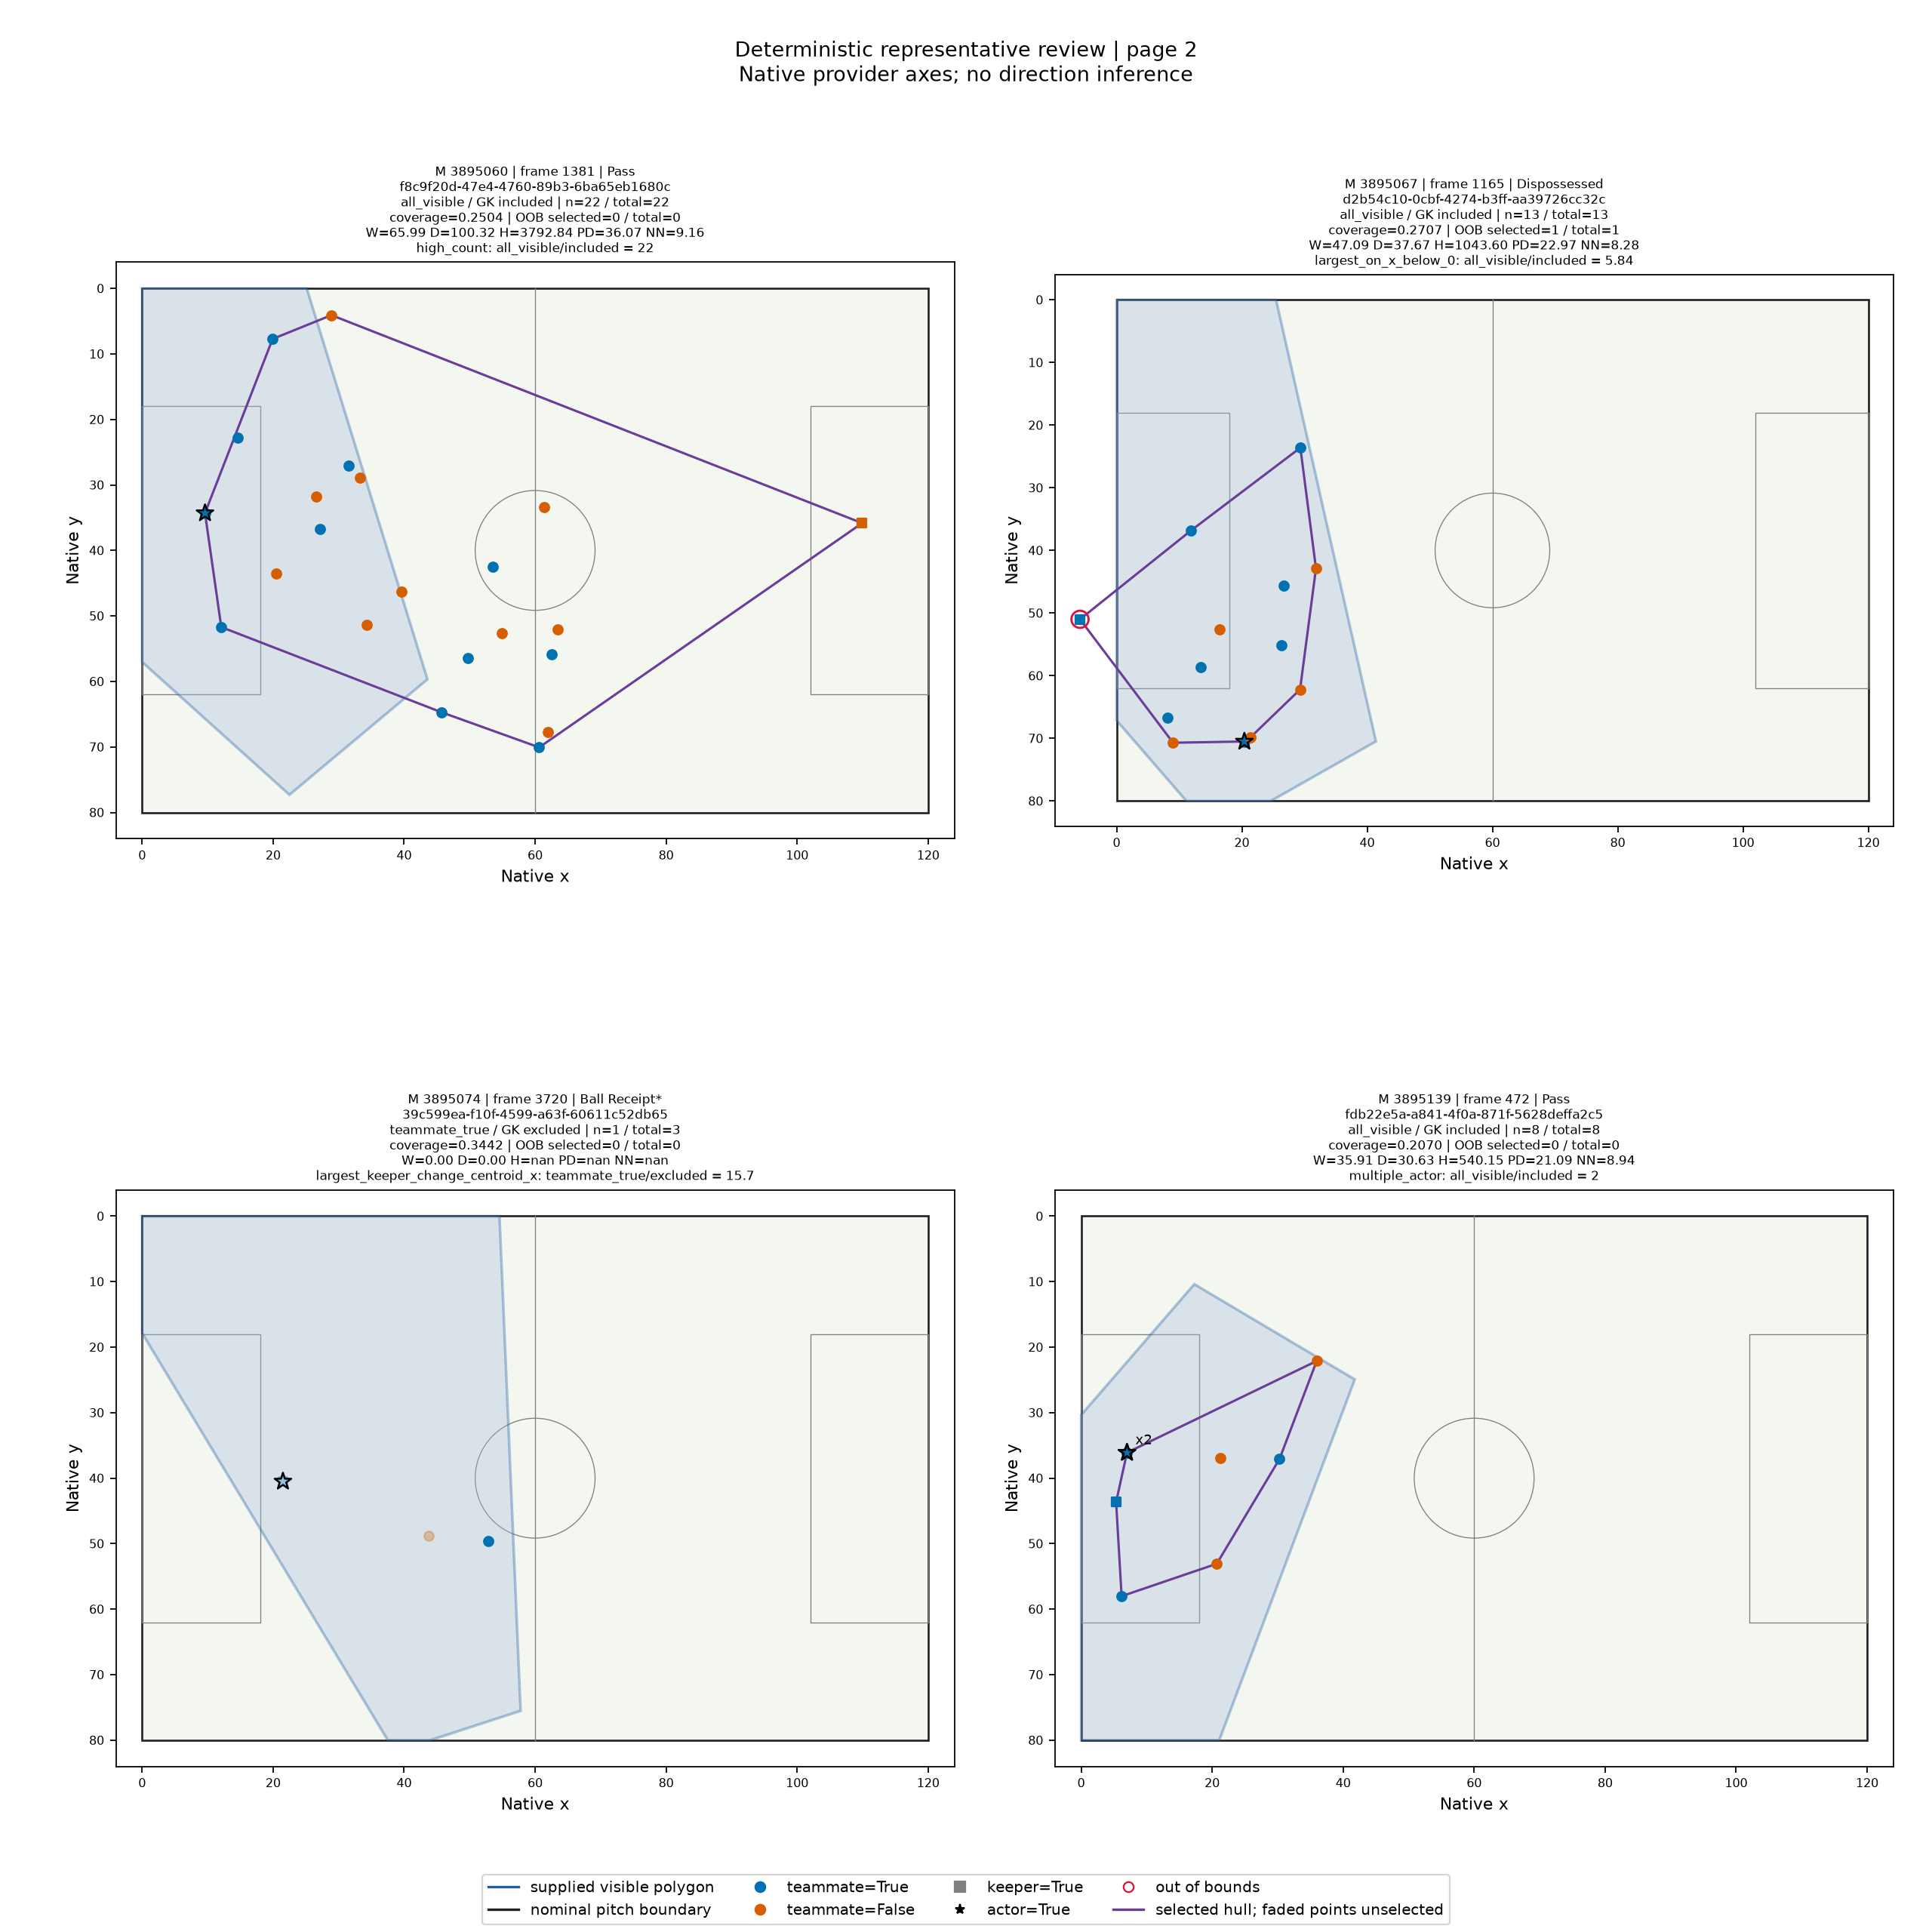

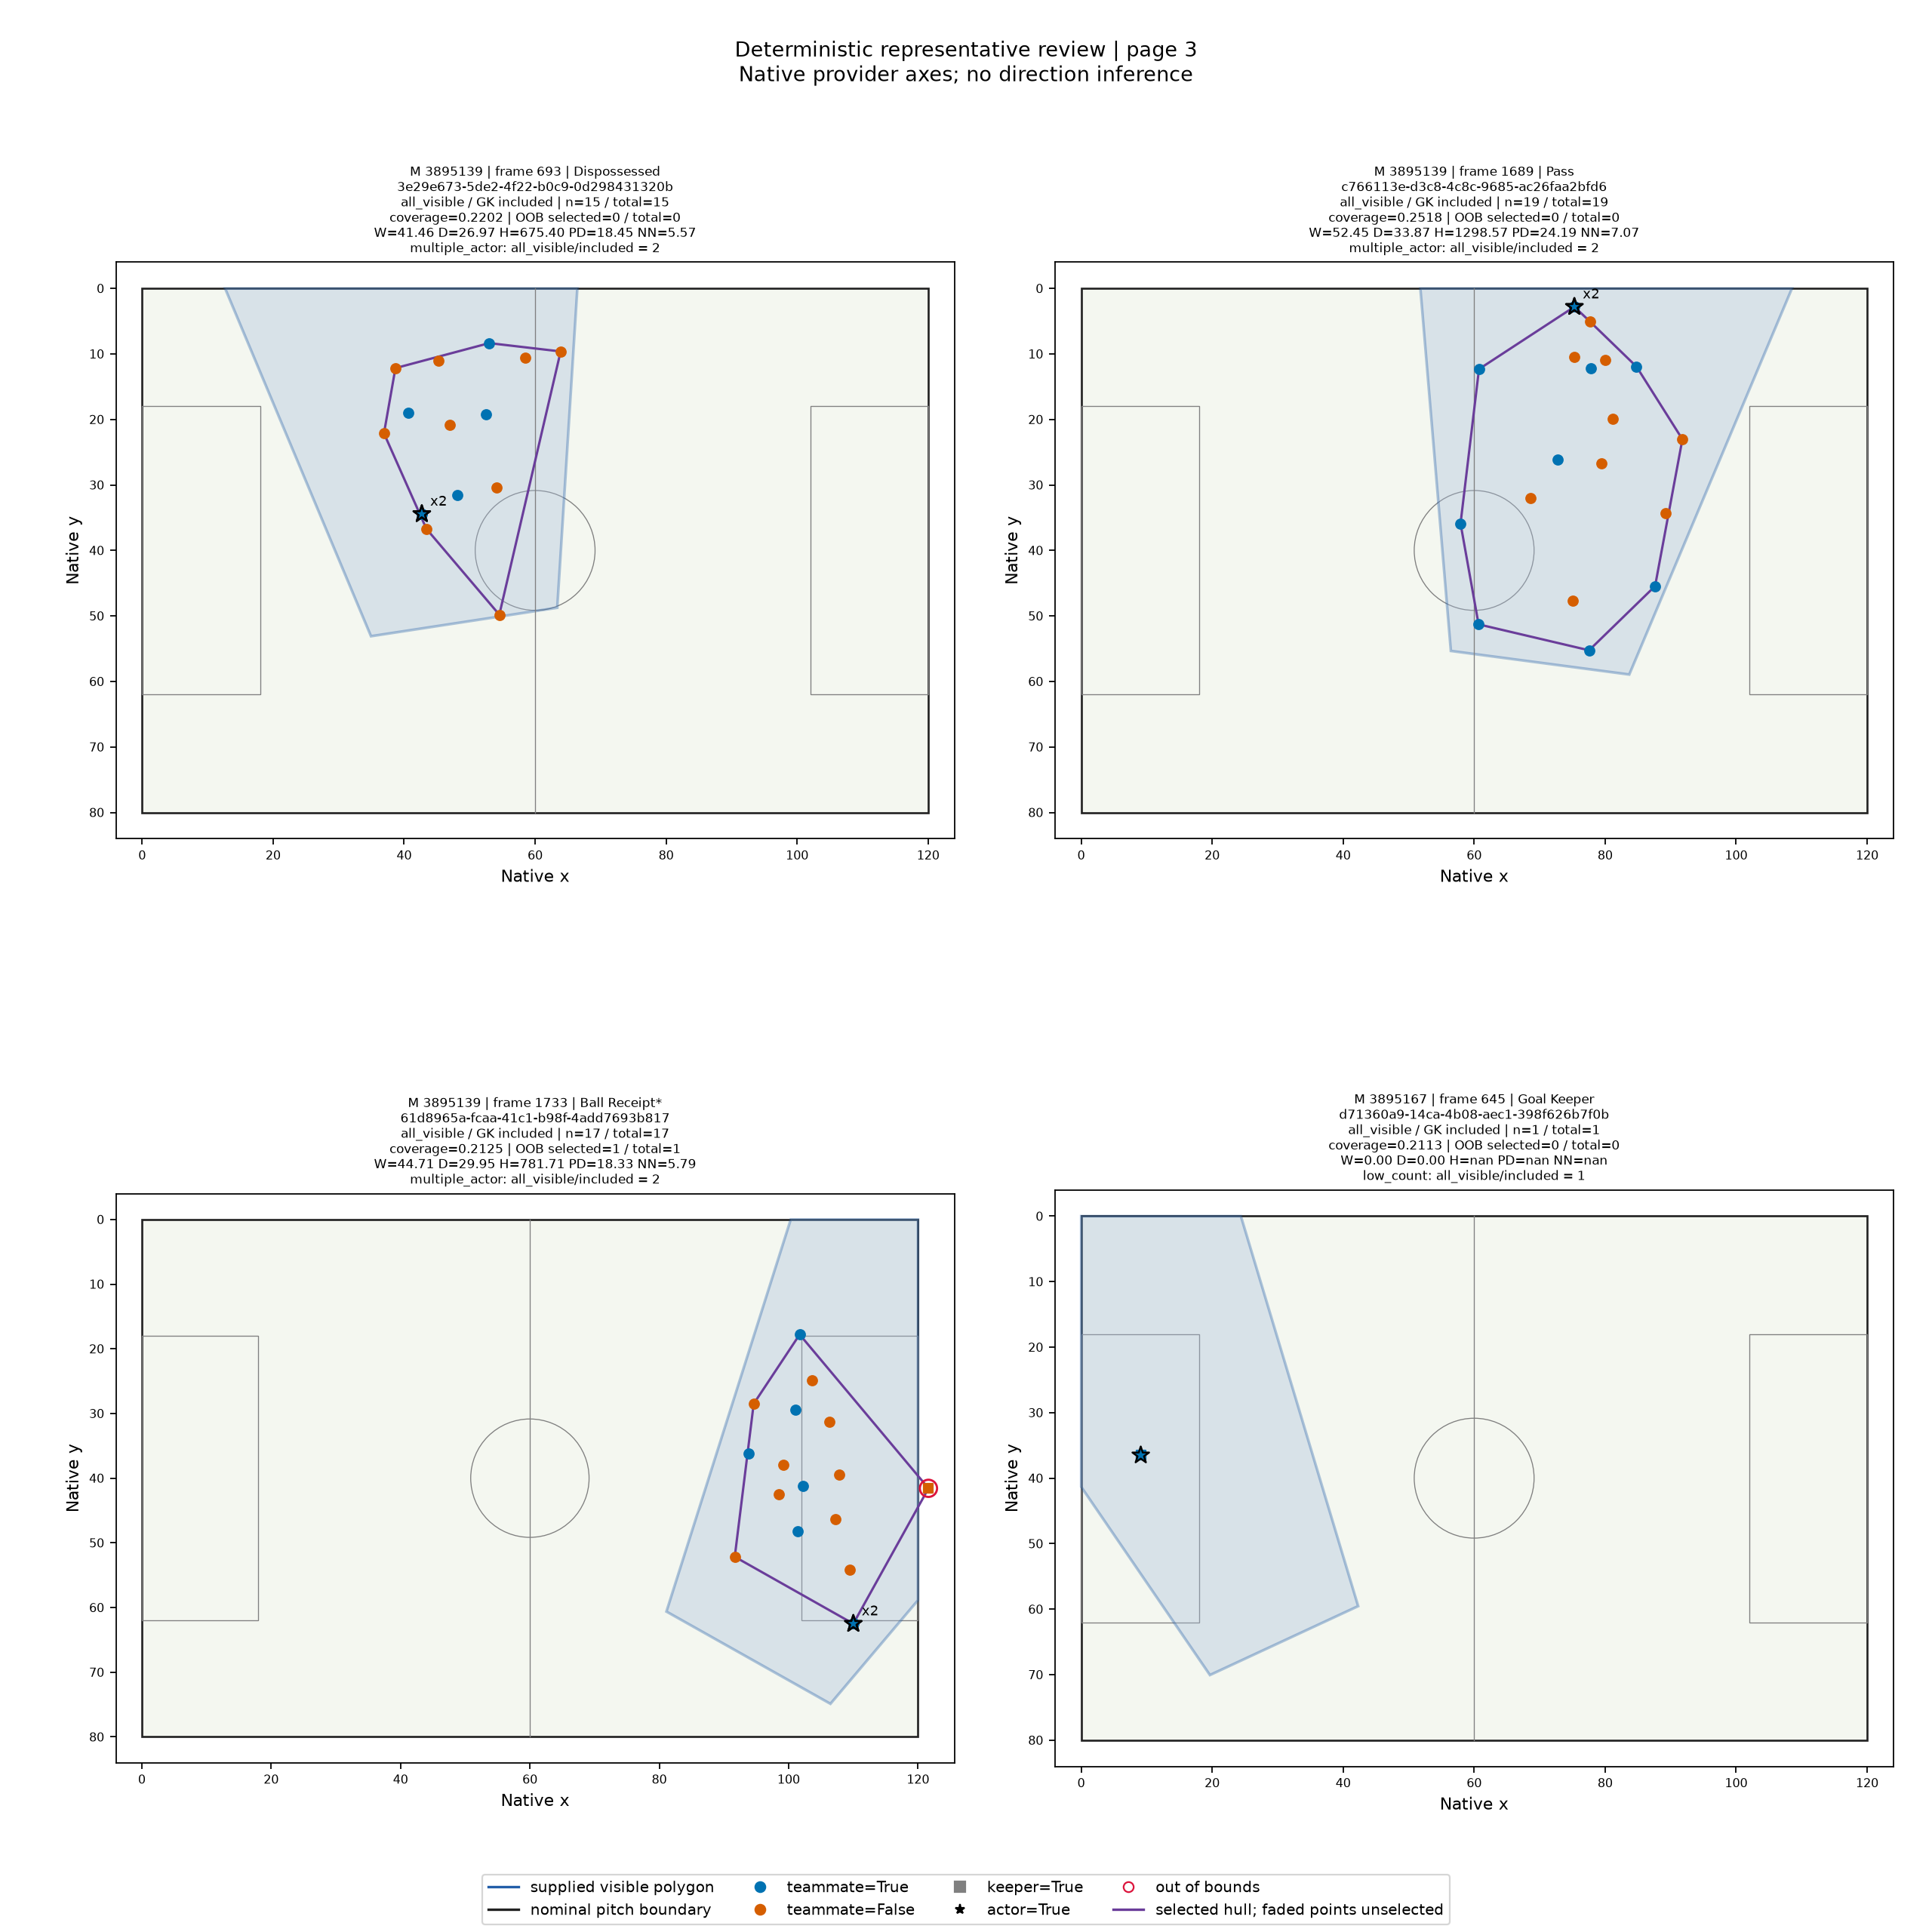

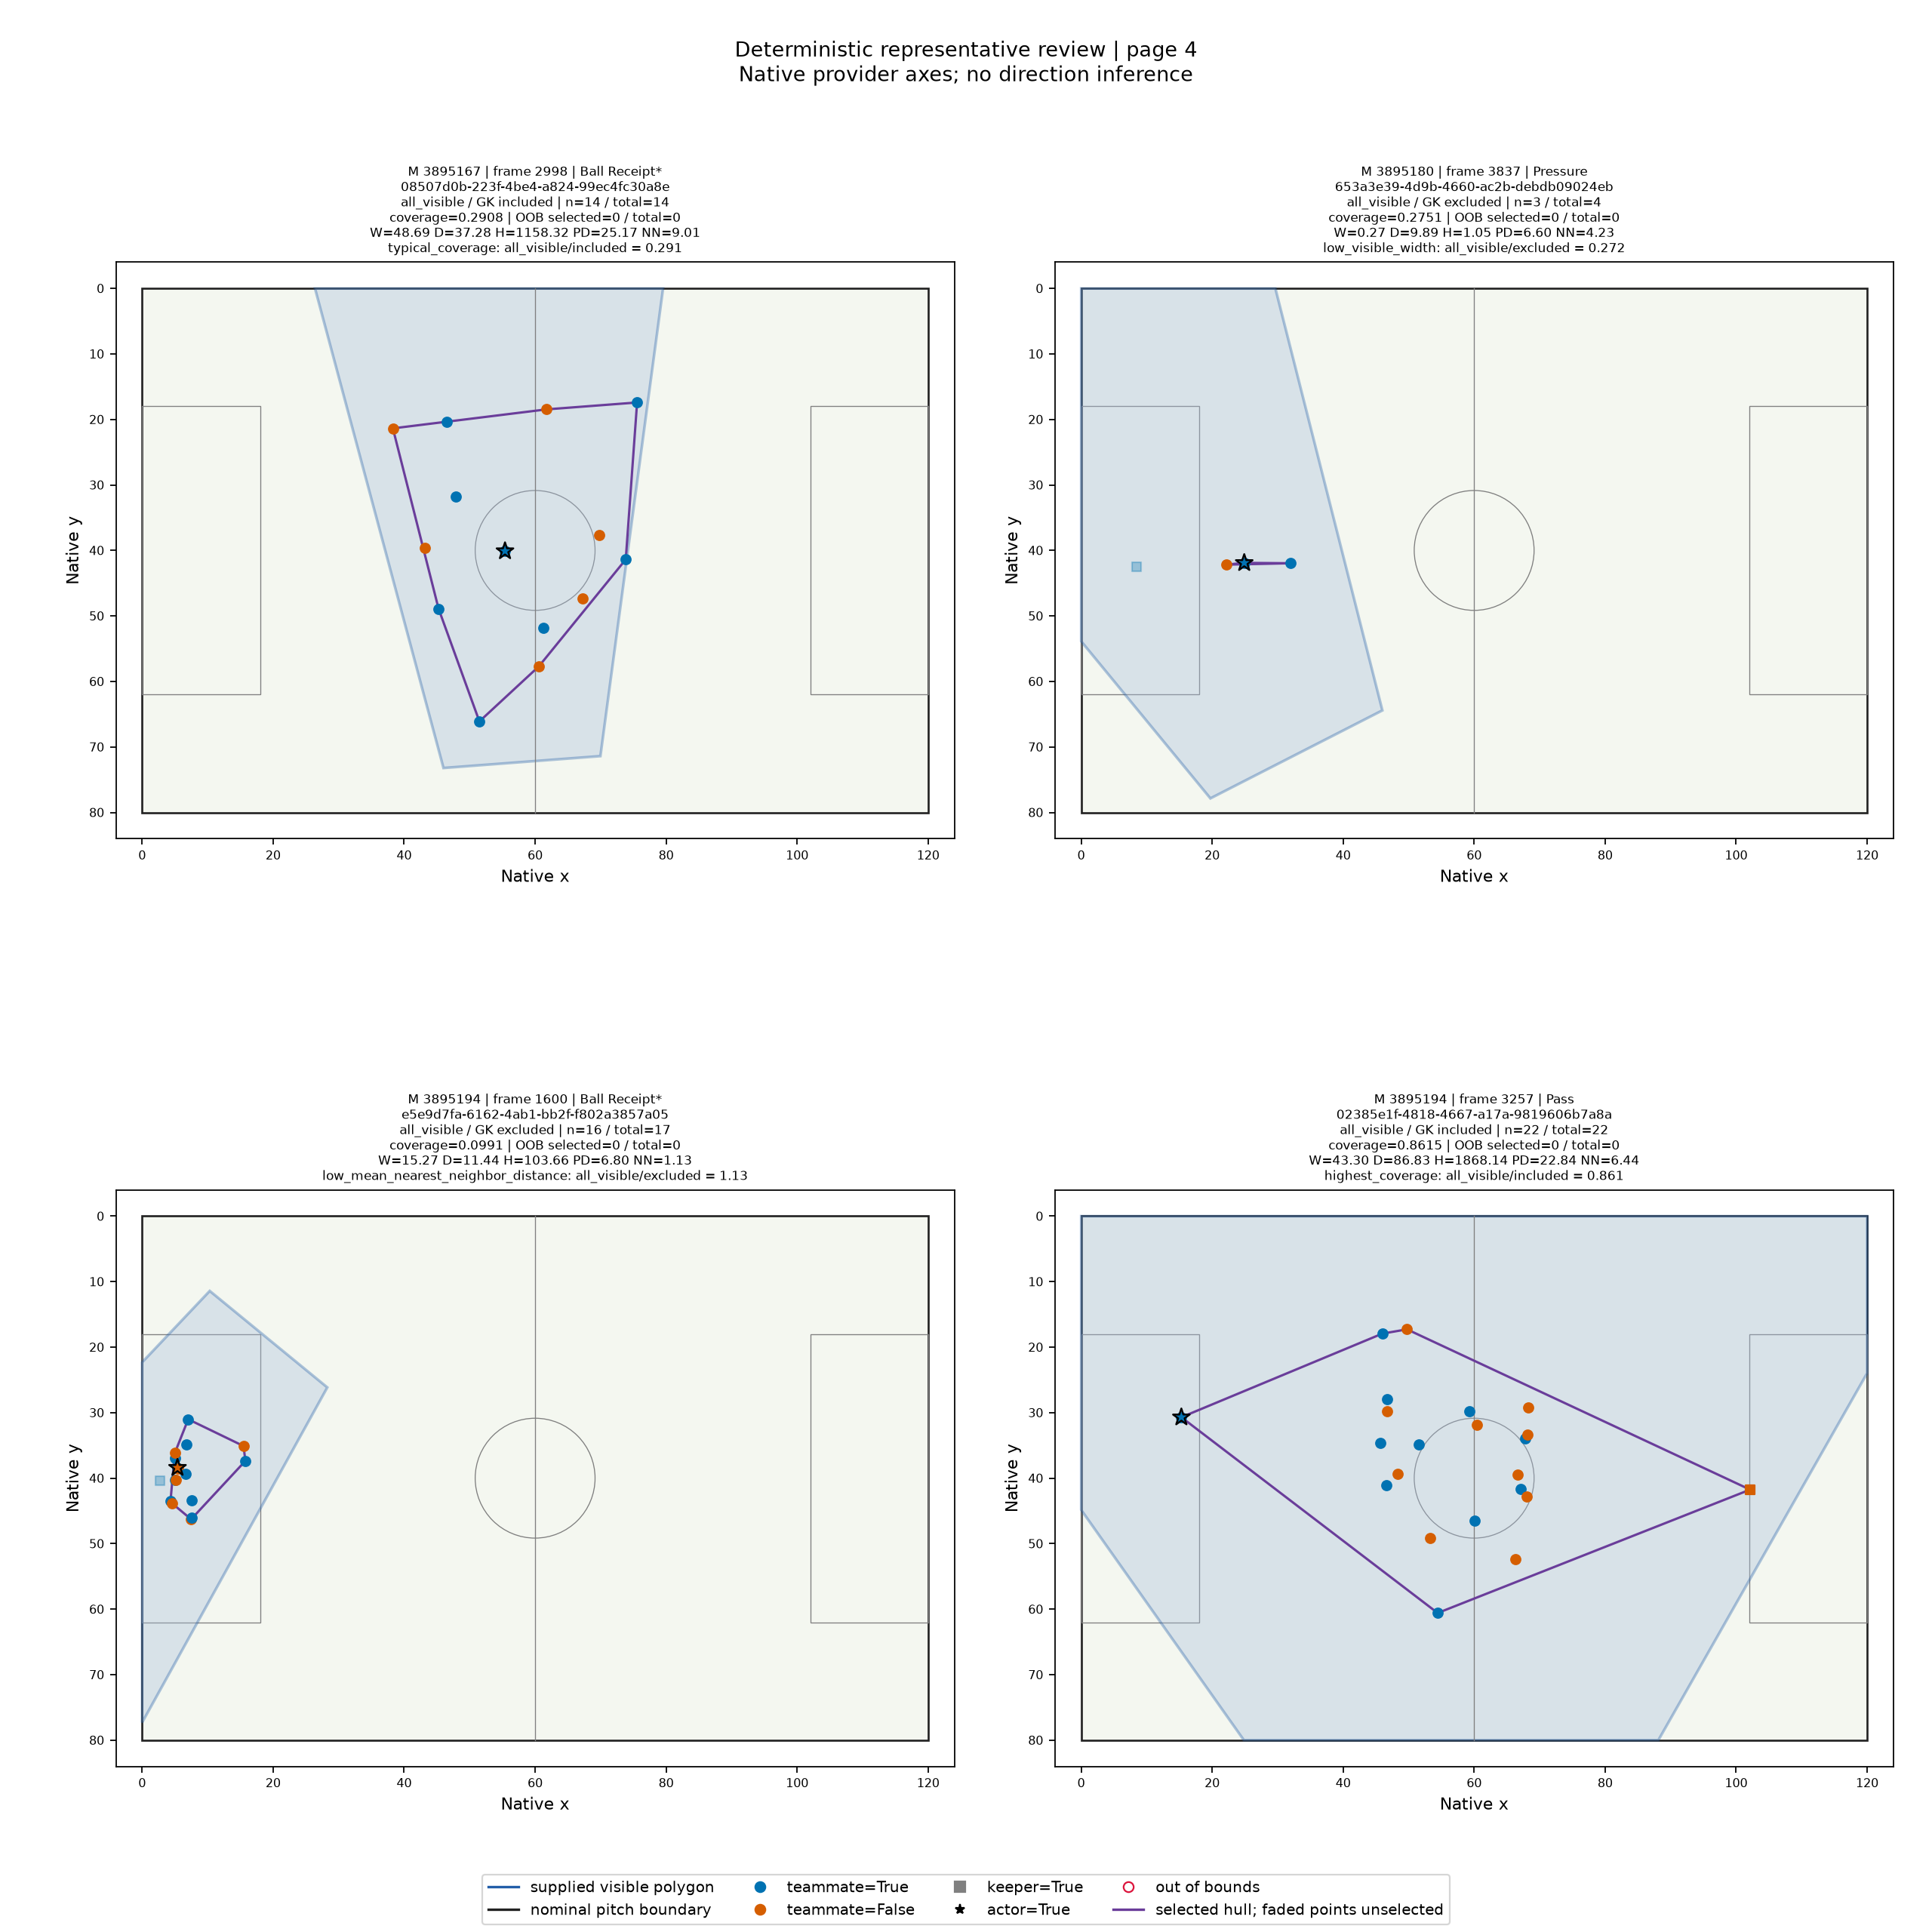

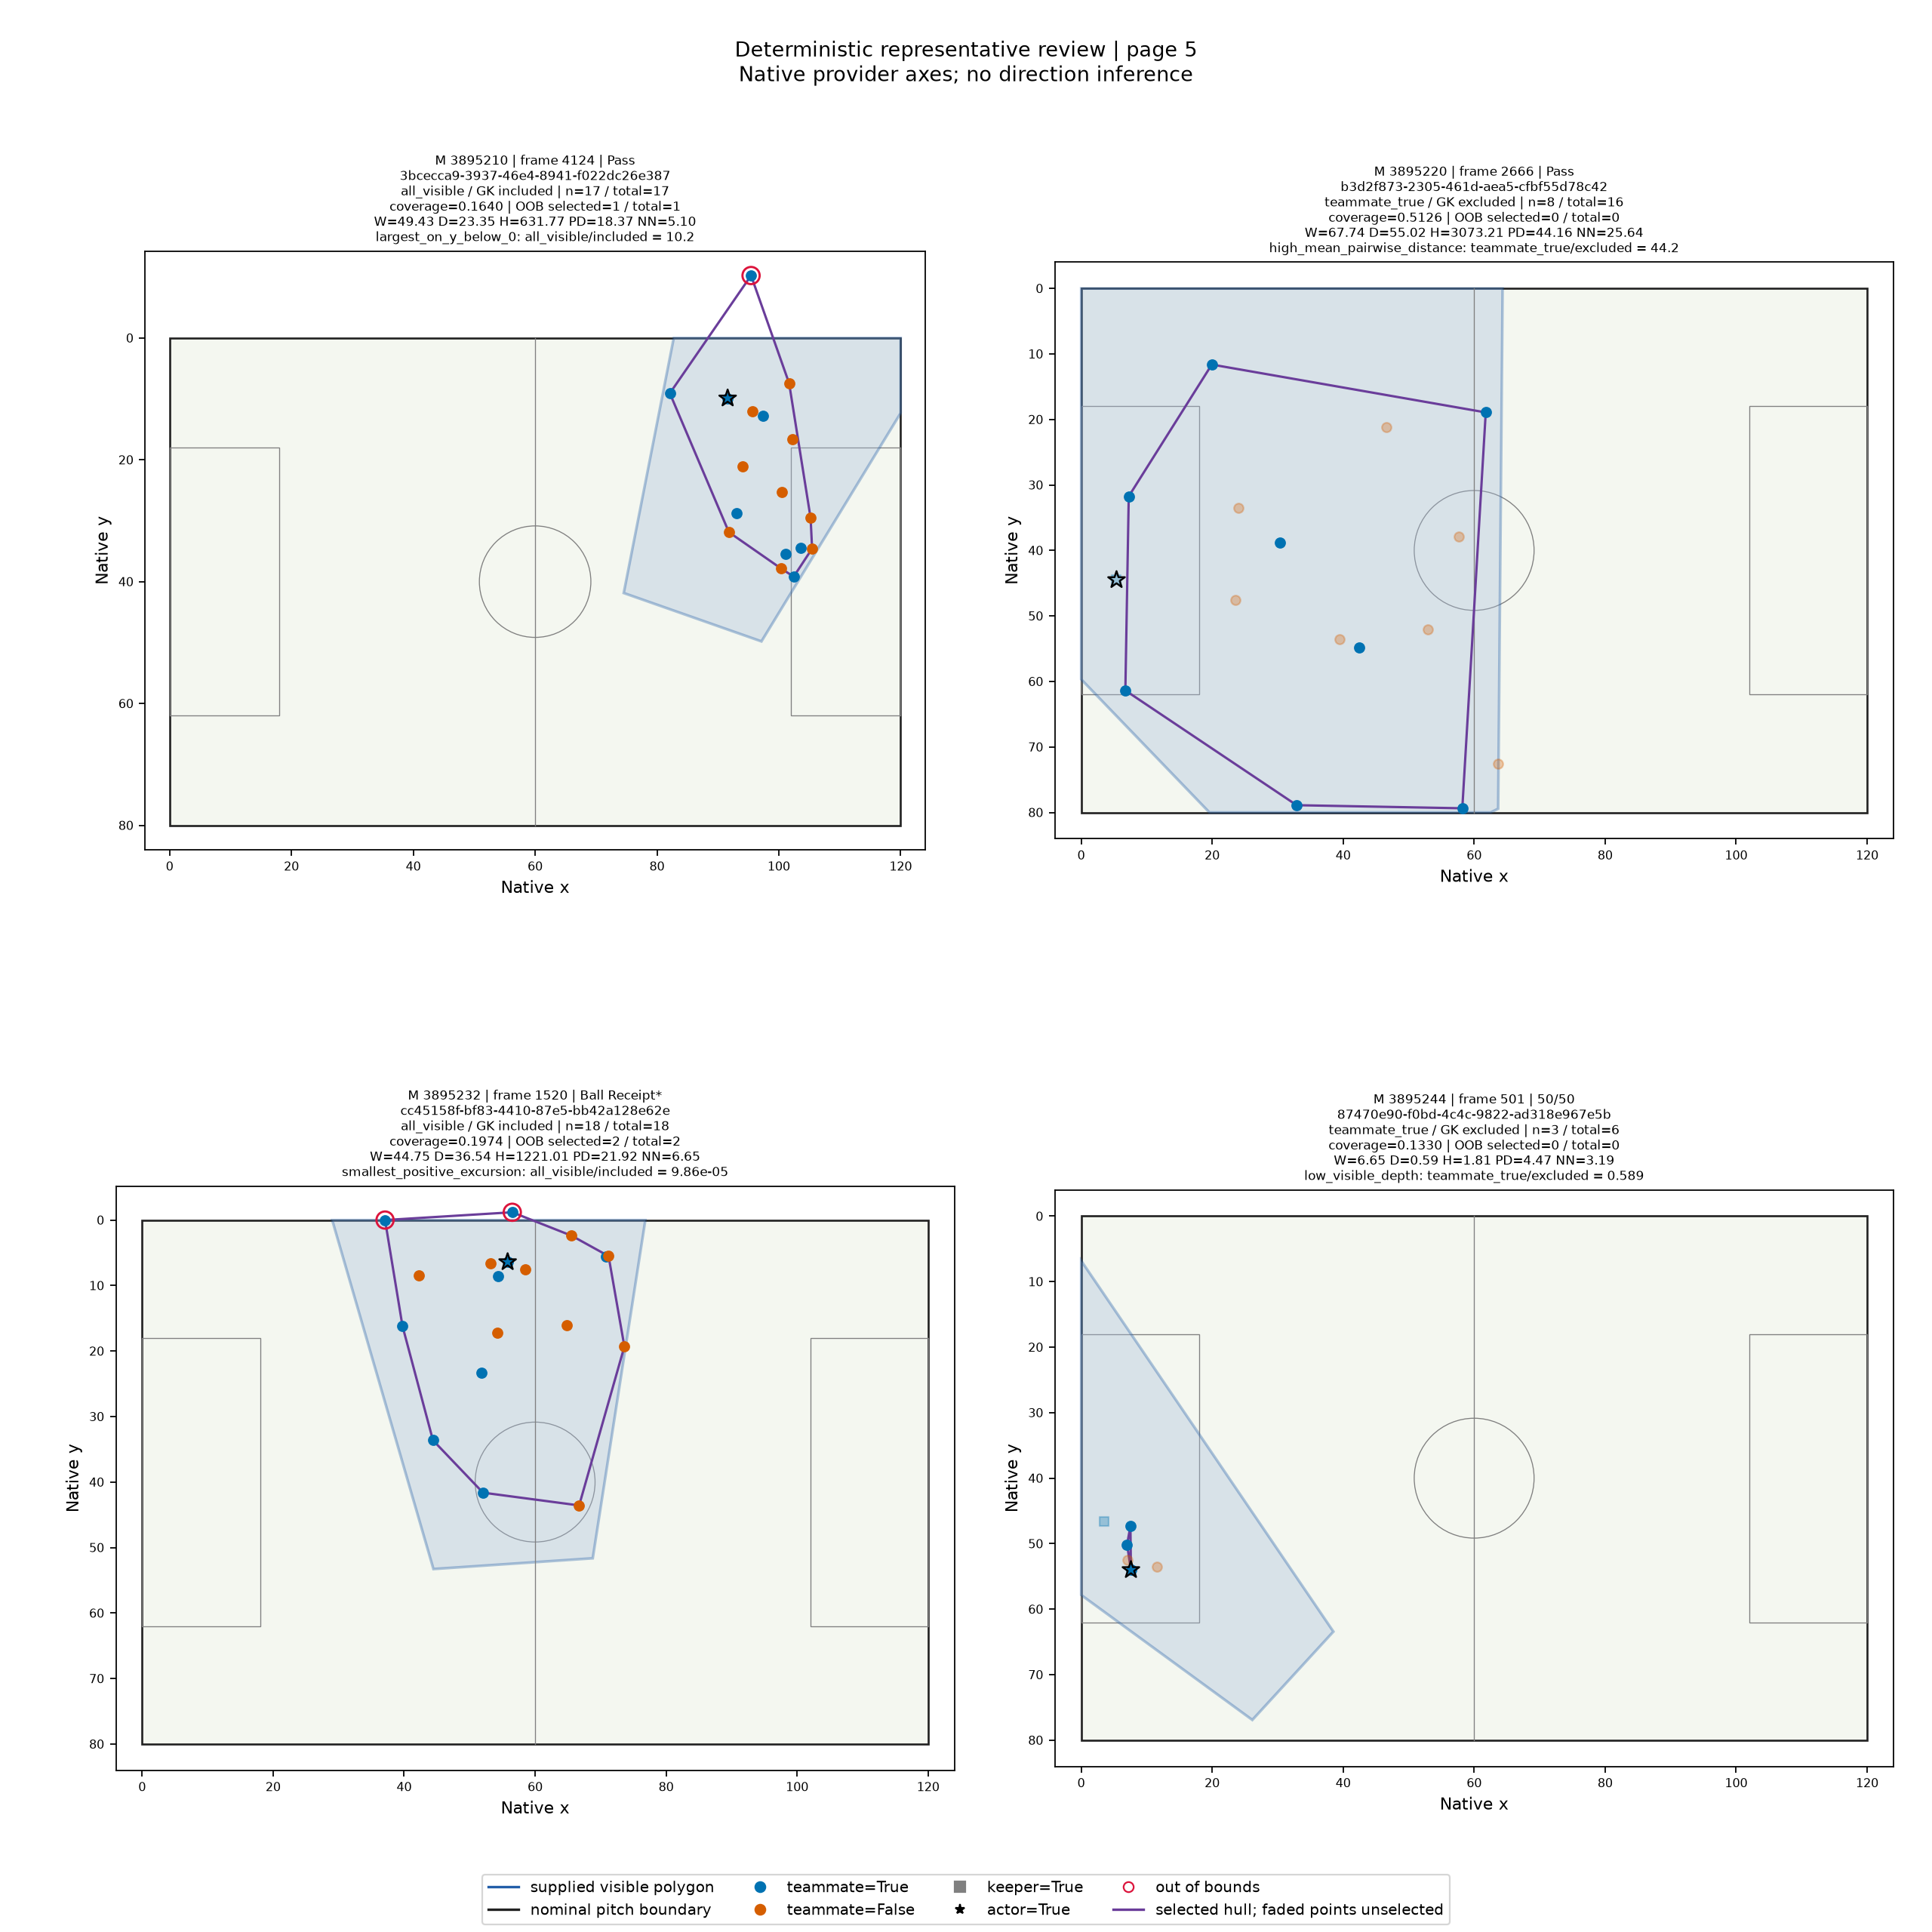

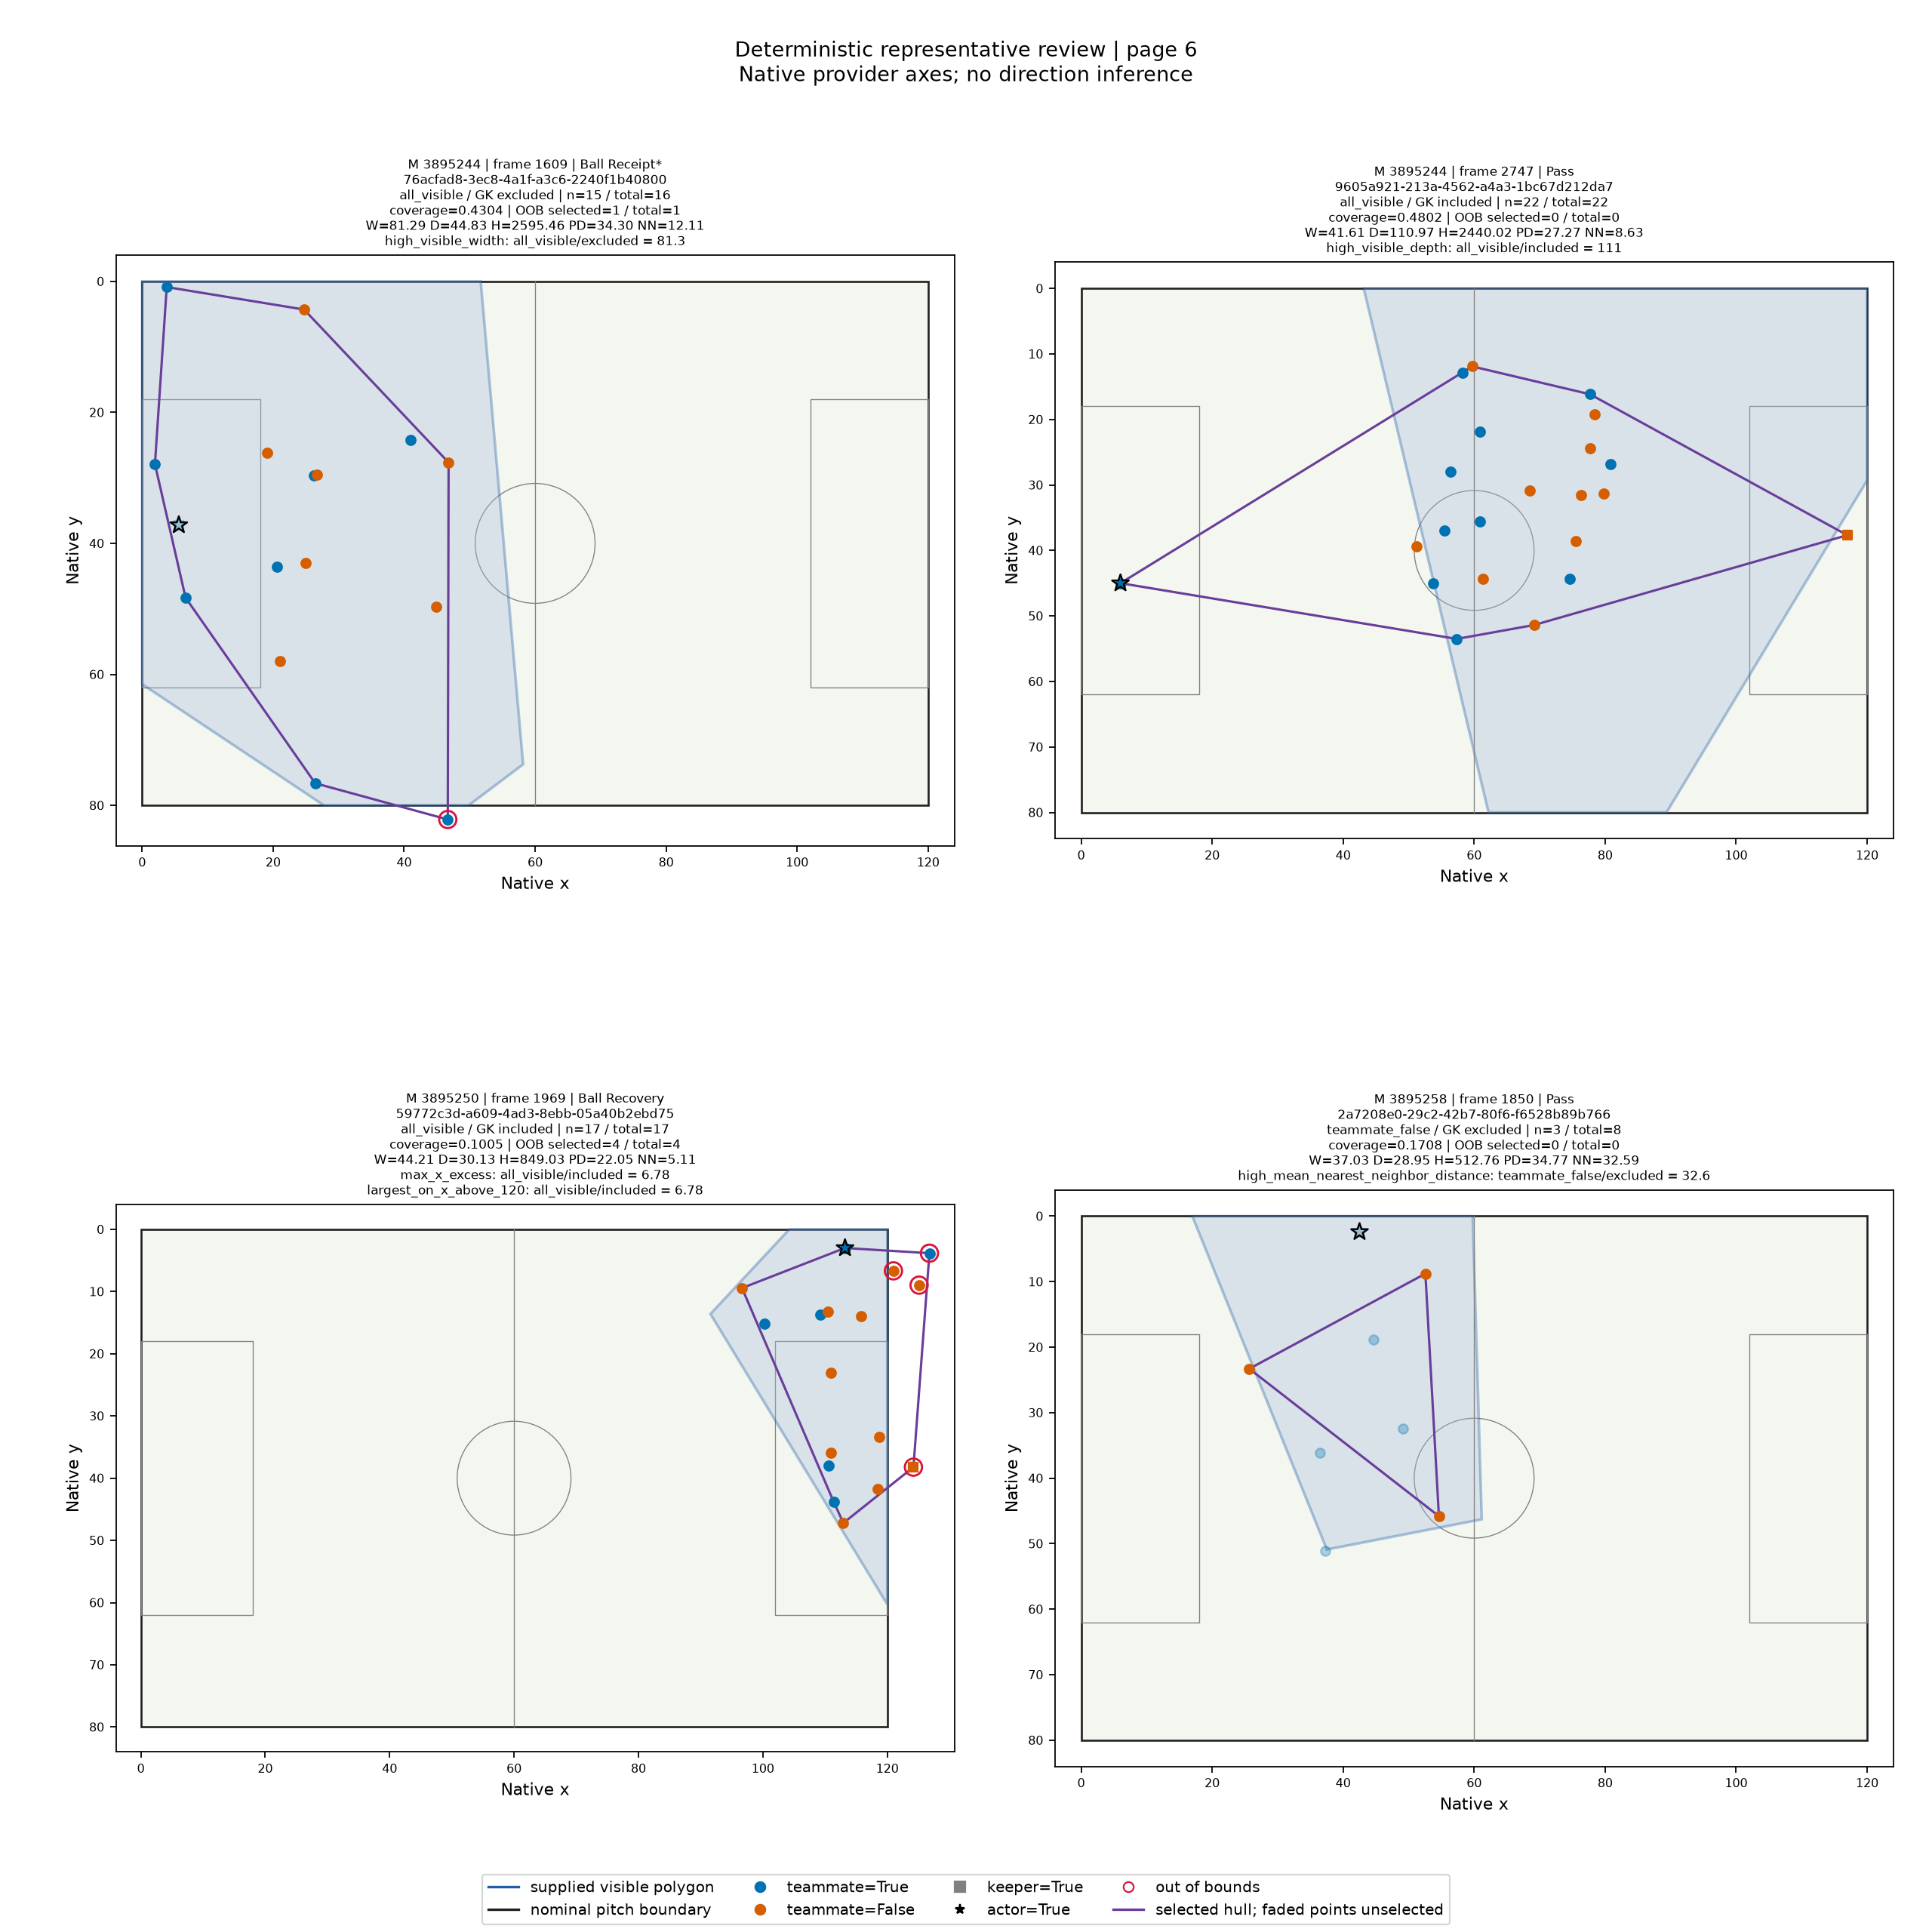

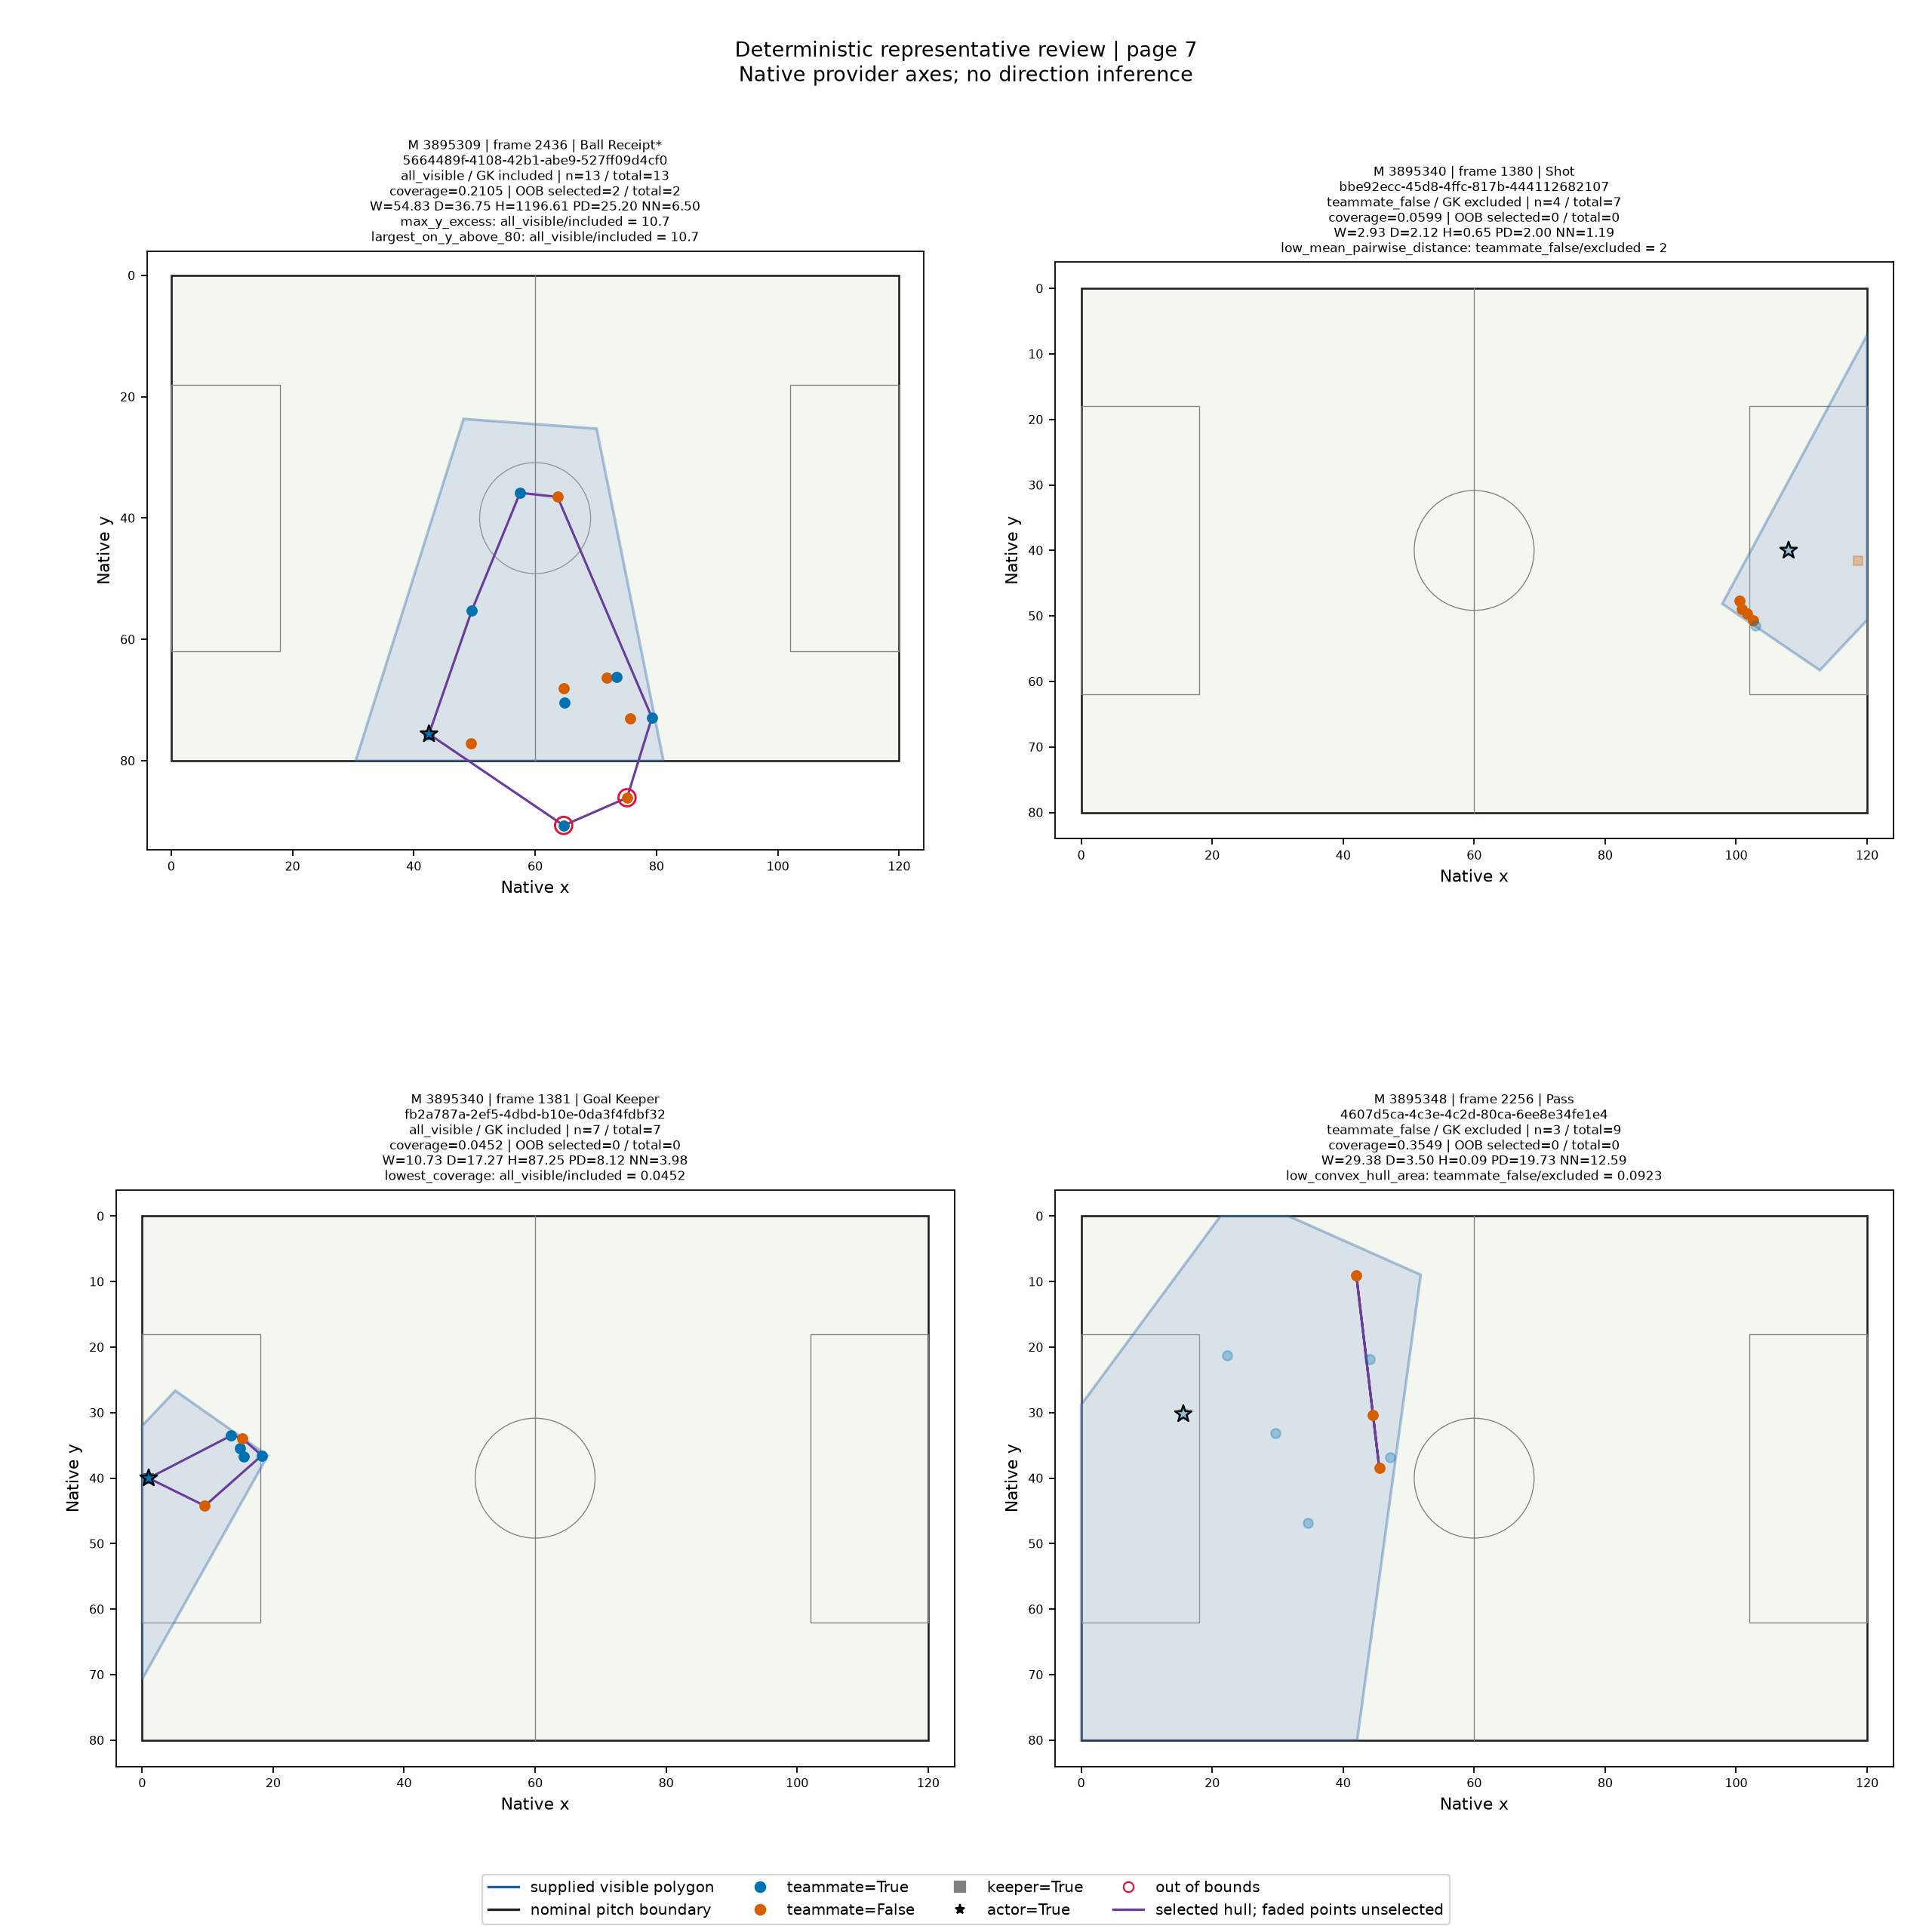

In [16]:
display(quality['representative_frames'])
for image_path in sorted((root / 'outputs/figures').glob('phase2b2_representative_*.png')):
    display(Image(filename=str(image_path)))

## 7. Extreme-value sanity review

The extreme-observation table retains the exact minimum/maximum for every major metric and variant, including mathematical low-count extremes. Tail summaries compare the lower/upper one-percent empirical tails (all ties retained) with all defined observations. Counts, coverage, continuous edge distances, out-of-bounds points, selected points outside the polygon, keeper presence, coincident records and multiple actors provide observation context.

Low geometry may describe a sparse visible subset; high geometry may incorporate retained out-of-bounds points. These tables do not assign "censored," tactical or causal labels.

In [17]:
display(quality['extreme_geometry_review'])
display(quality['extreme_tail_summary'])

,match_id,frame_index,event_id,event_id_raw_type,invalid_event_id_scalar,event_type,event_join_status,statsbomb_revision,total_visible_players,n_non_dictionary_records,n_invalid_locations,n_unknown_teammate,actor_count,n_unknown_actor_flags,actor_status,freeze_frame_status,visible_area_status,visible_area_exists,visible_area_missing,visible_area_coordinate_count,visible_area_vertex_count,visible_area_malformed,visible_area_valid,visible_area_reason,visible_area_polygon_area,visible_area_on_pitch_area,visible_area_fraction,visible_area_outside_pitch,selected_subset,goalkeeper_policy,n_valid_points_used,n_unique_points,n_coincident_records,n_out_of_bounds_points,n_keeper_true_before_filter,n_keeper_unknown_before_filter,n_keeper_true_excluded,n_keeper_unknown_excluded,measurement_flags,visible_player_count,...,centroid_x_status,centroid_y_status,visible_width_status,visible_depth_status,convex_hull_area_status,mean_pairwise_distance_status,median_pairwise_distance_status,mean_nearest_neighbor_distance_status,hull_error_category,abs_keeper_delta_visible_depth,abs_keeper_delta_convex_hull_area,abs_keeper_delta_centroid_x,min_x_edge_distance,max_x_edge_distance,min_y_edge_distance,max_y_edge_distance,minimum_selected_edge_distance,median_selected_edge_distance,edge_status,selected_outside_polygon_count,min_x_tied_records,max_x_tied_records,min_y_tied_records,max_y_tied_records,contained_in_pitch,intersects_pitch_boundary,extends_outside_pitch,area_inside_pitch,area_outside_pitch,fraction_outside_pitch,max_x_excess,max_y_excess,max_pitch_distance,min_positive_pitch_distance,count_x_below_0,count_x_above_120,count_y_below_0,count_y_above_80,review_metric,tail
0,3895074,3625,7da65810-4546-4630-a6d9-6c952e0077f3,str,NaN,Ball Recovery,unique,533862946a73608c134d18b78226b6371ce7173c,2,0,0,0,1,0,single,available,valid,True,False,10,5,False,True,valid,2748.756413,2748.756413,0.286329,False,all_visible,excluded,1,1,0,0,1,0,1,0,NaN,1,...,ok,ok,ok,ok,insufficient_points,insufficient_points,insufficient_points,insufficient_points,NaN,25.052922,NaN,12.526461,1.417095,1.417095,1.417095,1.417095,1.417095,1.417095,ok,0.0,1.0,1.0,1.0,1.0,True,True,False,2748.756413,0.0,0.0,0.000000,0.000000,0.000000,NaN,0,0,0,0,visible_width,minimum
1,3895244,1609,76acfad8-3ec8-4a1f-a3c6-2240f1b40800,str,NaN,Ball Receipt*,unique,533862946a73608c134d18b78226b6371ce7173c,16,0,0,0,1,0,single,available,valid,True,False,14,7,False,True,valid,4131.869068,4131.869068,0.430403,False,all_visible,excluded,15,15,0,1,1,0,1,0,out_of_bounds_points,15,...,ok,ok,ok,ok,ok,ok,ok,ok,NaN,0.000000,0.000000,1.239819,1.957036,7.303327,0.864659,2.151145,0.864659,11.112354,ok,1.0,1.0,1.0,1.0,1.0,True,True,False,4131.869068,0.0,0.0,0.000000,2.151145,2.151145,2.151145,0,0,0,1,visible_width,maximum
2,3895074,3625,7da65810-4546-4630-a6d9-6c952e0077f3,str,NaN,Ball Recovery,unique,533862946a73608c134d18b78226b6371ce7173c,2,0,0,0,1,0,single,available,valid,True,False,10,5,False,True,valid,2748.756413,2748.756413,0.286329,False,all_visible,excluded,1,1,0,0,1,0,1,0,NaN,1,...,ok,ok,ok,ok,insufficient_points,insufficient_points,insufficient_points,insufficient_points,NaN,25.052922,NaN,12.526461,1.417095,1.417095,1.417095,1.417095,1.417095,1.417095,ok,0.0,1.0,1.0,1.0,1.0,True,True,False,2748.756413,0.0,0.0,0.000000,0.000000,0.000000,NaN,0,0,0,0,visible_depth,minimum
3,3895302,201,c3c896a5-a5cd-4820-b5ad-ffaa30be7b93,str,NaN,Pressure,unique,533862946a73608c134d18b78226b6371ce7173c,20,0,0,0,1,0,single,available,valid,True,False,12,6,False,True,valid,2700.562441,2700.562441,0.281309,False,all_visible,excluded,19,19,0,0,1,0,1,0,NaN,19,...,ok,ok,ok,ok,ok,ok,ok,ok,NaN,7.399070,269.245243,1.689922,6.581902,43.788137,37.451217,32.292818,3.586690,18.225531,ok,18.0,1.0,1.0,1.0,1.0,True,True,False,2700.562441,0.0,0.0,0.000000,0.000000,0.000000,NaN,0,0,0,0,visible_depth,maximum
4,3895180,3837,653a3e39-4d9b-4660-ac2b-debdb09024eb,str,NaN,Pressure,unique,533862946a73608c134d18b78226b6371ce7173c,4,0,0,0,1,0,single,a

,selected_subset,goalkeeper_policy,metric,tail,empirical_cutoff,rows,metric_median,n_valid_points_used_median,visible_area_fraction_median,min_x_edge_distance_median,max_x_edge_distance_median,min_y_edge_distance_median,max_y_edge_distance_median,minimum_selected_edge_distance_median,median_selected_edge_distance_median,n_min,n_max,coverage_p25,coverage_p75,out_of_bounds_fraction,coincident_fraction,multiple_actor_fraction,keeper_present_fraction,selected_outside_polygon_fraction,statsbomb_revision
0,all_visible,excluded,visible_width,lower_1_percent,20.769154,1186,17.806286,11.0,0.176637,5.692364,4.933322,7.807741,7.999921,2.616029,8.827596,1,20,0.136980,0.219434,0.029511,0.000000,0.000000,0.000000,0.048904,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,excluded,visible_width,upper_1_percent,70.744609,1186,72.258014,19.0,0.409989,7.925546,4.763652,2.589522,2.527280,0.845776,11.256252,8,21,0.363608,0.453401,0.296796,0.000843,0.000000,0.000000,0.415683,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,excluded,visible_width,all_defined,NaN,118580,47.523559,17.0,0.290812,5.431185,4.859845,5.589597,5.768316,1.139215,10.671858,1,21,0.229428,0.364877,0.086465,0.000413,0.000034,0.000000,0.162624,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,excluded,visible_depth,lower_1_percent,12.888478,1186,10.910497,11.0,0.176886,8.875147,8.984521,7.206301,7.670309,4.118210,9.913533,1,20,0.145824,0.217999,0.017707,0.000000,0.000000,0.000000,0.027825,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,excluded,visible_depth,upper_1_percent,45.458705,1187,47.663779,19.0,0.436410,6.006361,3.472058,6.382360,7.021433,0.869979,11.693444,9,21,0.363847,0.508211,0.100253,0.001685,0.000000,0.000000,0.288964,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,teammate_true,included,mean_pairwise_distance,upper_1_percent,34.338292,1186,35.415137,9.0,0.405996,6.438438,3.089274,3.206716,3.532835,0.870893,8.016558,2,11,0.349946,0.467097,0.202361,0.000000,0.000000,0.583474,0.333052,533862946a73608c134d18b78226b6371ce7173c
86,teammate_true,included,mean_pairwise_distance,all_defined,NaN,118531,23.671214,8.0,0.290830,4.910751,6.756757,6.437520,6.566682,1.857310,9.729498,2,11,0.229483,0.364887,0.076782,0.000245,0.000034,0.194185,0.125334,533862946a73608c134d18b78226b6371ce7173c
87,teammate_true,included,mean_nearest_neighbor_distance,lower_1_percent,4.459509,1187,3.796980,10.0,0.164250,2.709657,9.277979,8.158449,8.063587,2.290725,7.867737,2,11,0.136196,0.198523,0.053075,0.000000,0.000000,0.834035,0.053075,533862946a73608c134d18b78226b6371ce7173c
88,teammate_true,included,mean_nearest_neighbor_distance,upper_1_percent,18.886685,1186,20.074613,5.0,0.309100,6.400000,4.421303,5.002034,5.261691,2.029337,7.573702,2,10,0.256181,0.363398,0.096121,0.000000,0.000000,0.592749,0.172850,533862946a73608c134d18b78226b6371ce7173c


## 8. Empirical conclusions

**EMPIRICAL FINDING:** All 118,581 original frames and 711,486 unchanged variants were reconfirmed. The 13,812 out-of-bounds records affect 11,508 frames across all 34 matches. Pitch-excursion median/p95/maximum are 1.3801/5.0488/10.6629 native units: a mixed magnitude population, not only tiny boundary noise.

All supplied polygons are valid and pitch-contained, with zero outside area; 118,185 touch the pitch boundary. Every out-of-bounds point is outside its supplied polygon. All-visible/included has 20,582 frames with at least one point outside the polygon, including 9,074 frames with no nominal-pitch violation.

Defining-extreme edge-distance p05 values range from 0.2662 to 0.3911 for all-visible/included; minimum selected-player distance has median 1.0164. Width/depth/hull medians are higher in the nearest than the farthest edge-distance quintile under all six variants. These associations do not prove censoring: the polygon edge often includes the pitch boundary, distances are unsigned and n/coverage/keeper composition co-vary.

Upper all-visible width tails contain 29.93% out-of-bounds frames versus 9.70% overall. Upper depth tails have 98.65% keeper presence; upper nearest-neighbor tails instead have median n=10. The 28-frame review shows tiny near-boundary excursions, larger crossings, sparse and nearly collinear subsets, and major point/polygon inconsistencies even with n=22. No single explanation covers all extreme geometry.

Coincidence comprises 52 two-record groups and 52 excess records in 50 frames across five matches. Adding one coincident record in a separate diagnostic leaves width/depth/hull exactly invariant in all 206 variant/location comparisons, while counts, centroids and spacing can change. All four multiple-actor frames contain two coincident, teammate=True, keeper=False actors. Records and identity ambiguity remain unchanged.

**Readiness:** Evidence is sufficient to begin human-reviewed Phase 2B-3 calibration, with point/polygon agreement, metric-specific denominators, keeper sensitivity and unresolved actor semantics explicitly on the review agenda. The detailed measurements and frame-by-frame visual observations are in `report/technical_appendix.md`.

**METHODOLOGICAL DECISION:** No final visibility, count, edge, goalkeeper or eligibility rule is selected. No geometry formula, source revision, calibration YAML or raw coordinate has changed.

# Phase 2B-3 — Calibration Candidates

**PROPOSED — REQUIRES HUMAN APPROVAL.** Twenty candidate definitions were evaluated offline from the unchanged Phase 2A geometry CSV. No geometry, configuration, source revision or permanent eligibility rule changed. Run `python scripts/calibration.py` to regenerate the compact aggregates. All earlier notebook cells remain historical diagnostics.

The main review artifact is `outputs/diagnostics/phase2b3_metric_calibration_matrix.csv`, with a versioned copy in `docs/phase2b3_metric_calibration_matrix.csv`. Full definitions and evidence are in methods section 36 and the Phase 2B-3 technical appendix.

In [2]:
from leverkusen.spatial.calibration import read_calibration
from leverkusen.visualization.calibration import plot_calibration_tradeoffs, plot_threshold_stability

calibration = read_calibration(root / 'outputs/diagnostics')
display(calibration['run_summary'])

,source_file,source_sha256,original_frames,variant_rows,matches,candidate_count,status,permanent_configuration_changed,csv_float_precision,statsbomb_revision
0,phase2a_frame_geometry.csv,a6af9ceb6182c02159de78c8e57ad5ecda635d47e282ee...,118581,711486,34,20,PROPOSED — REQUIRES HUMAN APPROVAL,False,round_trip,533862946a73608c134d18b78226b6371ce7173c


## 1. Candidate strategy definitions

A retains every mathematically defined metric. B tests observed n q05/q25/q50/q75 separately for each subset and keeper variant. C tests the existing coverage q20/q40/q60/q80 boundaries, once per original frame. Comparisons use `>=` and preserve ties. Count thresholds use observed integer higher interpolation; coverage uses linear interpolation. These are distribution landmarks, not validated stability minima.

D primary preserves the registry comparison rule (`actor_status` single/none) without further visibility exclusion. D sensitivity uses hull n q25 plus whole-frame OOB exclusion; NN n q05 plus whole-frame coincidence exclusion; OOB exclusion for width; OOB plus coincidence exclusion for mean pairwise; and coincidence exclusion for count, centroid and median pairwise. Depth retains its primary mask with keeper pairing prioritized. E combines q25/q20 or q50/q40 count/coverage restrictions with OOB, coincidence and actor checks.

OOB-A and OOB-B/C primary retain finite supplied coordinates. OOB-B sensitivity excludes affected whole frames for all metrics; OOB-C prioritizes width/hull/mean pairwise based on prior tail enrichment. Coincidence sensitivity affects only multiplicity-sensitive quantities. A includes ambiguous actors as generic diagnostics; `actor_unique` additionally requires a single actor and unique event join for an actor-dependent candidate. No polygon containment or edge-distance gate is used.

In [3]:
display(calibration['candidate_definitions'].drop(columns='statsbomb_revision'))
display(calibration['empirical_thresholds'].drop(columns='statsbomb_revision'))
display(calibration['resolved_rules'].query("candidate == 'D_sensitivity' and goalkeeper_policy == 'excluded'").drop(columns='statsbomb_revision'))

,candidate,family,role,paired_primary,count_quantile,area_quantile,anomaly_policy,actor_clear,metric_count
0,A,A,permissive baseline,A,NaN,NaN,none,False,False
1,B_q05,B,count comparison,A,5.0,NaN,none,False,False
2,B_q25,B,count comparison,A,25.0,NaN,none,False,False
3,B_q50,B,count comparison,A,50.0,NaN,none,False,False
4,B_q75,B,count comparison,A,75.0,NaN,none,False,False
5,C_q20,C,coverage comparison,A,NaN,20.0,none,False,False
6,C_q40,C,coverage comparison,A,NaN,40.0,none,False,False
7,C_q60,C,coverage comparison,A,NaN,60.0,none,False,False
8,C_q80,C,coverage comparison,A,NaN,80.0,none,False,False
9,D_primary,D,proposed primary,D_primary,NaN,NaN,none,True,False


,selected_subset,goalkeeper_policy,variable,quantile,threshold,observed_at_threshold,observed_below_threshold,observed_denominator,interpolation
0,all_visible,excluded,count,5,10.000000,2985,4570,118581,higher
1,all_visible,excluded,count,25,14.000000,8911,24836,118581,higher
2,all_visible,excluded,count,50,17.000000,13992,56303,118581,higher
3,all_visible,excluded,count,75,19.000000,14654,87379,118581,higher
4,all_visible,included,count,5,11.000000,3676,5509,118581,higher
5,all_visible,included,count,25,14.000000,8493,21378,118581,higher
6,all_visible,included,count,50,17.000000,13614,51738,118581,higher
7,all_visible,included,count,75,19.000000,15263,82013,118581,higher
8,teammate_false,excluded,count,5,4.000000,3664,2529,118581,higher
9,teammate_false,excluded,count,25,7.000000,15721,24807,118581,higher


,selected_subset,goalkeeper_policy,metric,candidate,minimum_n,count_quantile,minimum_area,exclude_oob,exclude_coincidence,actor_clear,unique_actor,status
10,all_visible,excluded,visible_player_count,D_sensitivity,NaN,NaN,NaN,False,True,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
30,all_visible,excluded,centroid_x,D_sensitivity,NaN,NaN,NaN,False,True,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
50,all_visible,excluded,centroid_y,D_sensitivity,NaN,NaN,NaN,False,True,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
70,all_visible,excluded,visible_width,D_sensitivity,NaN,NaN,NaN,True,False,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
90,all_visible,excluded,visible_depth,D_sensitivity,NaN,NaN,NaN,False,False,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
110,all_visible,excluded,convex_hull_area,D_sensitivity,14.0,25.0,NaN,True,False,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
130,all_visible,excluded,mean_pairwise_distance,D_sensitivity,NaN,NaN,NaN,True,True,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
150,all_visible,excluded,median_pairwise_distance,D_sensitivity,NaN,NaN,NaN,False,True,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
170,all_visible,excluded,mean_nearest_neighbor_distance,D_sensitivity,10.0,5.0,NaN,False,True,True,False,PROPOSED — REQUIRES HUMAN APPROVAL
370,teammate_false,excluded,visible_player_count,D_sensitivity,NaN,NaN,NaN,False,True,True,False,PROPOSED — REQUIRES HUMAN APPROVAL


## 2. Retention trade-offs

All percentages below use 118,581 original frames. Additional columns in the CSV distinguish mathematical unavailability from filter removal, include the percentage of defined values retained, and report the minimum/median counts across all 34 matches. All six subset/keeper variants remain separate.

Outfield hull D sensitivity retains 70.96–73.51%, versus 99.38–99.98% for D primary; outfield NN sensitivity retains 96.11–97.83%. Conservative E variants retain only 59.72–64.43% or 32.78–43.37% across all six variants. There is no general justification for preferring the smaller populations.

In [4]:
retention = calibration['candidate_retention']
retention_columns = ['selected_subset', 'goalkeeper_policy', 'metric', 'candidate', 'eligible_frames', 'eligible_percent', 'frames_removed', 'affected_matches', 'minimum_retained_per_match', 'median_retained_per_match', 'minimum_match_retained_percent']
display(retention.loc[retention.candidate.isin(['A', 'D_primary', 'D_sensitivity', 'E_q25_q20', 'E_q50_q40']), retention_columns])

,selected_subset,goalkeeper_policy,metric,candidate,eligible_frames,eligible_percent,frames_removed,affected_matches,minimum_retained_per_match,median_retained_per_match,minimum_match_retained_percent
0,all_visible,excluded,visible_player_count,A,118581,100.000000,0,0,2847,3443.5,100.000000
9,all_visible,excluded,visible_player_count,D_primary,118577,99.996627,4,1,2847,3443.5,99.893645
10,all_visible,excluded,visible_player_count,D_sensitivity,118531,99.957835,50,5,2847,3443.0,98.883276
11,all_visible,excluded,visible_player_count,E_q25_q20,71019,59.890708,47562,34,1149,2079.5,35.962441
12,all_visible,excluded,visible_player_count,E_q50_q40,41232,34.771169,77349,34,407,1175.0,12.738654
...,...,...,...,...,...,...,...,...,...,...,...
1060,teammate_true,included,mean_nearest_neighbor_distance,A,118531,99.957835,50,20,2847,3443.0,99.840510
1069,teammate_true,included,mean_nearest_neighbor_distance,D_primary,118527,99.954462,54,21,2847,3443.0,99.840510
1070,teammate_true,included,mean_nearest_neighbor_distance,D_sensitivity,115603,97.488636,2978,34,2757,3364.0,94.053208
1071,teammate_true,included,mean_nearest_neighbor_distance,E_q25_q20,76406,64.433594,42175,34,1313,2262.0,41.095462


## 3. Distributional effects and composition

The full CSV reports mean, median, sample standard deviation, p05/p25/p75/p95 for each retained population and its all-defined baseline, with absolute and relative changes. Separate paired-primary columns compare sensitivities to their named primary. Plots use all-visible/outfield only; tables preserve every variant. These are marginal distributions, not independent or causal effects.

For all-visible/outfield hull, C q80 shifts the median +36.91% while retaining 20.00%; E q25/q20 shifts it +12.42% while retaining 59.89%. The same E filter moves the NN median only +0.059%, illustrating how offsetting count/coverage selection can conceal large population changes.

Coverage q20 retains 80% overall but only 34.87% of Shot, 20.74% of Goal Keeper and 40.49% of Clearance observations. At q80 only 10/889 Shot frames remain. The least-retained match keeps 4.02% at q80, versus 48.67% in the best-retained match. OOB exclusion retains 86.56% of Pressure versus 97.53% of Shot. No tactical cause is inferred.

,candidate,metric,eligible_frames,full_mean,retained_mean,full_median,retained_median,relative_delta_median,delta_std,delta_p05,delta_p25,delta_p75,delta_p95
8,C_q80,visible_player_count,23717,16.071580,17.702703,17.000000,19.000000,1.176471e-01,-0.498860,2.000000,2.000000,1.000000,0.000000
10,D_sensitivity,visible_player_count,118531,16.071580,16.071028,17.000000,17.000000,0.000000e+00,0.000012,0.000000,0.000000,0.000000,0.000000
11,E_q25_q20,visible_player_count,71019,16.071580,17.603247,17.000000,18.000000,5.882353e-02,-1.315220,4.000000,2.000000,0.000000,0.000000
15,OOB_B_sensitivity,visible_player_count,107073,16.071580,16.042578,17.000000,17.000000,0.000000e+00,0.034720,0.000000,0.000000,0.000000,0.000000
28,C_q80,centroid_x,23717,63.853186,62.463642,66.141451,63.190342,-4.461814e-02,-10.812767,18.657196,6.753252,-9.928392,-17.257776
30,D_sensitivity,centroid_x,118530,63.853186,63.851955,66.141451,66.141451,0.000000e+00,0.001077,-0.001382,-0.005519,0.000449,-0.003576
31,E_q25_q20,centroid_x,71019,63.853186,66.881200,66.141451,69.406190,4.935995e-02,-4.348528,8.339113,7.936389,-0.786927,-4.830080
35,OOB_B_sensitivity,centroid_x,107072,63.853186,63.768828,66.141451,66.214673,1.107048e-03,0.118251,0.074563,-0.634280,0.253540,-0.177035
48,C_q80,centroid_y,23717,40.177252,40.225909,40.157062,40.171079,3.490615e-04,-0.915288,1.847245,0.528688,-0.336712,-1.948948
50,D_sensitivity,centroid_y,118530,40.177252,40.177929,40.157062,40.157062,0.000000e+00,0.001046,-0.000883,-0.000239,0.000880,0.006399


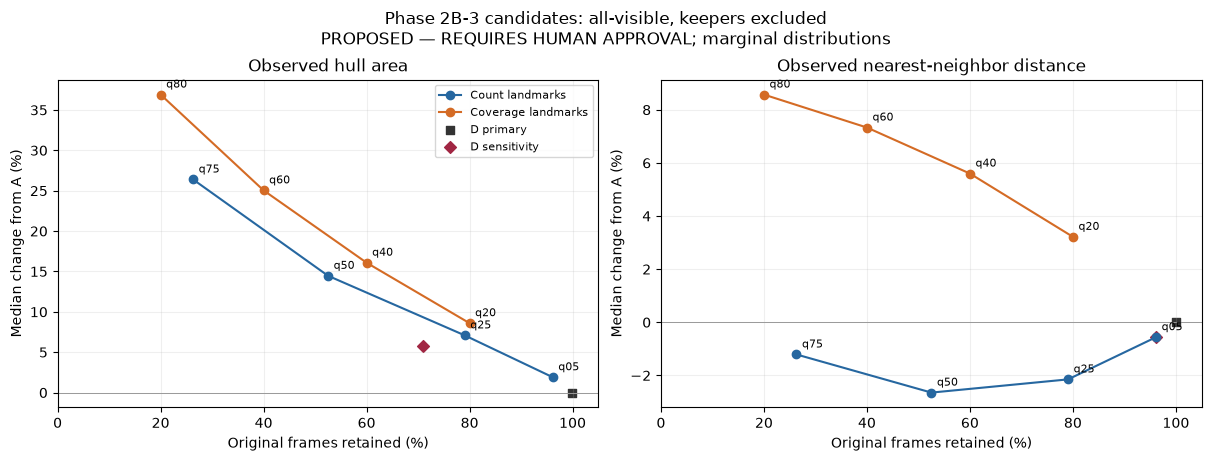

In [5]:
effects = calibration['candidate_distribution_effects']
display(effects.query("selected_subset == 'all_visible' and goalkeeper_policy == 'excluded' and candidate in ['D_sensitivity', 'E_q25_q20', 'C_q80', 'OOB_B_sensitivity']")[[ 'candidate', 'metric', 'eligible_frames', 'full_mean', 'retained_mean', 'full_median', 'retained_median', 'relative_delta_median', 'delta_std', 'delta_p05', 'delta_p25', 'delta_p75', 'delta_p95']])
figure = plot_calibration_tradeoffs(retention, effects)
figure.savefig(root / 'outputs/figures/phase2b3_retention_tradeoffs.png', dpi=160)

In [6]:
event_composition = calibration['filter_event_type_composition']
match_composition = calibration['filter_match_composition']
display(event_composition.query("selected_subset == 'all_visible' and goalkeeper_policy == 'included' and metric == 'visible_width' and candidate in ['C_q20', 'C_q80', 'OOB_B_sensitivity']").drop(columns='statsbomb_revision'))
display(match_composition.query("selected_subset == 'all_visible' and goalkeeper_policy == 'included' and metric == 'visible_width' and candidate == 'C_q80'").sort_values('retained_percent').drop(columns='statsbomb_revision'))

,event_type,population_frames,defined_frames,eligible_frames,retained_percent,full_share,retained_share,share_change_pp,selected_subset,goalkeeper_policy,metric,candidate
5880,50/50,180,180,144,80.000000,0.001518,0.001518,-3.200231e-07,all_visible,included,visible_width,C_q20
5881,Ball Receipt*,33398,33398,27672,82.855261,0.281647,0.291699,1.005159e+00,all_visible,included,visible_width,C_q20
5882,Ball Recovery,2862,2862,1848,64.570231,0.024135,0.019480,-4.655087e-01,all_visible,included,visible_width,C_q20
5883,Block,1273,1273,693,54.438335,0.010735,0.007305,-3.430160e-01,all_visible,included,visible_width,C_q20
5884,Carry,28741,28741,23911,83.194739,0.242374,0.252053,9.678507e-01,all_visible,included,visible_width,C_q20
...,...,...,...,...,...,...,...,...,...,...,...,...
6139,Pass,33072,33072,29719,89.861514,0.278898,0.277558,-1.339667e-01,all_visible,included,visible_width,OOB_B_sensitivity
6140,Pressure,10080,10080,8725,86.557540,0.085005,0.081486,-3.518724e-01,all_visible,included,visible_width,OOB_B_sensitivity
6141,Referee Ball-Drop,3,3,3,100.000000,0.000025,0.000028,2.719105e-04,all_visible,included,visible_width,OOB_B_sensitivity
6142,Shield,31,31,28,90.322581,0.000261,0.000262,7.915366e-06,all_visible,included,visible_width,OOB_B_sensitivity


,match_id,population_frames,defined_frames,eligible_frames,retained_percent,full_share,retained_share,share_change_pp,selected_subset,goalkeeper_policy,metric,candidate
8449,3895202,3433,3433,138,4.019808,0.028951,0.005819,-2.313206,all_visible,included,visible_width,C_q80
8456,3895266,3623,3623,216,5.961910,0.030553,0.009107,-2.144556,all_visible,included,visible_width,C_q80
8435,3895074,3793,3793,234,6.169259,0.031987,0.009866,-2.212023,all_visible,included,visible_width,C_q80
8459,3895292,3195,3195,209,6.541471,0.026944,0.008812,-1.813136,all_visible,included,visible_width,C_q80
8464,3895340,2847,2847,312,10.958904,0.024009,0.013155,-1.085378,all_visible,included,visible_width,C_q80
8434,3895067,3389,3389,432,12.747123,0.028580,0.018215,-1.036484,all_visible,included,visible_width,C_q80
8445,3895167,3453,3453,480,13.900956,0.029119,0.020239,-0.888069,all_visible,included,visible_width,C_q80
8454,3895250,3410,3410,487,14.281525,0.028757,0.020534,-0.822292,all_visible,included,visible_width,C_q80
8451,3895220,3757,3757,550,14.639340,0.031683,0.023190,-0.849287,all_visible,included,visible_width,C_q80
8440,3895121,3373,3373,511,15.149718,0.028445,0.021546,-0.689897,all_visible,included,visible_width,C_q80


## 4. Stability comparisons and joint support

No percentage is chosen to define stable. All-visible/outfield hull successive median changes under B are +1.90%, +5.09%, +6.89%, +10.42%; C gives +8.60%, +6.90%, +7.71%, +9.49%. There is no diminishing-change plateau. NN under B reverses sign; its diminishing C changes accompany loss of 80% of the population. A threshold cannot establish missing-player completeness.

The joint table records exact selected n and existing coverage quintiles, frame counts, match counts and defined counts/medians. Comparison-specific overlap must be reviewed before structural comparisons; no minimum reliable stratum size, weighting model or inference is approved here.

,selected_subset,goalkeeper_policy,metric,family,previous_candidate,candidate,eligible_frames,successive_frames_removed,successive_delta_mean,successive_relative_change_mean,...,successive_delta_std,successive_relative_change_std,successive_delta_p05,successive_relative_change_p05,successive_delta_p25,successive_relative_change_p25,successive_delta_p75,successive_relative_change_p75,successive_delta_p95,successive_relative_change_p95
20,all_visible,excluded,convex_hull_area,B,A,B_q05,114011,4551,18.767221,0.019875,...,-8.255682,-0.021783,35.643179,0.102108,24.742945,0.036997,11.365405,0.009514,8.026552,0.005077
21,all_visible,excluded,convex_hull_area,B,B_q05,B_q25,93745,20266,47.119034,0.048928,...,-6.844103,-0.018460,56.081347,0.145773,57.263358,0.082569,40.092423,0.033245,35.076463,0.022076
22,all_visible,excluded,convex_hull_area,B,B_q25,B_q50,62278,31467,68.917791,0.068225,...,-5.911231,-0.016244,72.304420,0.164031,79.312266,0.105640,66.400227,0.053288,45.845604,0.028231
23,all_visible,excluded,convex_hull_area,B,B_q50,B_q75,31202,31076,98.951781,0.091701,...,1.630451,0.004554,81.137895,0.158132,104.470745,0.125854,98.832774,0.075304,93.172419,0.055798
24,all_visible,excluded,convex_hull_area,C,A,C_q20,94851,23711,81.480887,0.086290,...,-22.474552,-0.059299,124.336937,0.356191,103.501523,0.154763,62.163147,0.052037,45.654066,0.028879
25,all_visible,excluded,convex_hull_area,C,C_q20,C_q40,71142,23709,70.267798,0.068504,...,-7.236114,-0.020296,74.635519,0.157655,79.912624,0.103477,66.800729,0.053153,54.025144,0.033215
26,all_visible,excluded,convex_hull_area,C,C_q40,C_q60,47429,23713,79.309631,0.072362,...,-3.707271,-0.010614,83.393481,0.152165,88.263063,0.103572,72.759041,0.054972,71.277181,0.042413
27,all_visible,excluded,convex_hull_area,C,C_q60,C_q80,23717,23712,106.369764,0.090502,...,-0.585226,-0.001693,87.966013,0.139310,114.985830,0.122267,97.286717,0.069674,98.076666,0.055985
28,all_visible,excluded,convex_hull_area,E,A,E_q25_q20,71019,47543,122.281286,0.129498,...,-41.465687,-0.109408,196.761836,0.563668,156.183217,0.233537,90.088841,0.075414,58.468355,0.036985
29,all_visible,excluded,convex_hull_area,E,E_q25_q20,E_q50_q40,41232,29787,106.233563,0.099605,...,-18.403411,-0.054523,136.456369,0.249995,124.793270,0.151272,91.580996,0.071287,71.077936,0.043358


,selected_subset,goalkeeper_policy,n_valid_points_used,visible_area_bin,frames,matches,coverage_median,visible_player_count_defined,visible_player_count_median,centroid_x_defined,...,visible_depth_defined,visible_depth_median,convex_hull_area_defined,convex_hull_area_median,mean_pairwise_distance_defined,mean_pairwise_distance_median,median_pairwise_distance_defined,median_pairwise_distance_median,mean_nearest_neighbor_distance_defined,mean_nearest_neighbor_distance_median
0,all_visible,excluded,0,B1,1,1,0.211261,1,0.0,0,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
1,all_visible,excluded,1,B1,4,1,0.156962,4,1.0,4,...,4,0.000000,0,NaN,0,NaN,0,NaN,0,NaN
2,all_visible,excluded,1,B3,2,1,0.286329,2,1.0,2,...,2,0.000000,0,NaN,0,NaN,0,NaN,0,NaN
3,all_visible,excluded,2,B2,7,2,0.226696,7,2.0,7,...,7,3.405705,0,NaN,7,22.351291,7,22.351291,7,22.351291
4,all_visible,excluded,2,B3,1,1,0.273256,1,2.0,1,...,1,0.171893,0,NaN,1,16.948638,1,16.948638,1,16.948638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,all_visible,excluded,21,B1,4,2,0.191184,4,21.0,4,...,4,20.517745,4,604.477231,4,13.527138,4,11.162692,4,3.652144
96,all_visible,excluded,21,B2,6,4,0.250985,6,21.0,6,...,6,33.437220,6,1376.478922,6,22.979218,6,21.994430,6,5.509756
97,all_visible,excluded,21,B3,6,4,0.286188,6,21.0,6,...,6,47.233601,6,1525.866676,6,21.946074,6,20.291202,6,6.480193
98,all_visible,excluded,21,B4,1,1,0.336378,1,21.0,1,...,1,25.113467,1,726.618371,1,16.913240,1,16.245913,1,4.847796


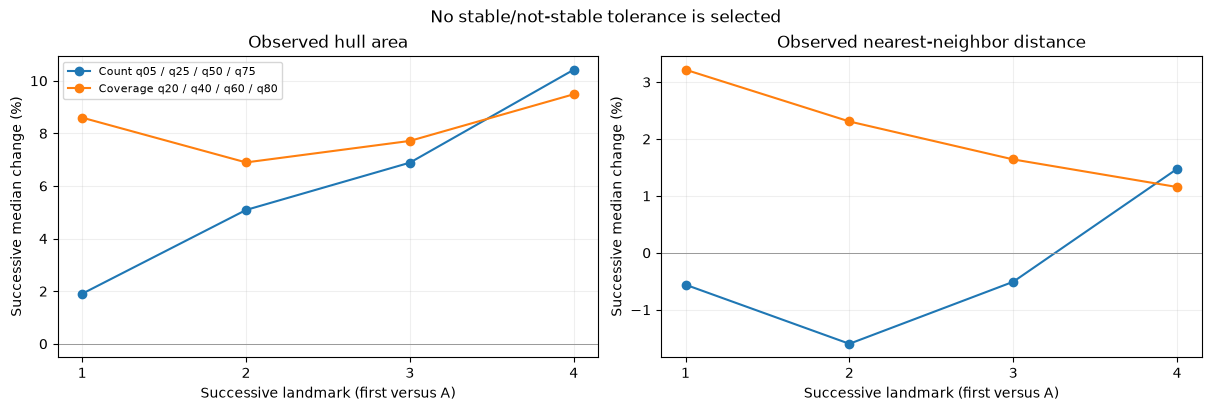

In [7]:
stability = calibration['threshold_stability']
display(stability.query("selected_subset == 'all_visible' and goalkeeper_policy == 'excluded' and metric in ['convex_hull_area', 'mean_nearest_neighbor_distance']").drop(columns='statsbomb_revision'))
figure = plot_threshold_stability(stability)
figure.savefig(root / 'outputs/figures/phase2b3_threshold_stability.png', dpi=160)
display(calibration['count_coverage_support'].query("goalkeeper_policy == 'excluded' and selected_subset == 'all_visible'").drop(columns='statsbomb_revision'))

## 5. Metric-specific calibration matrix

This is the main human-review artifact. Mathematical minima remain locked. Confidence distinguishes description of observed records from unsupported full-team reconstruction. The count row includes the discrete median exception: excluding 50 coincident frames moves teammate_false/outfield median count 9 to 8, despite a mean change of only -0.000219. Width/depth/hull remain invariant to duplicate multiplicity and receive no coincidence exclusion.

In [8]:
with __import__('pandas').option_context('display.max_colwidth', None, 'display.max_columns', None):
    display(calibration['metric_calibration_matrix'].drop(columns='statsbomb_revision'))

,metric,minimum_mathematical_n,observed_n_sensitivity,observed_visible_area_sensitivity,goalkeeper_sensitivity,oob_sensitivity,coincident_record_sensitivity,polygon_edge_concern,candidate_primary_treatment,candidate_sensitivity_treatment,confidence,unresolved_concern,evidence,status
0,visible_player_count,0 for known empty,Direct selected record inventory; never verified people,All-visible included mean 15.15 to 18.05 across coverage quintiles,Removing keeper changes population being counted,Records retained; no coordinate-based correction,"50 frames affected; exclusion changes teammate_false/excluded median n from 9 to 8, mean -0.000219; discrete rank-boundary effect",Polygon inconsistency is metadata only,D_primary; report record n for each declared subset and keeper population,coincidence_sensitivity; included/excluded inventory,High for inventory; low for completeness,Count does not establish complete team observation,phase2b1_visibility_vs_player_count.csv; phase2b2_coincident_metric_sensitivity.csv; phase2b3_candidate_distribution_effects.csv,PROPOSED — REQUIRES HUMAN APPROVAL
1,centroid,1; both components jointly defined,Record-weighted location depends on composition; no stable-n certification,No centroid coverage stability claim; candidate distribution tables include x/y,Actual-removal mean absolute x delta 1.392 to 2.475; y 0.443 to 0.763 native units; choose represented population,Use OOB_B as broad robustness check; no centroid-specific invalidity evidence,Multiplicity changes centroid; exclude whole coincident frames in sensitivity,Outside polygon does not invalidate center,D_primary; excluded for observed outfield center; native axes only,D_sensitivity coincidence exclusion; included paired variant; OOB_B,Moderate for convention; low for full-team location,Orientation unresolved; no pooled native-x positional interpretation,phase2b3_goalkeeper_policy_comparison.csv; phase2b2_coincident_metric_sensitivity.csv; phase2b3_candidate_distribution_effects.csv,PROPOSED — REQUIRES HUMAN APPROVAL
2,visible_width,1; n=1 gives observed span zero,Exact-n spans vary; small clouds omit possible extrema,Higher endpoint coverage associates with larger spans,Actual removal changes 1.17 to 2.15 percent; mean delta -0.042 to -0.076 units,Upper tail 29.93 percent OOB versus 9.70 percent overall,Invariant to exact repetitions,Extreme p05 boundary distance 0.266 to 0.391 units; no edge cutoff,"D_primary; excluded to align outfield population, included defensible for full visible footprint",D_sensitivity whole-frame OOB exclusion; included variant; B/C grid,Moderate for observed span; low for full-team width,Unobserved defining extremes cannot be certified by coverage,phase2b1_goalkeeper_sensitivity.csv; phase2b2_extreme_tail_summary.csv; phase2b2_edge_distance_summary.csv; phase2b3_candidate_distribution_effects.csv,PROPOSED — REQUIRES HUMAN APPROVAL
3,visible_depth,1; n=1 gives observed span zero,Exact-n depth varies; population and keepers co-vary,Higher coverage endpoint associates with larger span,Actual-removal mean delta -9.99 to -11.78 units; changes 95.14 to 98.50 percent,Upper tail OOB 9.36 percent versus 9.70 overall; no selective enrichment,Invariant to exact repetitions,Defining extremes near supplied edge; no hard censoring,D_primary; excluded for outfield span; included only for full visible footprint,Included paired variant first; OOB_B broad check; B/C grid,Moderate for outfield convention,"Depth is native x-span, not defensive block depth",phase2b1_goalkeeper_sensitivity.csv; phase2b2_extreme_tail_summary.csv; phase2b3_candidate_distribution_effects.csv,PROPOSED — REQUIRES HUMAN APPROVAL
4,convex_hull_area,3 records AND 3 unique non-collinear points; valid positive polygon,Strong exact-n sensitivity; larger selected clouds enlarge hull,Lowest-to-highest coverage-quintile median change 105.8 to 149.5 percent,Actual-removal mean delta -190.25 to -219.62 squared units; changes 98.58 to 99.71 percent,Upper tail 16.53 perce

## 6. Proposed primary and sensitivity treatments

**Primary:** D primary, with no universal count/coverage gate. Declare the observed population; use exact-n and shared coverage strata for NN comparisons, disclose joint support for hull and all observation-sensitive comparisons, and report unsupported contrasts when there is no overlap. Eligibility alone does not justify pooling unlike observation populations.

**Keeper convention:** excluded for observed outfield centroid, depth, hull and spacing. Either width convention is empirically defensible; excluded aligns it with outfield shape. Included remains the correct variant for an explicitly named full visible footprint. Preserve both inventories and same-frame keeper sensitivities. All-visible combines both literal teammate subsets. Actual-removal depth decreases 9.99–11.78 units and hull decreases 190.25–219.62 squared units on average; width changes in only 1.17–2.15%. Spacing mean absolute changes remain material even where signed means cancel.

**Sensitivity:** D metric-specific checks, individual B/C/OOB/coincidence checks, and E conservative combinations. Retain coordinates with flags in every primary convention. OOB-B removes 11,508 original frames, 9.7048%; coincidence removes 50, 0.0422%, only for multiplicity-sensitive metrics. Polygon inconsistency and boundary proximity remain metadata. A supplies ambiguity-inclusion sensitivity while D preserves the registry primary-comparison exclusion of four multiple-actor frames.

In [9]:
display(calibration['goalkeeper_policy_comparison'].query("scope == 'keeper_removed'").drop(columns='statsbomb_revision'))
display(calibration['oob_policy_comparison'].query("selected_subset == 'all_visible' and goalkeeper_policy == 'excluded'")[[ 'candidate', 'metric', 'eligible_frames', 'eligible_percent', 'relative_delta_median']])

,selected_subset,metric,scope,scope_frames,included_defined,excluded_defined,jointly_defined,lost_defined_on_exclusion,unknown_keeper_removed_frames,delta_direction,mean_absolute_delta,changed_percent,mean,median,std,p05,p25,p75,p95
1,all_visible,visible_player_count,keeper_removed,47394,47394,47394,47394,0,0,excluded_minus_included,1.000084,100.000000,-1.000084,-1.000000,0.009187,-1.000000,-1.000000,-1.000000,-1.000000
3,all_visible,centroid_x,keeper_removed,47394,47394,47393,47393,1,0,excluded_minus_included,1.392357,100.000000,0.114428,-0.450519,1.525898,-1.828748,-1.209844,1.482180,2.393854
5,all_visible,centroid_y,keeper_removed,47394,47394,47393,47393,1,0,excluded_minus_included,0.442585,100.000000,0.006411,0.005138,0.572095,-0.895982,-0.355718,0.377667,0.896529
7,all_visible,visible_width,keeper_removed,47394,47394,47393,47393,1,0,excluded_minus_included,0.041751,1.173169,-0.041751,0.000000,0.560750,0.000000,0.000000,0.000000,0.000000
9,all_visible,visible_depth,keeper_removed,47394,47394,47393,47393,1,0,excluded_minus_included,10.426598,95.138523,-10.426598,-10.421011,6.332221,-20.677780,-14.627011,-5.633739,-0.066048
11,all_visible,convex_hull_area,keeper_removed,47394,47387,47375,47375,12,0,excluded_minus_included,219.621707,98.851715,-219.621707,-191.382199,155.945105,-511.783046,-307.104391,-102.049241,-22.256829
13,all_visible,mean_pairwise_distance,keeper_removed,47394,47393,47387,47387,6,0,excluded_minus_included,0.904963,100.000000,-0.838901,-0.752771,0.833495,-2.207617,-1.251513,-0.303415,0.240787
15,all_visible,median_pairwise_distance,keeper_removed,47394,47393,47387,47387,6,0,excluded_minus_included,0.964517,96.473716,-0.859980,-0.733115,1.031937,-2.503587,-1.333921,-0.212972,0.331854
17,all_visible,mean_nearest_neighbor_distance,keeper_removed,47394,47393,47387,47387,6,0,excluded_minus_included,0.510932,100.000000,-0.405916,-0.419100,0.515668,-1.113490,-0.645902,-0.172880,0.331825
19,teammate_false,visible_player_count,keeper_removed,24374,24374,24374,24374,0,0,excluded_minus_included,1.000041,100.000000,-1.000041,-1.000000,0.006405,-1.000000,-1.000000,-1.000000,-1.000000


,candidate,metric,eligible_frames,eligible_percent,relative_delta_median
0,OOB_A,visible_player_count,118581,100.000000,0.000000
1,OOB_B_primary,visible_player_count,118581,100.000000,0.000000
2,OOB_B_sensitivity,visible_player_count,107073,90.295241,0.000000
3,OOB_C_primary,visible_player_count,118581,100.000000,0.000000
4,OOB_C_sensitivity,visible_player_count,118581,100.000000,0.000000
5,OOB_A,centroid_x,118580,99.999157,0.000000
6,OOB_B_primary,centroid_x,118580,99.999157,0.000000
7,OOB_B_sensitivity,centroid_x,107072,90.294398,0.001107
8,OOB_C_primary,centroid_x,118580,99.999157,0.000000
9,OOB_C_sensitivity,centroid_x,118580,99.999157,0.000000


## 7. Unresolved decisions requiring human approval

**PROPOSED — REQUIRES HUMAN APPROVAL.** Approve the intended keeper population and D primary with its comparison-specific count/coverage support conditions; approve or revise the D hull q25 (14 all-visible, 7 teammate subsets) and NN q05 (11/10 all-visible included/excluded, 5 teammate_true, 4 teammate_false) sensitivity landmarks; choose routine OOB-B versus metric-prioritized OOB-C; and decide whether a later primary generic-geometry analysis should revise the registry actor-ambiguity exclusion. Current generic diagnostics retain all actor records.

No hard polygon or boundary cutoff, deduplication, coordinate mutation, actor repair or permanent configuration change is proposed for automatic execution. The later event/actor integration contract, inferential stratum support and any weighting require separate specification. Unknown full-team positions, identity and orientation semantics remain unresolved. No tactical, predictive or causal analysis is started.